# Adobe (Creative Cloud & Experience Cloud)
![Screenshot 2026-04-08 150157.png](<attachment:Screenshot 2026-04-08 150157.png>)

## Background
Sejak periode 2020 hingga 2023, Perusahaan telah mengadopsi strategi penetapan harga yang agresif dengan memberikan diskon besar untuk mempercepat penetrasi pasar dan meningkatkan volume penjualan (Market Share). Namun, seiring dengan dinamika pasar SaaS yang semakin kompetitif, manajemen mulai mengamati adanya erosi margin yang signifikan pada beberapa lini produk dan segmen pelanggan.

Saat ini, Departemen Keuangan (Finance Team) mencurigai bahwa pemberian diskon yang tidak terkontrol telah melewati ambang batas profitabilitas. Tanpa adanya kebijakan diskon yang berbasis data (Data-Driven), perusahaan berisiko mengalami pertumbuhan pendapatan yang semu—di mana volume penjualan meningkat, namun keuntungan bersih justru menurun atau bahkan merugi.

Analisis ini diperlukan untuk memetakan kembali korelasi antara diskon dan profitabilitas. Hasil dari analisis ini akan menjadi landasan bagi tim Finance dalam menyusun kebijakan diskon formal yang mampu menyeimbangkan antara daya saing pasar dan kesehatan arus kas (cash flow) perusahaan.

---
### Stakeholder
- Finance Team  
    - kontrol profit & margin
    - menentukan kebijakan diskon
    
Finance Team (Primary): untuk mengevaluasi dampak diskon terhadap profitabilitas serta menentukan kebijakan batas diskon.

---

### Problem Statement

1. Analisis Pengaruh Diskon terhadap Profit (2020–2023)
- Bagaimana pengaruh **Diskon** terhadap **Profit**?
- Apakah pemberian diskon yang tinggi menjadi penyebab utama kerugian transaksi di perusahaan periode 2020–2023?

2. Analisis Produk Berdasarkan Diskon dan Profit
- Produk apa yang menghasilkan **Diskon** dan **Profit** tertinggi?
- Produk apa yang menghasilkan **Diskon** dan **Profit** terendah?

3. Analisis Pelanggan dan Segmentasi (Impact Discount terhadap Profit)
- Segmen pelanggan mana yang paling terdampak oleh diskon tinggi?
- Apakah terdapat segmen yang sering mengalami kerugian akibat diskon >30%?

---

## Goals
Tujuan dari analisis ini adalah:
- Mengetahui pengaruh diskon terhadap profit
- Menentukan batas optimal diskon
- Mengidentifikasi produk & segmen yang profitable vs merugikan
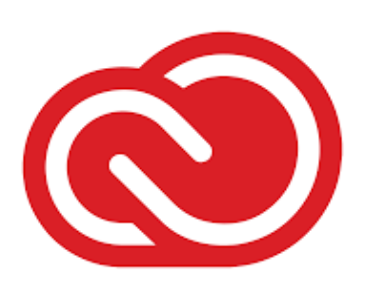

### DATA UNDERSTANDING

In [461]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats 

Read Data Set

In [462]:
df = pd.read_csv('SaaS-Sales.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')  # 'ignore' = tidak error kalau tidak ada
df

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.2480,3,0.20,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.9600,2,0.00,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.5760,2,0.20,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.6000,4,0.00,13.3200


### 2.1 Columns Description

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **Row ID** | Identifikasi unik untuk setiap baris transaksi. |
| **Order ID** | Identifikasi unik untuk setiap pesanan. |
| **Order Date** | Tanggal saat pesanan dibuat. |
| **Date Key** | Representasi numerik dari tanggal pesanan (format YYYYMMDD). |
| **Contact Name** | Nama orang yang melakukan pemesanan. |
| **Country** | Negara tempat pesanan dilakukan.|
| **City** | Kota tempat pesanan dilakukan. |
| **Region** | Wilayah/Region tempat pesanan dilakukan. |
| **Subregion** | Sub-wilayah tempat pesanan dilakukan. |
| **Customer** | Nama perusahaan yang melakukan pemesanan. |
| **Customer ID** | Identifikasi unik untuk setiap pelanggan.|
| **Industry** | Sektor industri tempat pelanggan bernaung. |
| **Segment** | Segmen pelanggan (UKM/SMB, Strategis, Enterprise, dll.). |
| **Product** | Produk yang dipesan. |
| **License** | Kunci lisensi untuk produk yang dibeli. |
| **Sales** | Total nilai penjualan untuk transaksi tersebut. |
| **Quantity** | Jumlah total unit barang dalam transaksi. |
| **Discount** | Diskon yang diberikan pada transaksi tersebut. |
| **Profit** | Keuntungan atau laba bersih dari transaksi. |

### 2.2 Data Types

In [463]:
# Cek tipe data
df.dtypes

# Ubah kolom ke tipe yang benar
df['Order Date'] = pd.to_datetime(df['Order Date'])   # string → datetime
df['Sales'] = df['Sales'].astype(float)               # object → float
df['Quantity'] = df['Quantity'].astype(int)           # float → int

# Ekstrak info dari datetime
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day of Week'] = df['Order Date'].dt.day_name()

In [464]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

#### Temuan Utama 

> **Ringkasan Dataset:** Dataset ini berisi **9.994 baris** data transaksi yang sangat bersih tanpa ada nilai yang hilang (*missing values*).

Berikut adalah poin-poin penting dari struktur data yang ditemukan:

* **Metrik Numerik (Key Performance Indicators):**
    Terdapat empat fitur utama untuk mengukur performa bisnis: 
    * `Sales` (Penjualan)
    * `Quantity` (Jumlah Barang)
    * `Discount` (Potongan Harga)
    * `Profit` (Laba)
* **Granularitas Geografis:** Informasi lokasi tersedia secara hierarkis, memungkinkan analisis dari skala luas ke mendalam: `Country` $\rightarrow$ `Region` $\rightarrow$ `Subregion` $\rightarrow$ `City`.
* **Siap Analisis Deret Waktu (Time Series):** Kolom `Order Date` sudah dalam format **datetime**. Hal ini memudahkan ekstraksi tren berdasarkan `Year`, `Month`, maupun `Day of Week`.
* **Segmentasi Bisnis:** Dataset mendukung analisis mendalam terhadap perilaku pelanggan melalui kategori `Segment` (misal: Consumer/Corporate), `Industry`, dan jenis `Product`.
* **Integritas Data:** Dataset memiliki kualitas tinggi dengan tingkat kelengkapan **100%**, sehingga siap langsung masuk ke tahap visualisasi tanpa perlu pembersihan (cleaning) tambahan.

### 2.3 Statistic Descriptive

In [465]:
df.describe()

,Row ID,Order Date,Date Key,Customer ID,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9994,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2022-05-01 00:07:12.259355648,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896,2021.722934,7.814889
min,1.000000,2020-01-04 00:00:00,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000,2020.000000,1.000000
25%,2499.250000,2021-05-23 00:00:00,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750,2021.000000,5.000000
50%,4997.500000,2022-06-27 00:00:00,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500,2022.000000,9.000000
75%,7495.750000,2023-05-15 00:00:00,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000,2023.000000,11.000000
max,9994.000000,2023-12-31 00:00:00,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000,2023.000000,12.000000
std,2885.163629,NaN,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108,1.124039,3.285561


In [466]:
df.describe(include='number')

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896,2021.722934,7.814889
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108,1.124039,3.285561
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000,2020.000000,1.000000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750,2021.000000,5.000000
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500,2022.000000,9.000000
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000,2023.000000,11.000000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000,2023.000000,12.000000


In [467]:
df.describe(include='object')

,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License,Day of Week
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,48,262,3,12,99,10,3,14,9994,7
top,EMEA-2023-100111,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K,Tuesday
freq,14,37,2001,922,4219,2507,192,2127,5191,1842,1,1871


In [468]:
print(df.shape)

(9994, 22)


#### Temuan Utama
* **Volume Data:** Memiliki total **9.994 baris** transaksi.
* **Profitabilitas:** Kolom `Profit` mengandung nilai negatif, menunjukkan adanya transaksi yang tidak menguntungkan.
* **Strategi Diskon:** * Mayoritas transaksi menggunakan diskon rendah (**0% - 20%**).
    * Terdapat *outlier* diskon hingga **80%**, yang perlu dianalisis lebih lanjut dampaknya terhadap profit.

### 2.3 Normality Test

In [469]:
from scipy.stats import shapiro, kstest, normaltest
from statsmodels.stats.diagnostic import lilliefors

numeric = df[["Sales", "Quantity", "Discount", "Profit"]]
results = []

print("H0 = Data is normally distributed")
print("H1 = Data is not normally distributed")

for col in numeric.columns:
    ks_stat, ks_pval = kstest(df[col], 'norm')
    shapiro_stat, shapiro_pval = shapiro(df[col])
    lilliefors_stat, lilliefors_pval = lilliefors(df[col])
    normaltest_stat, normaltest_pval = normaltest(df[col])

    # Test results
    results.append({
        'Column': col,
        'KS_p-value': ks_pval,
        'Shapiro_p-value': shapiro_pval,
        'Pearson_p-value': normaltest_pval,
        'Lilliefors_p-value': lilliefors_pval,
        'KS_Result': 'Reject H0' if ks_pval < 0.05 else 'Not enough evidence to reject H0',
        'Shapiro_Result': 'Reject H0' if shapiro_pval < 0.05 else 'Not enough evidence to reject H0',
        'Lilliefors_Result': 'Reject H0' if lilliefors_pval < 0.05 else 'Not enough evidence to reject H0',
        'Pearson_Result': 'Reject H0' if normaltest_pval < 0.05 else 'Not enough evidence to reject H0'
    })

# Result to dataframe
results_df = pd.DataFrame(results)
results_df

H0 = Data is normally distributed
H1 = Data is not normally distributed


c:\Users\ARTUR\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9994.
  res = hypotest_fun_out(*samples, **kwds)


,Column,KS_p-value,Shapiro_p-value,Pearson_p-value,Lilliefors_p-value,KS_Result,Shapiro_Result,Lilliefors_Result,Pearson_Result
0,Sales,0.0,4.065054e-105,0.0,0.001,Reject H0,Reject H0,Reject H0,Reject H0
1,Quantity,0.0,1.518566e-65,0.0,0.001,Reject H0,Reject H0,Reject H0,Reject H0
2,Discount,0.0,1.030847e-84,0.0,0.001,Reject H0,Reject H0,Reject H0,Reject H0
3,Profit,0.0,1.698786e-107,0.0,0.001,Reject H0,Reject H0,Reject H0,Reject H0


#### Temuan Utama (Statistical Hypothesis Testing)

Sebelum melakukan analisis statistik lebih lanjut, dilakukan uji normalitas untuk menentukan apakah data numerik terdistribusi secara normal.

**Hipotesis Statistik:**
* **$H_0$ (Hipotesis Nol):** Data terdistribusi secara normal.
* **$H_1$ (Hipotesis Alternatif):** Data tidak terdistribusi secara normal.

**Hasil Pengujian:**
Berdasarkan hasil uji statistik yang telah dilakukan, diperoleh kesimpulan bahwa variabel berikut **tidak terdistribusi secara normal**:
1. `Sales` (Penjualan)
2. `Quantity` (Kuantitas)
3. `Discount` (Diskon)
4. `Profit` (Laba)

> **Catatan Analisis:** Karena nilai $p-value < 0.05$, kita menolak $H_0$. Hal ini menunjukkan bahwa data memiliki distribusi yang condong (*skewed*), yang umum ditemukan pada data transaksi penjualan ritel atau SaaS.

### Check Unique Value 

In [470]:
df.nunique()

Row ID          9994
Order ID        5009
Order Date      1237
Date Key        1237
Contact Name     793
Country           48
City             262
Region             3
Subregion         12
Customer          99
Customer ID       99
Industry          10
Segment            3
Product           14
License         9994
Sales           5825
Quantity          14
Discount          12
Profit          7287
Year               4
Month             12
Day of Week        7
dtype: int64

In [471]:
for i in df.columns:
    print(f"{i.capitalize()} → {df[i].nunique()} unique values")
    print(df[i].unique())
    print()

Row id → 9994 unique values
[   1    2    3 ... 9992 9993 9994]

Order id → 5009 unique values
['EMEA-2022-152156' 'AMER-2022-138688' 'EMEA-2021-108966' ...
 'EMEA-2020-110422' 'AMER-2023-121258' 'AMER-2023-119914']

Order date → 1237 unique values
<DatetimeArray>
['2022-11-09 00:00:00', '2022-06-13 00:00:00', '2021-10-11 00:00:00',
 '2020-06-09 00:00:00', '2023-04-16 00:00:00', '2022-12-06 00:00:00',
 '2021-11-22 00:00:00', '2020-11-11 00:00:00', '2020-05-13 00:00:00',
 '2020-08-27 00:00:00',
 ...
 '2022-10-12 00:00:00', '2020-06-18 00:00:00', '2023-03-01 00:00:00',
 '2021-05-09 00:00:00', '2020-11-06 00:00:00', '2021-12-29 00:00:00',
 '2020-04-03 00:00:00', '2022-06-04 00:00:00', '2021-04-12 00:00:00',
 '2020-01-22 00:00:00']
Length: 1237, dtype: datetime64[ns]

Date key → 1237 unique values
[20221109 20220613 20211011 ... 20220604 20210412 20200122]

Contact name → 793 unique values
['Nathan Bell' 'Deirdre Bailey' 'Zoe Hodges' 'Thomas Hodges'
 'Adrian Hunter' 'Adrian Abraham' 'Emily

#### Temuan Utama (Region & Subregion)

Analisis wilayah pada dataset ini dibagi menjadi 3 Region utama dengan pembagian Subregion yang lebih spesifik untuk pemetaan pasar yang lebih akurat.

### 🌎 Wilayah Utama (Regions)

| Region | Nama Lengkap | Deskripsi |
| :--- | :--- | :--- |
| **EMEA** | Europe, Middle East, Africa | Mencakup seluruh negara di Eropa, Timur Tengah, dan Afrika. |
| **AMER** | Americas | Mencakup Amerika Utara (US & Canada) serta seluruh Amerika Selatan. |
| **APJ** | Asia Pacific & Japan | Meliputi wilayah Asia Timur, Asia Tenggara, dan Oseania (Australia). |

---

### 📍 Pembagian Sub-Wilayah (Subregions)

| Subregion | Deskripsi |
| :--- | :--- |
| **UKIR** | United Kingdom & Ireland (Pasar khusus Inggris dan Irlandia). |
| **NAMER** | North America (Fokus pada basis konsumen besar di AS, Kanada, dan Meksiko). |
| **EU-WEST** | Eropa Barat (Negara maju seperti Prancis, Jerman, dan Belanda). |
| **NOR** | Negara Nordic (Denmark, Finlandia, Islandia, Norwegia, dan Swedia). |
| **JAPN** | Jepang (Pasar spesifik Jepang). |
| **EU** | Uni Eropa (Negara anggota dengan kebijakan ekonomi terintegrasi). |
| **MEA** | Timur Tengah dan Afrika (Ekonomi dan budaya yang sangat beragam). |
| **LATAM** | Amerika Latin (Wilayah Amerika Tengah dan Selatan). |
| **ANZ** | Australia dan Selandia Baru. |
| **APAC** | Asia-Pacific (Asia Timur, Tenggara, dan Oseania dengan pertumbuhan cepat). |
| **IND** | India (Pasar spesifik India). |
| **EU-EAST** | Eropa Timur (Negara-negara seperti Polandia dan sekitarnya). |

---

## `Data Preparation`

In [472]:
# 1. Cleaning
# Standarisasi teks
text_cols = ['Country', 'City', 'Industry', 'Product', 'Customer', 'Contact Name']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

df['Region']  = df['Region'].str.strip().str.upper()
df['Segment'] = df['Segment'].str.strip().str.upper()

#2. Transformation
df['Order Date']  = pd.to_datetime(df['Order Date'],format='%m/%d/%Y')
df['Customer ID'] = df['Customer ID'].astype(object)
df['Year']        = df['Year'].astype(object)
df['Month']       = df['Month'].astype(object)
df['Month Name']  = df['Order Date'].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,...,Product,License,Sales,Quantity,Discount,Profit,Year,Month,Day of Week,Month Name
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,2022,11,Wednesday,November
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,Financehub,QLIW57KZUV,731.9400,3,0.00,219.5820,2022,11,Wednesday,November
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,...,Financehub,JI6BVL70HQ,14.6200,2,0.00,6.8714,2022,6,Monday,June
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,Contactmatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,2021,10,Monday,October
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,2021,10,Monday,October


In [473]:
# 3. REGEX
# Fix nama produk
product_fix = {
    'Financehub'                : 'FinanceHub',
    'Contactmatcher'            : 'ContactMatcher',
    'Saas Connector Pack'       : 'SaaS Connector Pack',
    'Saas Connector Pack - Gold': 'SaaS Connector Pack - Gold',
    'Chatbot Plugin'            : 'ChatBot Plugin',
    'Oneview'                   : 'OneView',
}
df['Product'] = df['Product'].replace(product_fix)

# Ekstrak dari Order ID → Nomor Order
df[['OID_Region', 'OID_Year', 'OID_Number']] = df['Order ID'].str.extract(
    r'^([A-Z]+)-(\d{4})-(\d+)$'
)
df = df.drop(columns=['OID_Region', 'OID_Year'])

# Ekstrak First Name & Last Name dari Contact Name
df['First Name'] = df['Contact Name'].str.extract(r'^(\w+)')
df['Last Name']  = df['Contact Name'].str.extract(r'(\w+)$')

print("Regex selesai")
df[['Order ID', 'OID_Number', 'Contact Name', 'First Name', 'Last Name']].head()

Regex selesai


,Order ID,OID_Number,Contact Name,First Name,Last Name
0,EMEA-2022-152156,152156,Nathan Bell,Nathan,Bell
1,EMEA-2022-152156,152156,Nathan Bell,Nathan,Bell
2,AMER-2022-138688,138688,Deirdre Bailey,Deirdre,Bailey
3,EMEA-2021-108966,108966,Zoe Hodges,Zoe,Hodges
4,EMEA-2021-108966,108966,Zoe Hodges,Zoe,Hodges


In [474]:
# 4. Feature Engineering
# Discount → persentase
df['Discount (%)'] = (df['Discount'] * 100).astype(int)
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100
df['Avg Price']         = df['Sales'] / df['Quantity'].replace(0, 1)
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,...,Year,Month,Day of Week,Month Name,OID_Number,First Name,Last Name,Discount (%),Profit Margin (%),Avg Price
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,2022,11,Wednesday,November,152156,Nathan,Bell,0,16.00,130.9800
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,2022,11,Wednesday,November,152156,Nathan,Bell,0,30.00,243.9800
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,...,2022,6,Monday,June,138688,Deirdre,Bailey,0,47.00,7.3100
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,2021,10,Monday,October,108966,Zoe,Hodges,45,-40.00,191.5155
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,2021,10,Monday,October,108966,Zoe,Hodges,20,11.25,11.1840


In [475]:
# FIX TIPE DATA

# Ubah Order Date jadi datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Pastikan kolom numerik benar
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# DROP / HIDE KOLOM TIDAK PERLU

cols_to_drop = [
    'Discount (%)', 
    'First Name', 
    'Last Name', 
    'Contact Name',
    'Date Key'
]

# Drop hanya jika kolom ada
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# HANDLE MISSING VALUES

# Cek missing
print("Missing values:\n", df.isna().sum())

# Drop row yang ada missing (opsional)
df = df.dropna()

# VALIDASI DATA 

print("Sales negatif:", (df['Sales'] < 0).sum())
print("Profit > Sales:", (df['Profit'] > df['Sales']).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())

# Discount Level
def discount_level(x):
    if x == 0:
        return "No Discount"
    elif x <= 0.2:
        return "Low (0–20%)"
    elif x <= 0.3:
        return "Medium (20–30%)"
    else:
        return "High (>30%)"

df['Discount Level'] = df['Discount'].apply(discount_level)

# Profit Category
df['Profit Category'] = df['Profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')

Missing values:
 Row ID               0
Order ID             0
Order Date           0
Country              0
City                 0
Region               0
Subregion            0
Customer             0
Customer ID          0
Industry             0
Segment              0
Product              0
License              0
Sales                0
Quantity             0
Discount             0
Profit               0
Year                 0
Month                0
Day of Week          0
Month Name           0
OID_Number           0
Profit Margin (%)    0
Avg Price            0
dtype: int64
Sales negatif: 0
Profit > Sales: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0


#### Check Outlier Kolom Numerik

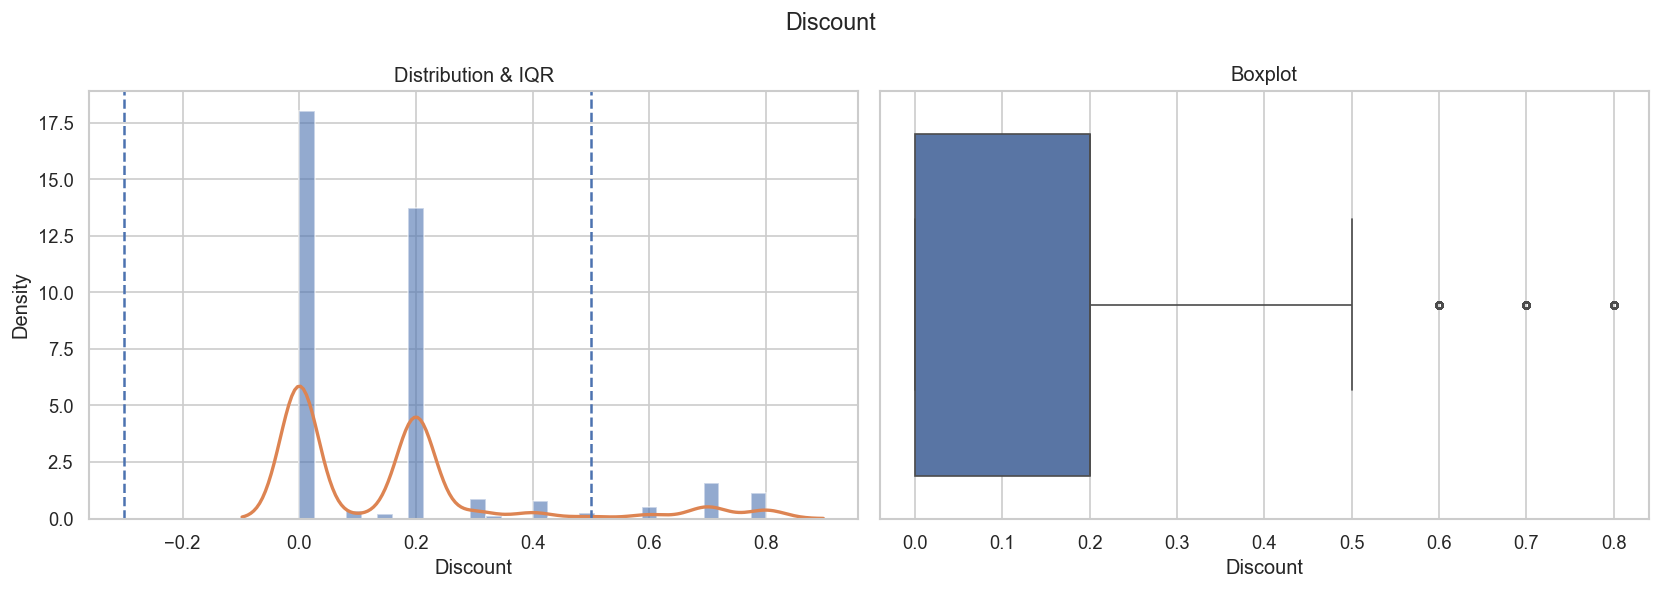

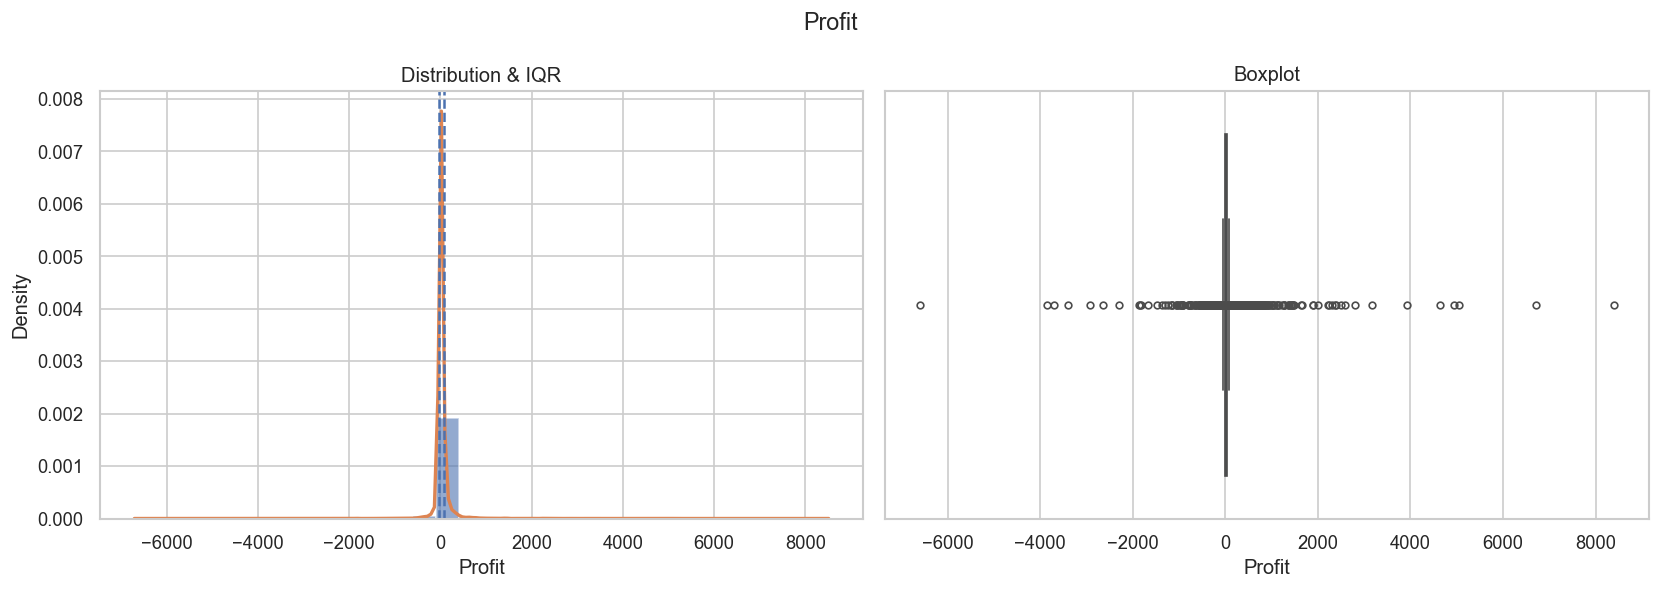

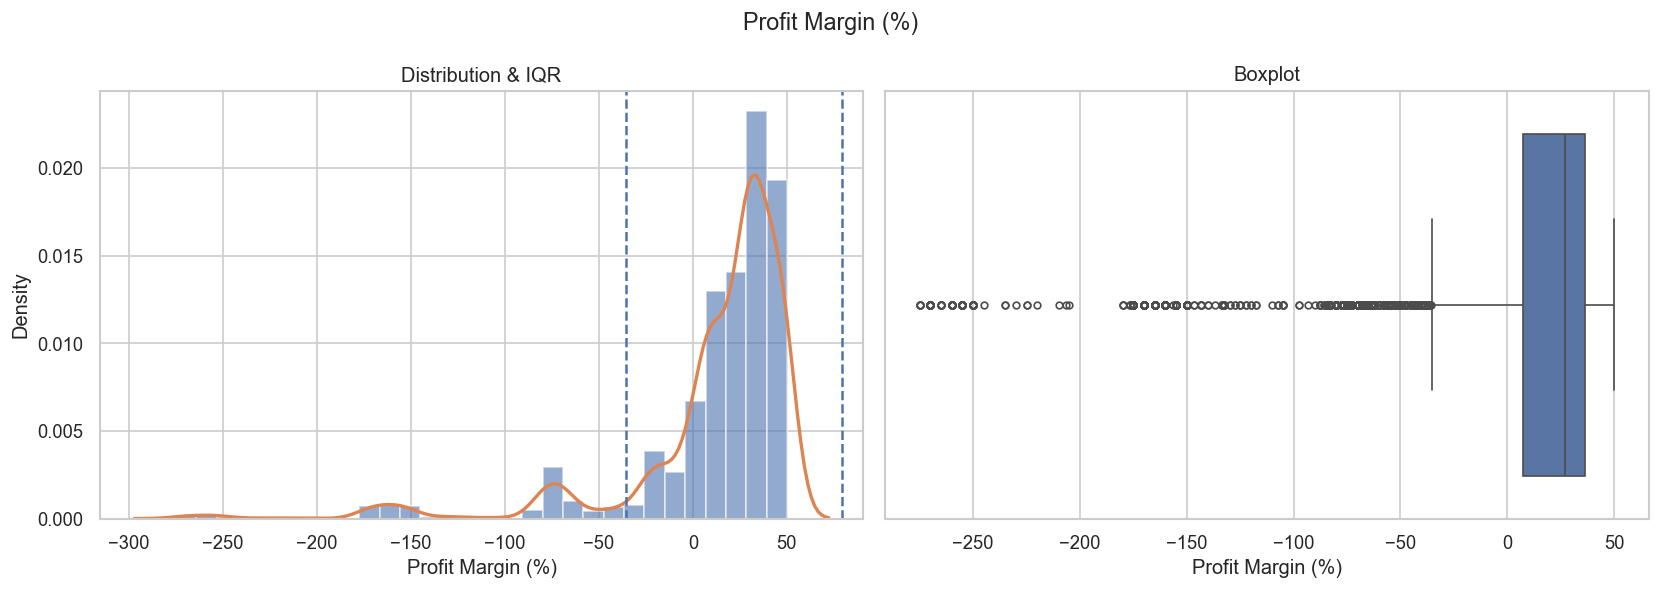

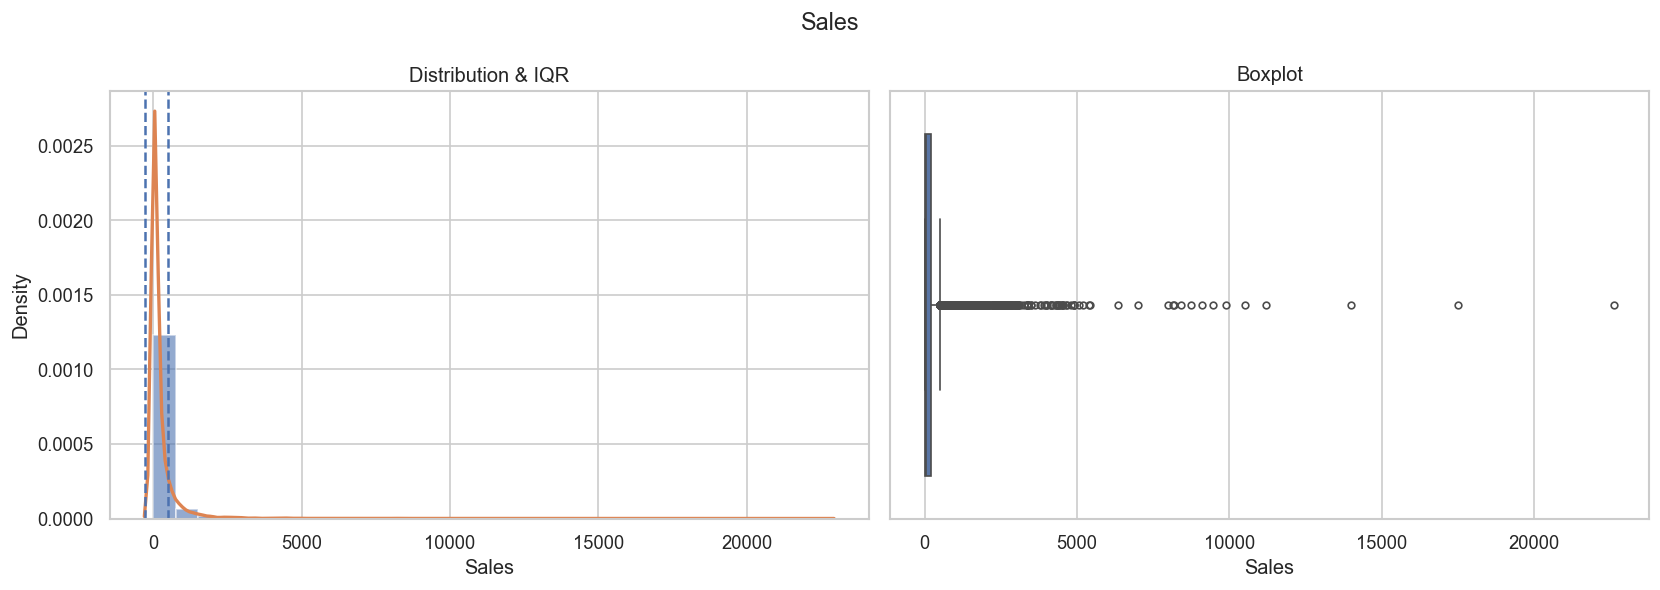

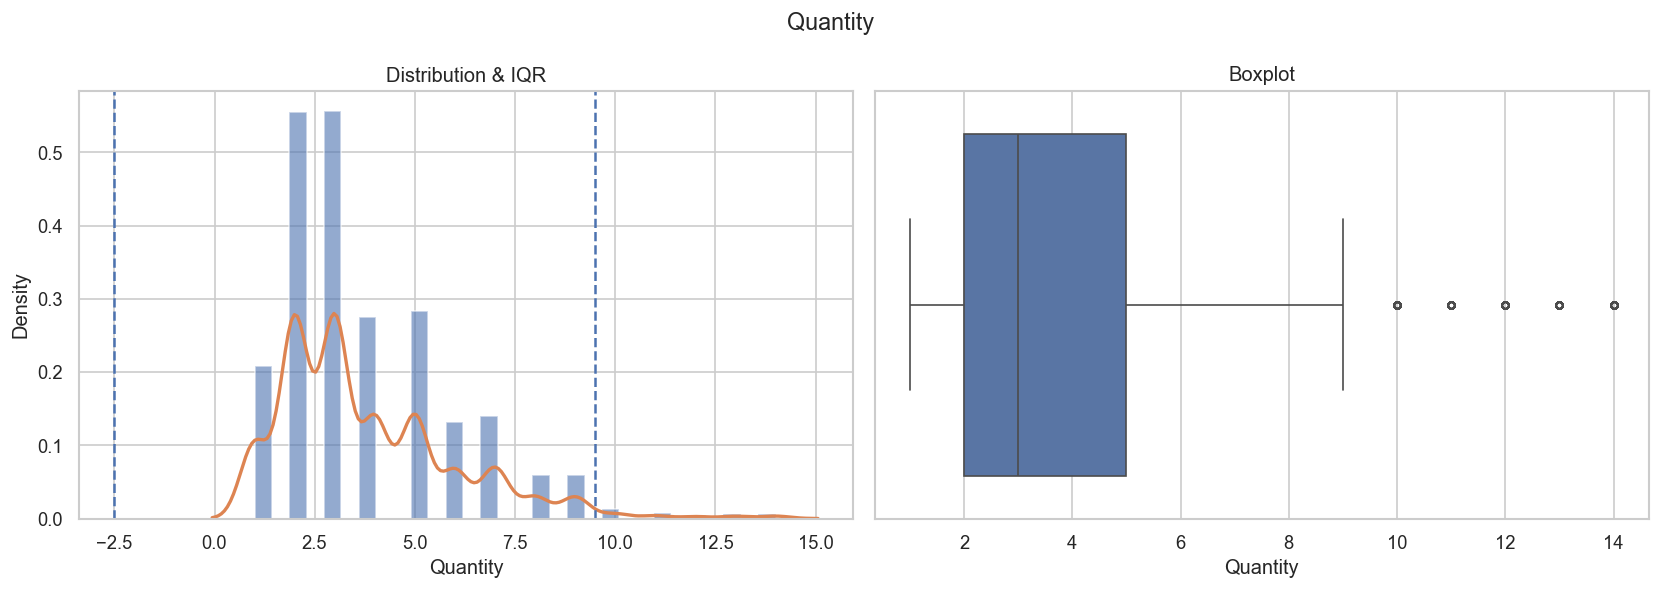

In [476]:
cols = ['Discount', 'Profit', 'Profit Margin (%)', 'Sales', 'Quantity']

for feature in cols:
    s = df[feature].dropna()

    # Hitung IQR
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(feature, fontsize=14)

    # Histogram + KDE
    axes[0].hist(s, bins=30, density=True, alpha=0.6)
    sns.kdeplot(s, ax=axes[0], linewidth=2)

    # Garis batas outlier
    axes[0].axvline(low, linestyle='--', linewidth=1.5)
    axes[0].axvline(high, linestyle='--', linewidth=1.5)

    axes[0].set_title(f'Distribution & IQR')

    # Boxplot
    sns.boxplot(x=s, ax=axes[1], fliersize=4)
    axes[1].set_title('Boxplot')

    plt.tight_layout()
    plt.show()

#### Analisis Outlier

#### Discount
- Distribusi **right skewed**, mayoritas di rentang 0–0.2  
- Terdapat outlier pada discount tinggi (0.6–0.8)  
- Variasi normal stabil (IQR sempit)  
- Diskon tinggi berpotensi menurunkan profit  

**Kesimpulan:**  
Mayoritas diskon rendah, namun ada diskon ekstrem yang berisiko terhadap profit.

#### Profit
- Distribusi sangat tidak normal (heavy tails)  
- Banyak outlier positif & negatif (ekstrem)  
- Median mendekati nol → mayoritas profit kecil  
- Variasi sangat tinggi (tidak stabil)  

**Kesimpulan:**  
Profit didominasi nilai kecil, namun ada transaksi ekstrem yang meningkatkan risiko kerugian.

#### Profit Margin (%)
- Distribusi **left skewed**, dominan positif  
- Banyak outlier negatif (hingga < -200%)  
- Mayoritas transaksi tetap profitable  
- Kerugian lebih ekstrem dibanding keuntungan  

**Kesimpulan:**  
Sebagian besar transaksi untung, namun outlier negatif memberi dampak besar pada profitabilitas.

#### Sales
- Distribusi sangat **right skewed**  
- Banyak outlier pada sales tinggi (>20.000)  
- Mayoritas transaksi bernilai kecil  
- Variasi sangat lebar  

**Kesimpulan:**  
Transaksi kecil mendominasi, namun ada transaksi besar yang menjadi outlier.

#### Quantity
- Distribusi relatif stabil (sedikit right skewed)  
- Mayoritas di rentang 1–5 unit  
- Outlier pada quantity tinggi (10–14)  
- Variasi lebih sempit dibanding variabel lain  

**Kesimpulan:**  
Quantity cukup konsisten dan tidak terlalu ekstrem dibanding Sales & Profit.

In [477]:
# 5. Data Validation
print("Duplicate rows:", df.duplicated().sum())
print("Sales negatif:", (df['Sales'] < 0).sum())
print("Profit > Sales:", (df['Profit'] > df['Sales']).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())

print("Data Preparation selesai")
print("Shape sekarang:", df.shape)
df.head()

Duplicate rows: 0
Sales negatif: 0
Profit > Sales: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0
Data Preparation selesai
Shape sekarang: (9994, 26)


,Row ID,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,...,Profit,Year,Month,Day of Week,Month Name,OID_Number,Profit Margin (%),Avg Price,Discount Level,Profit Category
0,1,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,...,41.9136,2022,11,Wednesday,November,152156,16.00,130.9800,No Discount,Profit
1,2,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,...,219.5820,2022,11,Wednesday,November,152156,30.00,243.9800,No Discount,Profit
2,3,AMER-2022-138688,2022-06-13,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,...,6.8714,2022,6,Monday,June,138688,47.00,7.3100,No Discount,Profit
3,4,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,...,-383.0310,2021,10,Monday,October,108966,-40.00,191.5155,High (>30%),Loss
4,5,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,...,2.5164,2021,10,Monday,October,108966,11.25,11.1840,Low (0–20%),Profit


### Uji Normalitas

In [478]:
from scipy.stats import shapiro, normaltest

target_cols = ['Discount', 'Profit', 'Profit Margin (%)', 'Sales', 'Quantity']
results_normality = []

for col in target_cols:
    data = pd.to_numeric(df[col], errors='coerce').dropna()

    # sampling bila jumlah data terlalu besar untuk Shapiro
    if len(data) > 5000:
        data = data.sample(5000, random_state=42)

    # uji Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(data)

    # uji D’Agostino & Pearson
    stat_dag, p_dag = normaltest(data)

    # status normal/tidak normal
    status_shapiro = "Normal" if p_shapiro >= 0.05 else "Tidak Normal"
    status_dag = "Normal" if p_dag >= 0.05 else "Tidak Normal"

    # simpan ke list (opsional untuk DataFrame)
    results_normality.append({
        'Column': col,
        'Shapiro p-value': round(p_shapiro, 4),
        'Shapiro Status': status_shapiro,
        'D’Agostino p-value': round(p_dag, 4),
        'D’Agostino Status': status_dag
    })

# jika mau lihat dalam tabel ringkasan
pd.DataFrame(results_normality)

,Column,Shapiro p-value,Shapiro Status,D’Agostino p-value,D’Agostino Status
0,Discount,0.0,Tidak Normal,0.0,Tidak Normal
1,Profit,0.0,Tidak Normal,0.0,Tidak Normal
2,Profit Margin (%),0.0,Tidak Normal,0.0,Tidak Normal
3,Sales,0.0,Tidak Normal,0.0,Tidak Normal
4,Quantity,0.0,Tidak Normal,0.0,Tidak Normal


**Semua kolom numerik memiliki outlier berdasarkan IQR, namun masih wajar secara bisnis sehingga tidak dihapus. Uji normalitas menunjukkan data tidak berdistribusi normal (p < 0.05), sehingga analisis selanjutnya menggunakan metode non-parametris/robust seperti korelasi Spearman.**

### Check Duplicates

In [479]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [480]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,...,Profit,Year,Month,Day of Week,Month Name,OID_Number,Profit Margin (%),Avg Price,Discount Level,Profit Category


In [481]:
df = df.drop_duplicates()

### Check Missing Value

In [482]:
df_null=pd.DataFrame(round(100*df.isna().sum()/len(df),2)).rename(columns={0:'Null Percentage'}).astype(str)+' %'
df_null['Null Count']=df.isna().sum()
df_null

,Null Percentage,Null Count
Row ID,0.0 %,0
Order ID,0.0 %,0
Order Date,0.0 %,0
Country,0.0 %,0
City,0.0 %,0
Region,0.0 %,0
Subregion,0.0 %,0
Customer,0.0 %,0
Customer ID,0.0 %,0
Industry,0.0 %,0


In [483]:
# Customer ID → angka tapi ini ID, bukan untuk dihitung
df['Customer ID'] = df['Customer ID'].astype(object)

# Year & Month → angka tapi fungsinya sebagai kategori waktu
df['Year']  = df['Year'].astype(object)
df['Month'] = df['Month'].astype(object)

df  # cek hasilnya

,Row ID,Order ID,Order Date,Country,City,Region,Subregion,Customer,Customer ID,Industry,...,Profit,Year,Month,Day of Week,Month Name,OID_Number,Profit Margin (%),Avg Price,Discount Level,Profit Category
0,1,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,...,41.9136,2022,11,Wednesday,November,152156,16.00,130.9800,No Discount,Profit
1,2,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,...,219.5820,2022,11,Wednesday,November,152156,30.00,243.9800,No Discount,Profit
2,3,AMER-2022-138688,2022-06-13,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,...,6.8714,2022,6,Monday,June,138688,47.00,7.3100,No Discount,Profit
3,4,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,...,-383.0310,2021,10,Monday,October,108966,-40.00,191.5155,High (>30%),Loss
4,5,EMEA-2021-108966,2021-10-11,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,...,2.5164,2021,10,Monday,October,108966,11.25,11.1840,Low (0–20%),Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,EMEA-2020-110422,2020-01-22,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,...,4.1028,2020,1,Wednesday,January,110422,16.25,8.4160,Low (0–20%),Profit
9990,9991,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,...,15.6332,2023,2,Monday,February,121258,17.00,45.9800,No Discount,Profit
9991,9992,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,...,19.3932,2023,2,Monday,February,121258,7.50,129.2880,Low (0–20%),Profit
9992,9993,AMER-2023-121258,2023-02-27,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,...,13.3200,2023,2,Monday,February,121258,45.00,7.4000,No Discount,Profit


### SAVE DATA

In [484]:
#df.to_excel('SaaS-Sales-Bersih.xlsx', index=False)
#print("Data disimpan sebagai SaaS-Sales-Bersih.xlsx")

In [485]:
# Simpan data bersih 
#df.to_csv('SaaS-Sales-Bersih.csv', index=False)
#print("Data disimpan sebagai SaaS-Sales-Bersih.csv")

## `INSIGHT DAN VISUALISASION`

### Problem Statement

1. Analisis Pengaruh Diskon terhadap Profit (2020–2023)
- Bagaimana pengaruh **Diskon** terhadap **Profit**?
- Apakah pemberian diskon yang tinggi menjadi penyebab utama kerugian transaksi di perusahaan periode 2020–2023?


 Jumlah transaksi per status:
Status
Untung    8123
Rugi      1871
Name: count, dtype: int64

 % Transaksi per Tahun:
Status  Rugi  Untung
Year                
2020    18.9    81.1
2021    18.9    81.1
2022    18.4    81.6
2023    18.7    81.3

 Jumlah transaksi per kelompok diskon:
Kelompok Diskon
0%        4798
1–10%     5196
11–20%       0
21–30%       0
31–50%       0
>50%         0
Name: count, dtype: int64


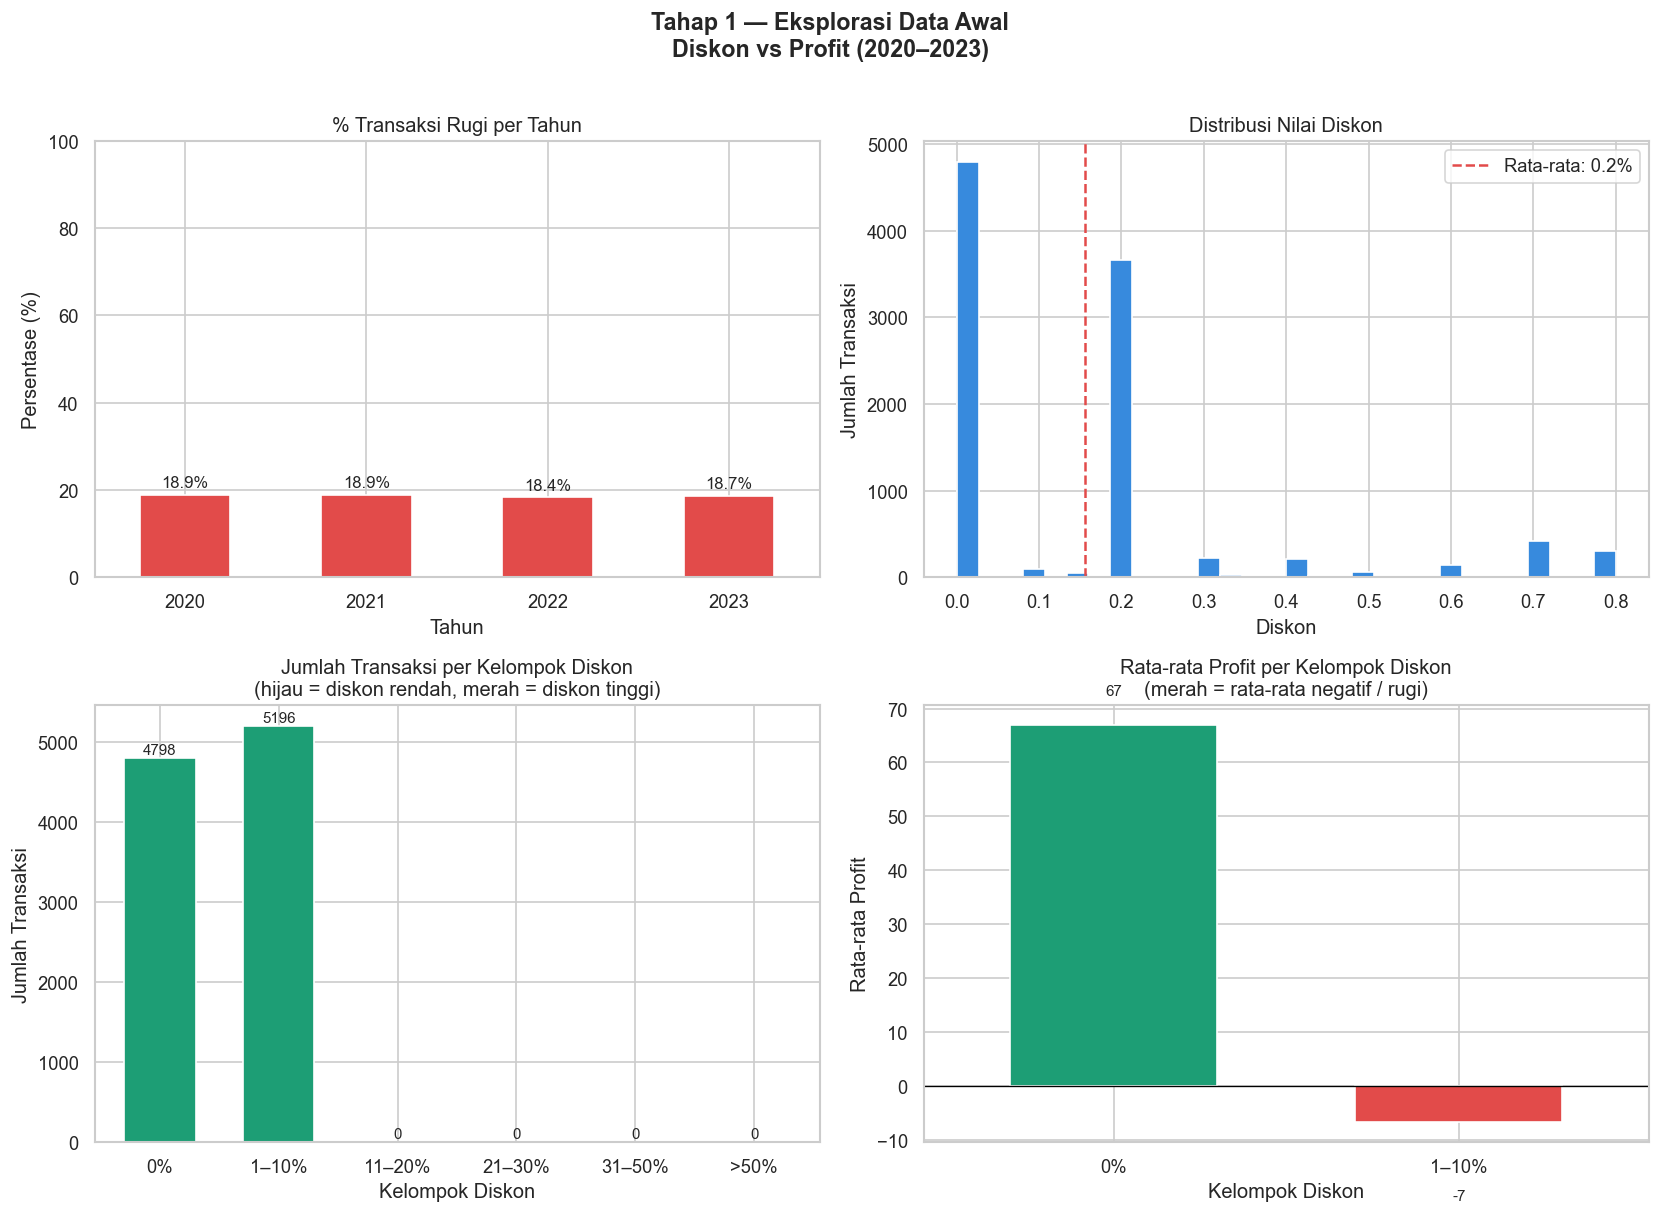


 Visualisasi disimpan sebagai: hasil_eda.png

RANGKUMAN TEMUAN
Total transaksi          : 9,994
Transaksi rugi           : 1,871 (18.7%)
Rata-rata diskon (rugi)  : 0.5%
Rata-rata diskon (untung): 0.1%

➡ Selisih rata-rata diskon: 0.4 poin persentase



In [486]:

# EKSPLORASI DATA AWAL (EDA)
# Analisis Pengaruh Diskon terhadap Profit (2020–2023)

# ── TANDAI TRANSAKSI RUGI & UNTUNG ─────────────────────
# Transaksi rugi = Profit < 0
df["Status"] = df["Profit"].apply(lambda x: "Rugi" if x < 0 else "Untung")

print("\n Jumlah transaksi per status:")
print(df["Status"].value_counts())


# ── PROPORSI TRANSAKSI RUGI PER TAHUN ──────────────────
# Hitung berapa % transaksi yang rugi di setiap tahun
rugi_per_tahun = (
    df.groupby("Year")["Status"]
    .value_counts(normalize=True)   # normalize=True → hasilnya persentase (0–1)
    .mul(100)                        # kalikan 100 agar jadi persen
    .round(1)
    .unstack(fill_value=0)           # pivot: kolom = Rugi / Untung
)

print("\n % Transaksi per Tahun:")
print(rugi_per_tahun)


# ── DISTRIBUSI NILAI DISKON ─────────────────────────────
# Buat kelompok (bin) diskon agar mudah dianalisis
bins   = [-1, 0, 10, 20, 30, 50, 100]
labels = ["0%", "1–10%", "11–20%", "21–30%", "31–50%", ">50%"]

df["Kelompok Diskon"] = pd.cut(
    df["Discount"],
    bins=bins,
    labels=labels
)

print("\n Jumlah transaksi per kelompok diskon:")
print(df["Kelompok Diskon"].value_counts().sort_index())


#  VISUALISASI — 4 CHART DALAM 1 GAMBAR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tahap 1 — Eksplorasi Data Awal\nDiskon vs Profit (2020–2023)",
             fontsize=14, fontweight="bold", y=1.01)

warna_rugi   = "#E24B4A"   # merah untuk rugi
warna_untung = "#1D9E75"   # hijau untuk untung


# ── % Transaksi Rugi per Tahun (bar chart) ───────
ax = axes[0, 0]
if "Rugi" in rugi_per_tahun.columns:
    rugi_per_tahun["Rugi"].plot(kind="bar", ax=ax, color=warna_rugi, width=0.5)
ax.set_title("% Transaksi Rugi per Tahun")
ax.set_xlabel("Tahun")
ax.set_ylabel("Persentase (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
# Tambahkan label nilai di atas setiap bar
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10)


# ── Distribusi Diskon (histogram) ────────────────
ax = axes[0, 1]
ax.hist(df["Discount"], bins=30, color="#378ADD", edgecolor="white")
ax.set_title("Distribusi Nilai Diskon")
ax.set_xlabel("Diskon")
ax.set_ylabel("Jumlah Transaksi")
# Garis vertikal rata-rata diskon
rata_diskon = df["Discount"].mean()
ax.axvline(rata_diskon, color=warna_rugi, linestyle="--", linewidth=1.5,
           label=f"Rata-rata: {rata_diskon:.1f}%")
ax.legend()


# ── Jumlah Transaksi per Kelompok Diskon ─────────
ax = axes[1, 0]
hitung = df["Kelompok Diskon"].value_counts().sort_index()
warna_bars = [warna_untung if l in ["0%", "1–10%", "11–20%"]
              else warna_rugi for l in hitung.index]
hitung.plot(kind="bar", ax=ax, color=warna_bars, width=0.6)
ax.set_title("Jumlah Transaksi per Kelompok Diskon\n(hijau = diskon rendah, merah = diskon tinggi)")
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Jumlah Transaksi")
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=9)


# ── Rata-rata Profit per Kelompok Diskon ─────────
ax = axes[1, 1]
rata_profit = df.groupby("Kelompok Diskon", observed=True)["Profit"].mean().round(2)
warna_profit = [warna_untung if v >= 0 else warna_rugi for v in rata_profit]
rata_profit.plot(kind="bar", ax=ax, color=warna_profit, width=0.6)
ax.set_title("Rata-rata Profit per Kelompok Diskon\n(merah = rata-rata negatif / rugi)")
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Rata-rata Profit")
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (5 if bar.get_height() >= 0 else -15),
            f"{bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=9)


plt.tight_layout()
plt.savefig("tahap1_eda_hasil.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Visualisasi disimpan sebagai: hasil_eda.png")


print("\n" + "="*50)
print("RANGKUMAN TEMUAN")
print("="*50)

total          = len(df)
total_rugi     = (df["Status"] == "Rugi").sum()
pct_rugi       = total_rugi / total * 100
avg_diskon_rugi    = df[df["Status"] == "Rugi"]["Discount"].mean()
avg_diskon_untung  = df[df["Status"] == "Untung"]["Discount"].mean()

print(f"Total transaksi          : {total:,}")
print(f"Transaksi rugi           : {total_rugi:,} ({pct_rugi:.1f}%)")
print(f"Rata-rata diskon (rugi)  : {avg_diskon_rugi:.1f}%")
print(f"Rata-rata diskon (untung): {avg_diskon_untung:.1f}%")
print(f"\n➡ Selisih rata-rata diskon: {avg_diskon_rugi - avg_diskon_untung:.1f} poin persentase")
print()

### Diskon vs Profit (2020–2023)

Berdasarkan hasil visualisasi data, ditemukan korelasi yang signifikan antara pemberian diskon dengan profit yang dihasilkan perusahaan. Berikut adalah rincian temuannya:
Berdasarkan data, mayoritas transaksi menghasilkan keuntungan. Dari total transaksi:

- **Untung:** 8.123 transaksi (≈ 81%)
- **Rugi:** 1.871 transaksi (≈ 19%)

Hal ini menunjukkan bahwa secara umum perusahaan masih berada dalam kondisi profitabilitas yang baik.

---

### Persentase Transaksi Rugi per Tahun

Persentase transaksi rugi relatif stabil selama periode 2020–2023:

- **2020:** 18,9%
- **2021:** 18,9%
- **2022:** 18,4%
- **2023:** 18,7%

Tidak terdapat perubahan signifikan tiap tahun, yang mengindikasikan bahwa faktor penyebab kerugian bersifat konsisten dan sistematis, bukan kejadian temporer.

---

### Distribusi Diskon
Distribusi transaksi berdasarkan tingkat diskon menunjukkan:

- **0% diskon:** 4.798 transaksi  
- **1–10% diskon:** 5.196 transaksi  
- **>10% diskon:** Tidak ada transaksi  

Mayoritas transaksi berada pada diskon rendah (0–10%), dengan rata-rata diskon sekitar **0,2 (20%)** pada visual distribusi.

---

### Hubungan Diskon dengan Profit
Rata-rata profit berdasarkan kelompok diskon menunjukkan pola yang jelas:

- **Diskon 0% → Profit tinggi (≈ 67)**
- **Diskon 1–10% → Profit negatif (≈ -7)**

Hal ini mengindikasikan bahwa:
- Pemberian diskon, bahkan dalam jumlah kecil, dapat menurunkan profit secara signifikan.
- Diskon berpotensi menjadi faktor penyebab kerugian.


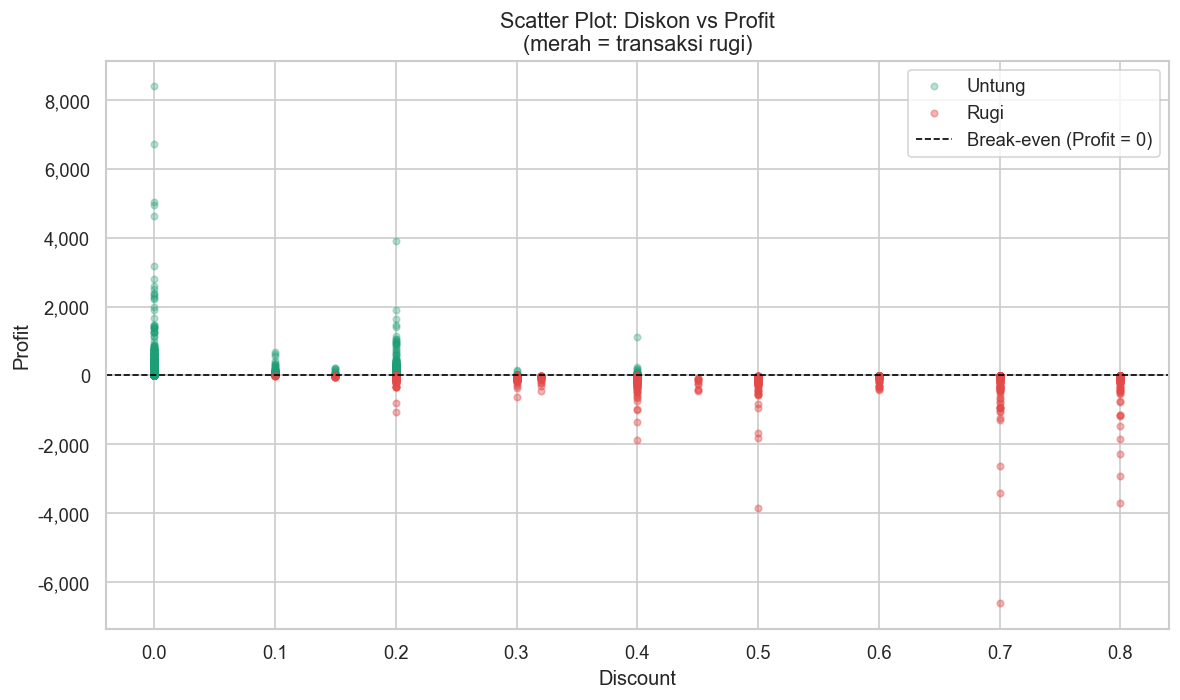

scatter.png


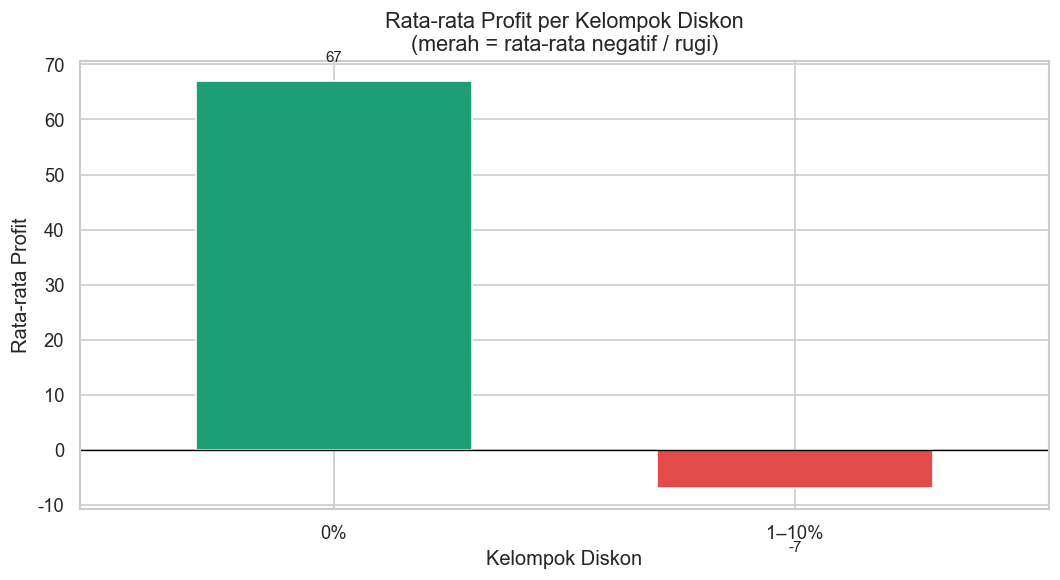

 bar_rata_profit.png


C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\2571067803.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


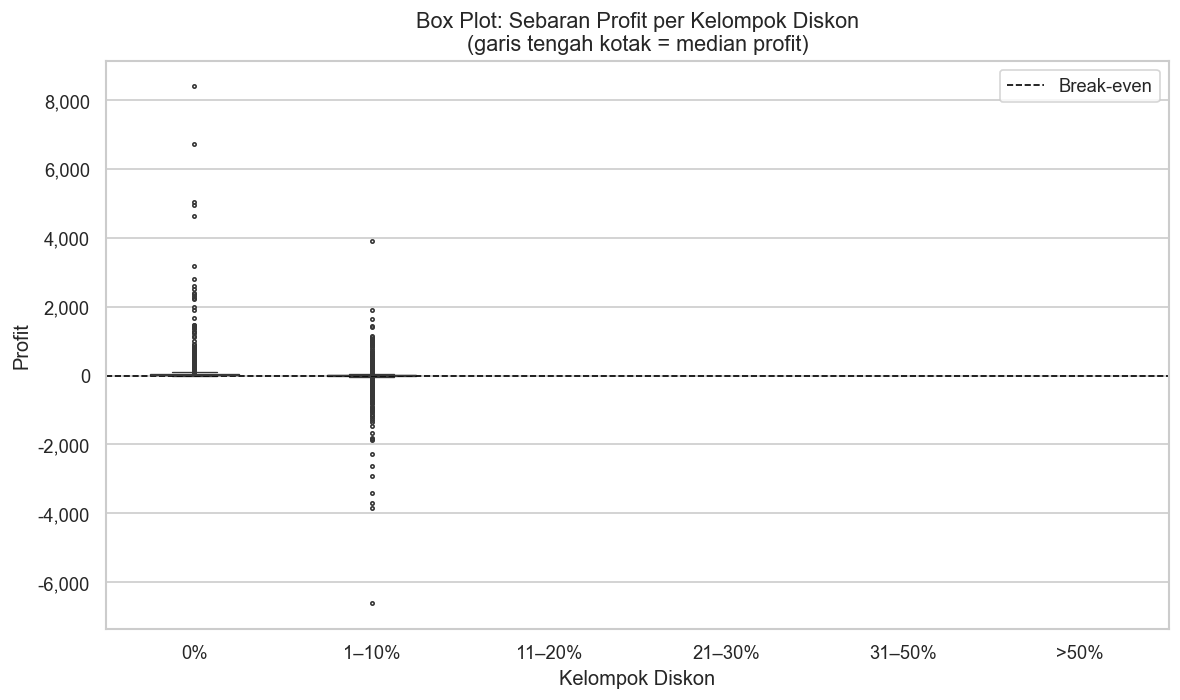

boxplot.png


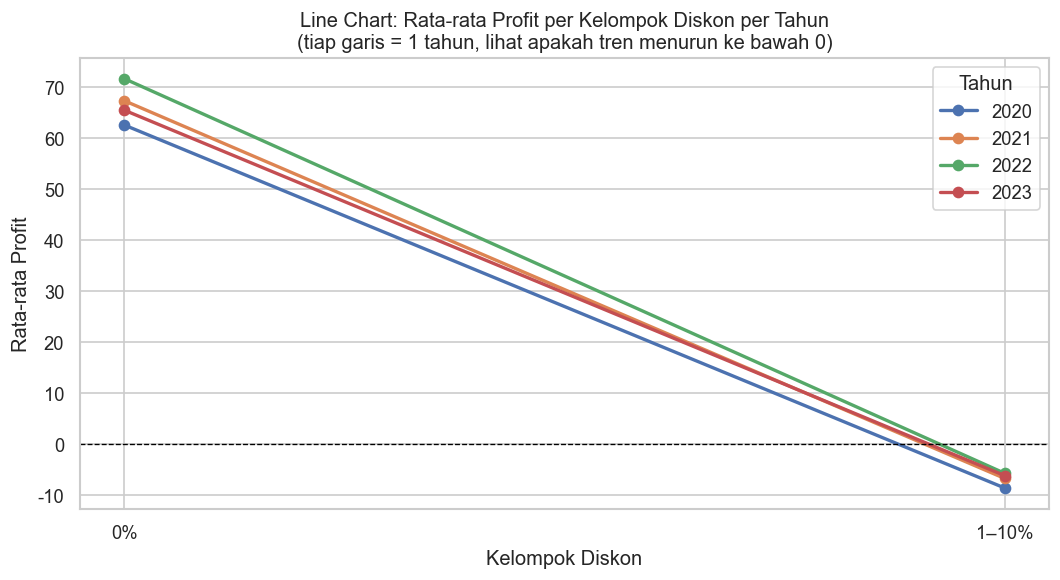

 line_tren.png


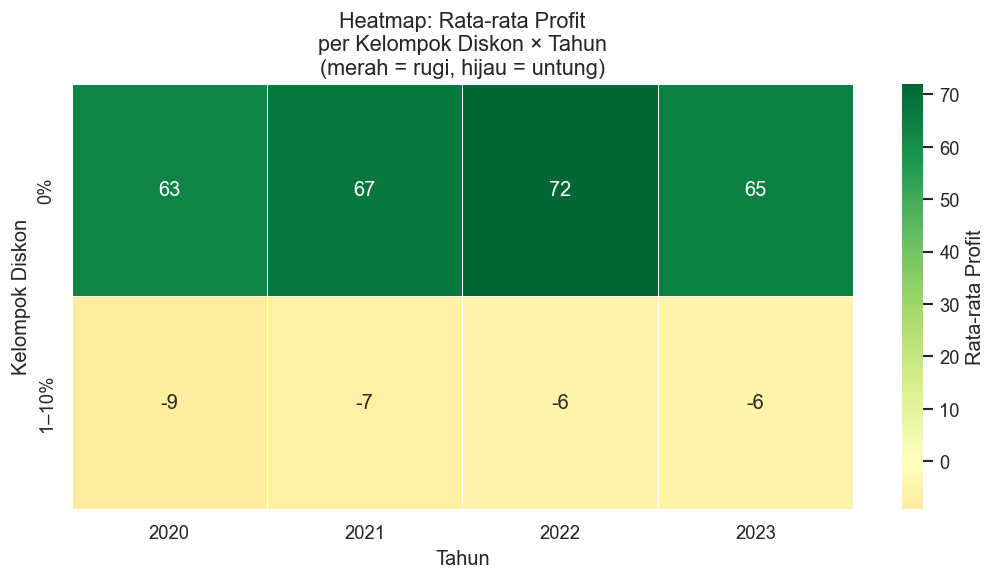

heatmap.png

RANGKUMAN TEMUAN

Rata-rata Profit per Kelompok Diskon:
Kelompok Diskon
0%       67.0
1–10%    -7.0

→ Perhatikan di kelompok mana profit mulai negatif.



In [487]:
# VISUALISASI HUBUNGAN DISKON → PROFIT
# Analisis Pengaruh Diskon terhadap Profit (2020–2023)

# Buat kolom status rugi/untung
df["Status"] = df["Profit"].apply(lambda x: "Rugi" if x < 0 else "Untung")

# Buat kelompok diskon (bin)
bins   = [-1, 0, 10, 20, 30, 50, 100]
labels = ["0%", "1–10%", "11–20%", "21–30%", "31–50%", ">50%"]
df["Kelompok Diskon"] = pd.cut(df["Discount"], bins=bins, labels=labels)

# Warna konsisten
MERAH  = "#E24B4A"
HIJAU  = "#1D9E75"
BIRU   = "#378ADD"
ABU    = "#888780"

#  SCATTER PLOT: Diskon vs Profit
#  Setiap titik = 1 transaksi, merah = rugi, hijau = untung

fig1, ax = plt.subplots(figsize=(10, 6))

# Plot transaksi untung dulu (agar rugi tampil di atas / tidak tertutup)
untung = df[df["Status"] == "Untung"]
rugi   = df[df["Status"] == "Rugi"]

ax.scatter(untung["Discount"], untung["Profit"],
           color=HIJAU, alpha=0.3, s=15, label="Untung")
ax.scatter(rugi["Discount"],   rugi["Profit"],
           color=MERAH, alpha=0.4, s=15, label="Rugi")

# Garis horizontal di Profit = 0 sebagai batas untung/rugi
ax.axhline(0, color="black", linewidth=1, linestyle="--", label="Break-even (Profit = 0)")

ax.set_title("Scatter Plot: Diskon vs Profit\n(merah = transaksi rugi)", fontsize=13)
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("scatter.png")


#  BAR CHART: Rata-rata Profit per Kelompok Diskon
#  Setiap bar = rata-rata profit dari semua transaksi di kelompok itu

fig2, ax = plt.subplots(figsize=(9, 5))

rata_profit = (df.groupby("Kelompok Diskon", observed=True)["Profit"]
                 .mean()
                 .round(0))

# Warnai merah jika rata-rata profit negatif
warna = [MERAH if v < 0 else HIJAU for v in rata_profit]

bars = rata_profit.plot(kind="bar", ax=ax, color=warna, width=0.6, edgecolor="white")

# Tambahkan label nilai di setiap bar
for bar in ax.patches:
    nilai = bar.get_height()
    posisi_y = nilai + 3 if nilai >= 0 else nilai - 12
    ax.text(bar.get_x() + bar.get_width() / 2,
            posisi_y,
            f"{nilai:,.0f}",
            ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rata-rata Profit per Kelompok Diskon\n(merah = rata-rata negatif / rugi)", fontsize=13)
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Rata-rata Profit")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("bar_rata_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print(" bar_rata_profit.png")

#  BOX PLOT: Sebaran Profit per Kelompok Diskon
#  Box plot menampilkan median, kuartil, dan outlier → berguna untuk melihat VARIASI profit di tiap kelompok

fig3, ax = plt.subplots(figsize=(10, 6))

# Seaborn boxplot lebih mudah dibaca
sns.boxplot(
    data=df,
    x="Kelompok Diskon",
    y="Profit",
    palette={"0%": HIJAU, "1–10%": HIJAU, "11–20%": HIJAU,
             "21–30%": MERAH, "31–50%": MERAH, ">50%": MERAH},
    width=0.5,
    fliersize=2,       # ukuran titik outlier diperkecil agar tidak berantakan
    linewidth=0.8,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1, linestyle="--", label="Break-even")
ax.set_title("Box Plot: Sebaran Profit per Kelompok Diskon\n"
             "(garis tengah kotak = median profit)", fontsize=13)
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Profit")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("boxplot.png")

#  LINE CHART: Tren Rata-rata Profit vs Diskon
#  Memperlihatkan apakah profit TURUN secara konsisten seiring kenaikan diskon

fig4, ax = plt.subplots(figsize=(9, 5))

# Hitung rata-rata profit per kelompok diskon per tahun
tren = (df.groupby(["Year", "Kelompok Diskon"], observed=True)["Profit"]
          .mean()
          .reset_index())

# Buat satu garis per tahun
for tahun, grup in tren.groupby("Year"):
    ax.plot(grup["Kelompok Diskon"].astype(str),
            grup["Profit"],
            marker="o", linewidth=2,
            label=str(tahun))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Line Chart: Rata-rata Profit per Kelompok Diskon per Tahun\n"
             "(tiap garis = 1 tahun, lihat apakah tren menurun ke bawah 0)", fontsize=12)
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Rata-rata Profit")
ax.legend(title="Tahun")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("line_tren.png", dpi=150, bbox_inches="tight")
plt.show()
print(" line_tren.png")



#  HEATMAP: Kelompok Diskon × Tahun → Rata-rata Profit
#  Warna merah = rugi, hijau = untung → satu pandangan untuk melihat pola 4 tahun sekaligus

fig5, ax = plt.subplots(figsize=(9, 5))

# Buat tabel pivot: baris = kelompok diskon, kolom = tahun
pivot = (df.groupby(["Kelompok Diskon", "Year"], observed=True)["Profit"]
           .mean()
           .unstack("Year")   # jadikan tahun sebagai kolom
           .round(0))

# diverging colormap: merah (negatif) → putih (nol) → hijau (positif)
sns.heatmap(
    pivot,
    annot=True,                   # tampilkan angka di tiap sel
    fmt=".0f",                    # format angka tanpa desimal
    cmap="RdYlGn",                # merah-kuning-hijau
    center=0,                     # titik tengah warna = 0 (break-even)
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Rata-rata Profit"}
)

ax.set_title("Heatmap: Rata-rata Profit\nper Kelompok Diskon × Tahun\n"
             "(merah = rugi, hijau = untung)", fontsize=13)
ax.set_xlabel("Tahun")
ax.set_ylabel("Kelompok Diskon")

plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("heatmap.png")

#  RANGKUMAN TEMUAN 
print("\n" + "="*55)
print("RANGKUMAN TEMUAN")
print("="*55)
print(f"\nRata-rata Profit per Kelompok Diskon:")
print(rata_profit.to_string())
print("\n→ Perhatikan di kelompok mana profit mulai negatif.")
print()

# Pengaruh Diskon terhadap Profit (2020–2023)

### 1. Hubungan Diskon dan Profit
Berdasarkan scatter plot, terlihat pola yang jelas antara diskon dan profit:

- Transaksi dengan **diskon rendah (0–10%)** didominasi oleh profit positif (untung)
- Transaksi dengan **diskon lebih tinggi** cenderung menghasilkan profit negatif (rugi)
- Titik merah (rugi) semakin banyak muncul pada diskon yang lebih besar
- Garis break-even (profit = 0) menunjukkan bahwa banyak transaksi dengan diskon tinggi berada di bawah garis tersebut

Hal ini menunjukkan adanya **hubungan negatif antara diskon dan profit**.

---

### 2. Rata-rata Profit per Kelompok Diskon
Rata-rata profit berdasarkan kelompok diskon menunjukkan:

- **0% diskon → profit tinggi (≈ 63–72)**
- **1–10% diskon → profit negatif (≈ -6 sampai -9)**

Artinya:
- Tanpa diskon, perusahaan memperoleh keuntungan yang signifikan
- Bahkan diskon kecil (1–10%) sudah menyebabkan rata-rata kerugian

---

### 3. Sebaran Profit (Box Plot)
Dari box plot:

- Kelompok **0% diskon**:
  - Mayoritas transaksi berada di atas garis profit = 0
  - Memiliki banyak outlier positif (profit tinggi)

- Kelompok **1–10% diskon**:
  - Sebaran lebih banyak berada di bawah 0
  - Banyak outlier negatif (kerugian besar)

Ini menunjukkan bahwa:
- Diskon meningkatkan **variabilitas profit**
- Risiko kerugian menjadi lebih tinggi saat diskon diberikan

---

### 4. Tren Profit per Tahun
Berdasarkan line chart:

- Semua tahun (2020–2023) menunjukkan pola yang sama:
  - Profit tinggi pada **0% diskon**
  - Profit turun drastis menjadi negatif pada **1–10% diskon**
- Tidak ada perubahan pola signifikan antar tahun

Artinya:
- Dampak negatif diskon terhadap profit **konsisten setiap tahun**

---

### 5. Heatmap (Diskon vs Tahun)
Dari heatmap:

- **0% diskon** selalu menghasilkan profit positif (63–72)
- **1–10% diskon** selalu menghasilkan profit negatif (-9 sampai -6)
- Tidak ada tahun di mana diskon memberikan dampak positif terhadap profit

Ini memperkuat bahwa:
- Diskon secara konsisten berkorelasi dengan penurunan profit

---


KORELASI DISKON vs PROFIT

Korelasi Pearson  : r = -0.219  (p-value = 0.0000)
Korelasi Spearman : r = -0.543  (p-value = 0.0000)

Interpretasi Pearson  : LEMAH
Interpretasi Spearman : SEDANG

 Hubungan ini SIGNIFIKAN secara statistik (p < 0.05)

THRESHOLD DISKON KRITIS

 Threshold ditemukan: mulai diskon 0%
 → rata-rata profit sudah NEGATIF di level ini

 Rata-rata Profit per Kelompok Diskon:
                 Rata-rata Profit  Jumlah Transaksi
Kelompok Diskon                                    
0%                           66.9              4798
1–10%                        -6.7              5196

DISKON RENDAH vs DISKON TINGGI

% Transaksi per Grup (batas = 0%):
Status               Rugi  Untung
Grup Diskon                      
Diskon Rendah (<0%)   6.1    93.9
Diskon Tinggi (≥0%)  96.8     3.2

  Diskon Rendah (<0%): 6.1% transaksi rugi

  Diskon Tinggi (≥0%): 96.8% transaksi rugi

UJI STATISTIK (MANN-WHITNEY U TEST)

Rata-rata Profit — Diskon Rendah : 49.0
Rata-rata Profit — Diskon

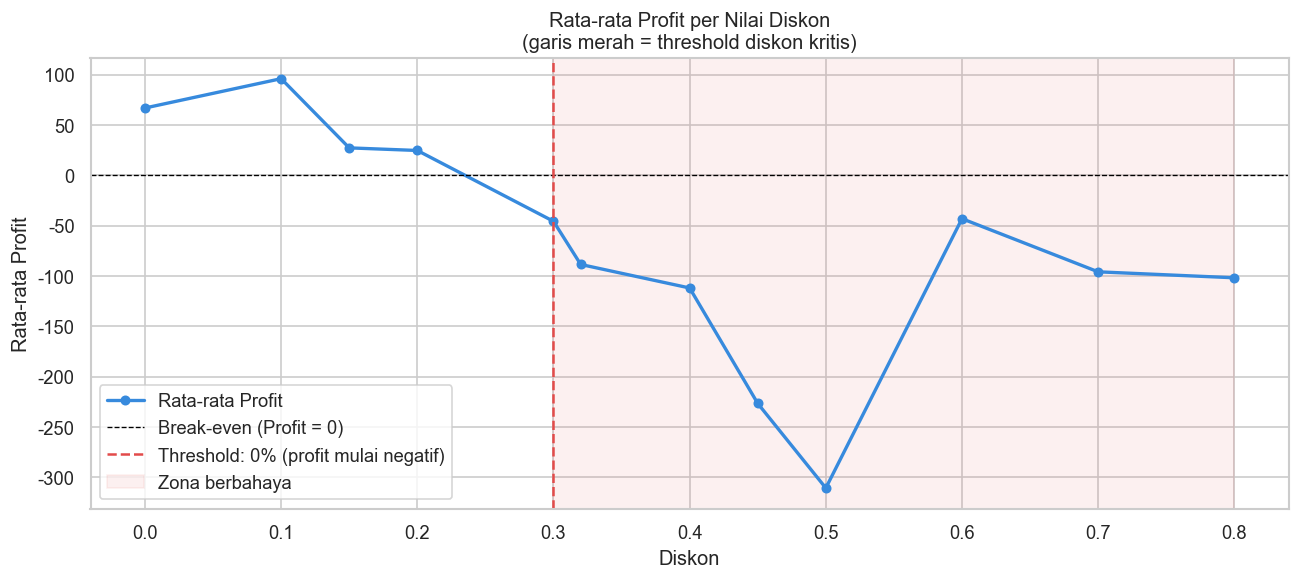


 threshold.png


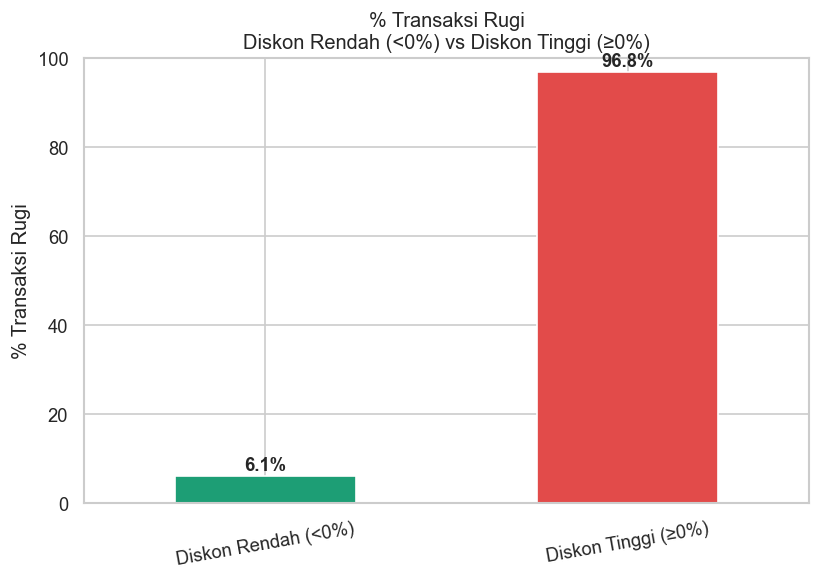

rugi_rendah_vs_tinggi.png


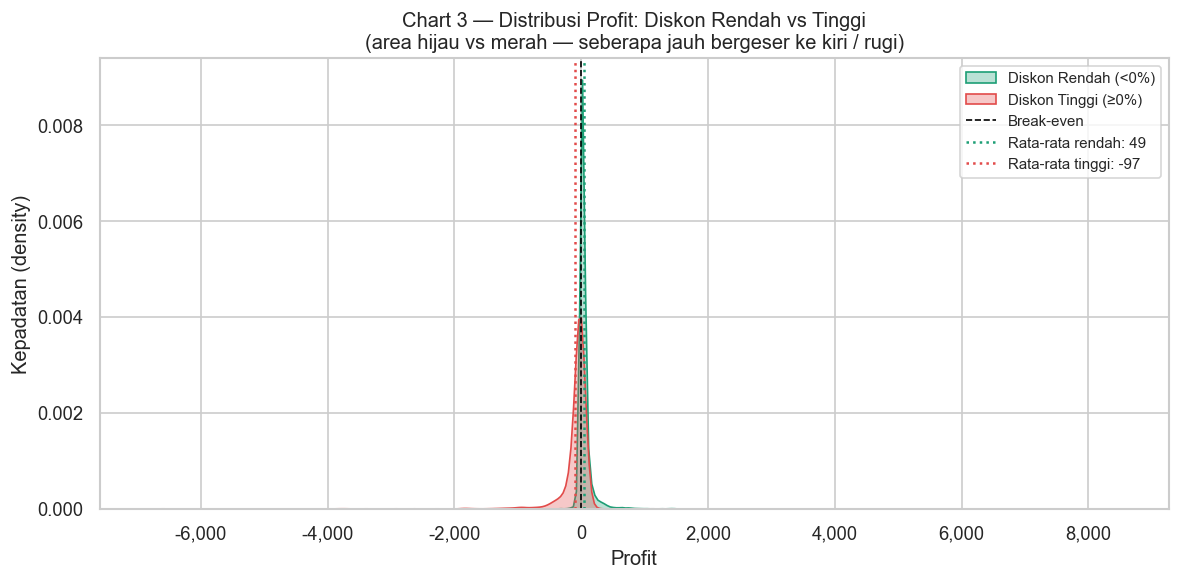

distribusi_profit.png

RINGKASAN TEMUAN
  Korelasi Pearson         : -0.219  (LEMAH)
  Korelasi Spearman        : -0.543  (SEDANG)
  Threshold kritis         : ≥ 0% → rata-rata profit negatif
  Signifikansi (p-value)   : 0.000000 Signifikan



In [488]:
# ANALISIS STATISTIK & THRESHOLD DISKON KRITIS
# Analisis Pengaruh Diskon terhadap Profit (2020–2023)

df["Status"] = df["Profit"].apply(lambda x: "Rugi" if x < 0 else "Untung")

bins   = [-1, 0, 10, 20, 30, 50, 100]
labels = ["0%", "1–10%", "11–20%", "21–30%", "31–50%", ">50%"]
df["Kelompok Diskon"] = pd.cut(df["Discount"], bins=bins, labels=labels)

MERAH = "#E24B4A"
HIJAU = "#1D9E75"
BIRU  = "#378ADD"


#  KORELASI
#  Mengukur SEBERAPA KUAT hubungan antara Diskon dan Profit Nilai berkisar -1 hingga +1: -1 = hubungan negatif sempurna (diskon naik → profit turun) 0 = tidak ada hubungan +1 = hubungan positif sempurna

print("=" * 55)
print("KORELASI DISKON vs PROFIT")
print("=" * 55)

# Pearson: mengasumsikan hubungan linear
r_pearson, p_pearson = stats.pearsonr(df["Discount"], df["Profit"])

# Spearman: lebih kuat untuk data tidak normal / ada outlier
r_spearman, p_spearman = stats.spearmanr(df["Discount"], df["Profit"])

print(f"\nKorelasi Pearson  : r = {r_pearson:.3f}  (p-value = {p_pearson:.4f})")
print(f"Korelasi Spearman : r = {r_spearman:.3f}  (p-value = {p_spearman:.4f})")

# Interpretasi otomatis
def interpretasi_korelasi(r):
    r = abs(r)
    if r >= 0.7:  return "KUAT"
    elif r >= 0.4: return "SEDANG"
    elif r >= 0.2: return "LEMAH"
    else:          return "SANGAT LEMAH / TIDAK ADA"

print(f"\nInterpretasi Pearson  : {interpretasi_korelasi(r_pearson)}")
print(f"Interpretasi Spearman : {interpretasi_korelasi(r_spearman)}")

if p_pearson < 0.05:
    print("\n Hubungan ini SIGNIFIKAN secara statistik (p < 0.05)")
else:
    print("\n Hubungan ini TIDAK signifikan secara statistik (p ≥ 0.05)")

#  MENCARI THRESHOLD DISKON KRITIS
#  Threshold = level diskon di mana rata-rata profit MULAI NEGATIF
#  Cara: hitung rata-rata profit untuk setiap nilai diskon unik, lalu cari di mana pertama kali menjadi negatif

print("\n" + "=" * 55)
print("THRESHOLD DISKON KRITIS")
print("=" * 55)

# Rata-rata profit per nilai diskon (diurutkan)
profit_per_diskon = (df.groupby("Discount")["Profit"]
                       .mean()
                       .reset_index()
                       .sort_values("Discount"))

# Temukan threshold: nilai diskon pertama kali rata-rata profit < 0
negatif = profit_per_diskon[profit_per_diskon["Profit"] < 0]

if not negatif.empty:
    threshold = negatif["Discount"].min()
    print(f"\n Threshold ditemukan: mulai diskon {threshold:.0f}%")
    print(f" → rata-rata profit sudah NEGATIF di level ini")
else:
    threshold = None
    print("\n Tidak ditemukan threshold — rata-rata profit selalu positif")

# Tampilkan tabel rata-rata profit per kelompok diskon
print("\n Rata-rata Profit per Kelompok Diskon:")
tabel = (df.groupby("Kelompok Diskon", observed=True)["Profit"]
           .agg(["mean", "count"])
           .rename(columns={"mean": "Rata-rata Profit", "count": "Jumlah Transaksi"})
           .round(1))
print(tabel.to_string())

# PERBANDINGAN DISKON RENDAH vs TINGGI
# Pisahkan transaksi menjadi dua grup berdasarkan threshold, lalu bandingkan % kerugiannya

print("\n" + "=" * 55)
print("DISKON RENDAH vs DISKON TINGGI")
print("=" * 55)

# Gunakan threshold dari Bagian B, atau default 20% jika tidak ditemukan
batas = threshold if threshold is not None else 20

df["Grup Diskon"] = df["Discount"].apply(
    lambda x: f"Diskon Tinggi (≥{batas:.0f}%)" if x >= batas
              else f"Diskon Rendah (<{batas:.0f}%)"
)

# Hitung % transaksi rugi di masing-masing grup
pct_rugi = (df.groupby("Grup Diskon")["Status"]
              .value_counts(normalize=True)
              .mul(100)
              .round(1)
              .unstack(fill_value=0))

print(f"\n% Transaksi per Grup (batas = {batas:.0f}%):")
print(pct_rugi.to_string())

# Ringkasan
for grup in pct_rugi.index:
    pct = pct_rugi.loc[grup, "Rugi"] if "Rugi" in pct_rugi.columns else 0
    print(f"\n  {grup}: {pct:.1f}% transaksi rugi")


#  UJI T-TEST (MANN-WHITNEY)
#  Membuktikan apakah perbedaan profit antara dua grup benar-benar SIGNIFIKAN atau hanya kebetulan H0 (hipotesis nol)  : tidak ada perbedaan profit antar grup H1 (hipotesis alt.) : ada perbedaan nyata
#  Jika p < 0.05 → tolak H0 → perbedaan SIGNIFIKAN

print("\n" + "=" * 55)
print("UJI STATISTIK (MANN-WHITNEY U TEST)")
print("=" * 55)

grup_rendah = df[df["Grup Diskon"].str.contains("Rendah")]["Profit"]
grup_tinggi = df[df["Grup Diskon"].str.contains("Tinggi")]["Profit"]

# Mann-Whitney lebih tepat daripada t-test biasa karena data profit tidak normal
stat, p_value = stats.mannwhitneyu(grup_rendah, grup_tinggi, alternative="greater")

print(f"\nRata-rata Profit — Diskon Rendah : {grup_rendah.mean():,.1f}")
print(f"Rata-rata Profit — Diskon Tinggi : {grup_tinggi.mean():,.1f}")
print(f"\nMann-Whitney U statistic : {stat:,.0f}")
print(f"P-value                  : {p_value:.6f}")

if p_value < 0.05:
    print("\n KESIMPULAN: Perbedaan profit antara diskon rendah dan tinggi")
    print("   SIGNIFIKAN secara statistik (p < 0.05)")
    print(" → Diskon tinggi terbukti menurunkan profit secara nyata.")
else:
    print("\n  KESIMPULAN: Perbedaan TIDAK signifikan secara statistik (p ≥ 0.05)")

#  VISUALISASI — 3 CHART
# ── Rata-rata Profit per Nilai Diskon + Garis Threshold ──

fig1, ax = plt.subplots(figsize=(11, 5))

ax.plot(profit_per_diskon["Discount"],
        profit_per_diskon["Profit"],
        color=BIRU, linewidth=2, marker="o", markersize=5, label="Rata-rata Profit")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="Break-even (Profit = 0)")

if threshold is not None:
    ax.axvline(threshold, color=MERAH, linewidth=1.5, linestyle="--",
               label=f"Threshold: {threshold:.0f}% (profit mulai negatif)")
    # Area diskon berbahaya
    ax.axvspan(threshold, df["Discount"].max(),
               alpha=0.08, color=MERAH, label="Zona berbahaya")

ax.set_title("Rata-rata Profit per Nilai Diskon\n"
             "(garis merah = threshold diskon kritis)", fontsize=12)
ax.set_xlabel("Diskon")
ax.set_ylabel("Rata-rata Profit")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("threshold.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n threshold.png")


# ── % Transaksi Rugi — Diskon Rendah vs Tinggi ──

fig2, ax = plt.subplots(figsize=(7, 5))

if "Rugi" in pct_rugi.columns:
    pct_rugi_vals = pct_rugi["Rugi"]
    warna = [HIJAU if "Rendah" in g else MERAH for g in pct_rugi_vals.index]
    bars = pct_rugi_vals.plot(kind="bar", ax=ax, color=warna, width=0.5, edgecolor="white")

    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title(f"% Transaksi Rugi\nDiskon Rendah (<{batas:.0f}%) vs Diskon Tinggi (≥{batas:.0f}%)",
             fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("% Transaksi Rugi")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("rugi_rendah_vs_tinggi.png", dpi=150, bbox_inches="tight")
plt.show()
print("rugi_rendah_vs_tinggi.png")


# ── Distribusi Profit — Diskon Rendah vs Tinggi (KDE) ──

fig3, ax = plt.subplots(figsize=(10, 5))

# KDE = Kernel Density Estimate → kurva distribusi yang lebih halus dari histogram
sns.kdeplot(grup_rendah, ax=ax, color=HIJAU, fill=True, alpha=0.3,
            label=f"Diskon Rendah (<{batas:.0f}%)")
sns.kdeplot(grup_tinggi, ax=ax, color=MERAH, fill=True, alpha=0.3,
            label=f"Diskon Tinggi (≥{batas:.0f}%)")

ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")
ax.axvline(grup_rendah.mean(), color=HIJAU, linewidth=1.5, linestyle=":",
           label=f"Rata-rata rendah: {grup_rendah.mean():,.0f}")
ax.axvline(grup_tinggi.mean(), color=MERAH, linewidth=1.5, linestyle=":",
           label=f"Rata-rata tinggi: {grup_tinggi.mean():,.0f}")

ax.set_title("Chart 3 — Distribusi Profit: Diskon Rendah vs Tinggi\n"
             "(area hijau vs merah — seberapa jauh bergeser ke kiri / rugi)", fontsize=12)
ax.set_xlabel("Profit")
ax.set_ylabel("Kepadatan (density)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("distribusi_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("distribusi_profit.png")

#  RINGKASAN TEMUAN

print("\n" + "=" * 55)
print("RINGKASAN TEMUAN")
print("=" * 55)
print(f"  Korelasi Pearson         : {r_pearson:.3f}  ({interpretasi_korelasi(r_pearson)})")
print(f"  Korelasi Spearman        : {r_spearman:.3f}  ({interpretasi_korelasi(r_spearman)})")
print(f"  Threshold kritis         : ≥ {batas:.0f}% → rata-rata profit negatif")
print(f"  Signifikansi (p-value)   : {p_value:.6f} {'Signifikan' if p_value < 0.05 else '⚠️ Tidak signifikan'}")
print()

### Analisis Deskriptif: Korelasi Diskon terhadap Profit

#### 1. Analisis Korelasi
Hasil uji korelasi menunjukkan adanya hubungan negatif antara diskon dan profit:

- **Pearson Correlation:** r = -0.219 (lemah)  
- **Spearman Correlation:** r = -0.543 (sedang)  
- **p-value:** < 0.05 (signifikan)

Interpretasi:
- Terdapat hubungan negatif antara diskon dan profit
- Semakin tinggi diskon, profit cenderung menurun
- Hubungan ini **signifikan secara statistik**, sehingga bukan terjadi secara kebetulan

Spearman yang lebih kuat menunjukkan bahwa hubungan bersifat **monotonik**, meskipun tidak selalu linear.

---

#### 2. Threshold Diskon Kritis
Dari analisis rata-rata profit terhadap diskon:

- **Threshold kritis ditemukan pada diskon ≥ 0%**
- Setelah diskon diberikan, rata-rata profit langsung menjadi negatif

Rata-rata profit per kelompok:
- **0% diskon → +66.9 (profit tinggi)**
- **1–10% diskon → -6.7 (rugi)**

Artinya:
- Bahkan diskon kecil sudah cukup untuk menurunkan profit ke zona negatif
- Diskon menjadi faktor sensitif dalam profitabilitas

---

#### 3. Perubahan Profit terhadap Level Diskon
Dari grafik tren:

- Profit menurun drastis setelah diskon melewati ~10–30%
- Penurunan semakin tajam pada diskon >30%
- Pada diskon tinggi (≥50%), profit mencapai titik terendah (kerugian besar)

Hal ini menunjukkan adanya **zona berbahaya (risk zone)** pada diskon tinggi.

---

#### 4. Analisis Persentase Kerugian
Perbandingan transaksi rugi:

- **Diskon rendah (<0%) → 6.1% rugi**
- **Diskon tinggi (≥0%) → 96.8% rugi**

Interpretasi:
- Hampir seluruh transaksi dengan diskon termasuk dalam kategori rugi
- Diskon memiliki dampak yang sangat besar terhadap kemungkinan kerugian

---

#### 5. Distribusi Profit (Diskon Rendah vs Tinggi)
Dari distribusi (density plot):

- **Diskon rendah:**
  - Distribusi cenderung di sisi kanan (profit positif)
  - Rata-rata sekitar +49

- **Diskon tinggi:**
  - Distribusi bergeser ke kiri (profit negatif)
  - Rata-rata sekitar -97

Hal ini menunjukkan:
- Diskon tinggi tidak hanya menurunkan profit rata-rata
- Tetapi juga menggeser keseluruhan distribusi ke arah kerugian

---

PER SEGMENT PELANGGAN
Segment
SMB           19.3
STRATEGIC     18.4
ENTERPRISE    17.5

 Rata-rata diskon per segment:
Segment
ENTERPRISE    0.1
SMB           0.2
STRATEGIC     0.2


C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1494403401.py:85: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


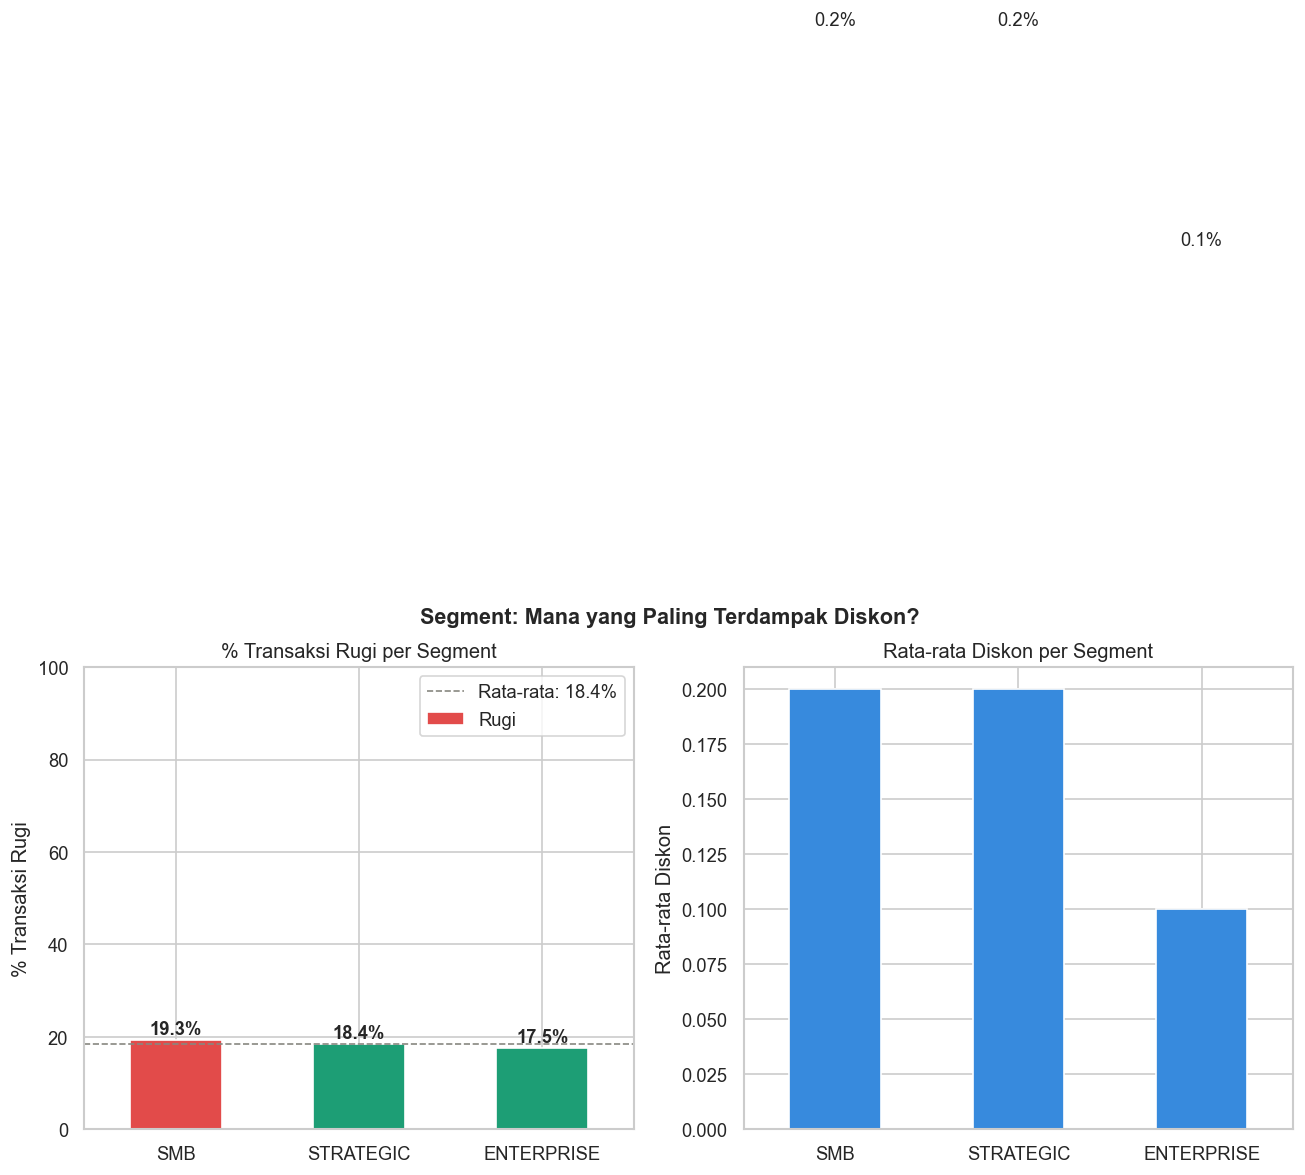

segment.png

SEGMENTASI PER PRODUK

 Ringkasan per Produk (urut % rugi):
                            Avg_Diskon  Avg_Profit  Pct_Rugi  Total_Transaksi
Product                                                                      
Marketing Suite                    0.2       -15.2      47.8              228
ContactMatcher                     0.4         6.8      44.3             1842
Big Ol Database                    0.3        29.4      38.3              115
FinanceHub                         0.1        32.8      24.0              981
Marketing Suite - Gold             0.1        25.2      19.0              846
SaaS Connector Pack                0.1        13.6      17.5              957
Site Analytics                     0.2        50.1      15.3              889
OneView                            0.2        38.9      14.4              466
Data Smasher                       0.1        54.1      11.7              775
Storage                            0.1         4.4       5.5         

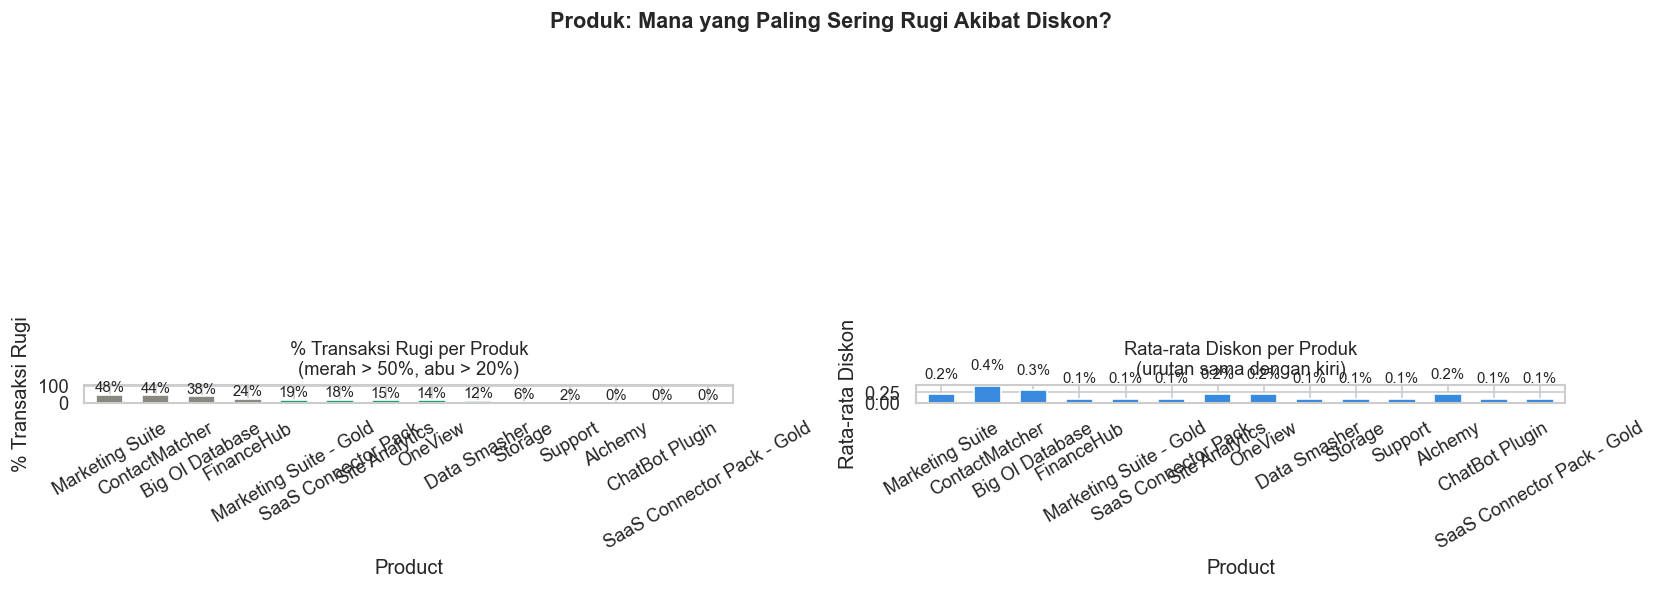

produk.png

SEGMENTASI TREN TAHUNAN (2020–2023)
Tren per Tahun:
      Pct_Diskon_Tinggi  Pct_Rugi  Avg_Diskon
Year                                         
2020                0.0    18.916        15.8
2021                0.0    18.887        15.6
2022                0.0    18.450        15.5
2023                0.0    18.710        15.6


C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1494403401.py:201: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


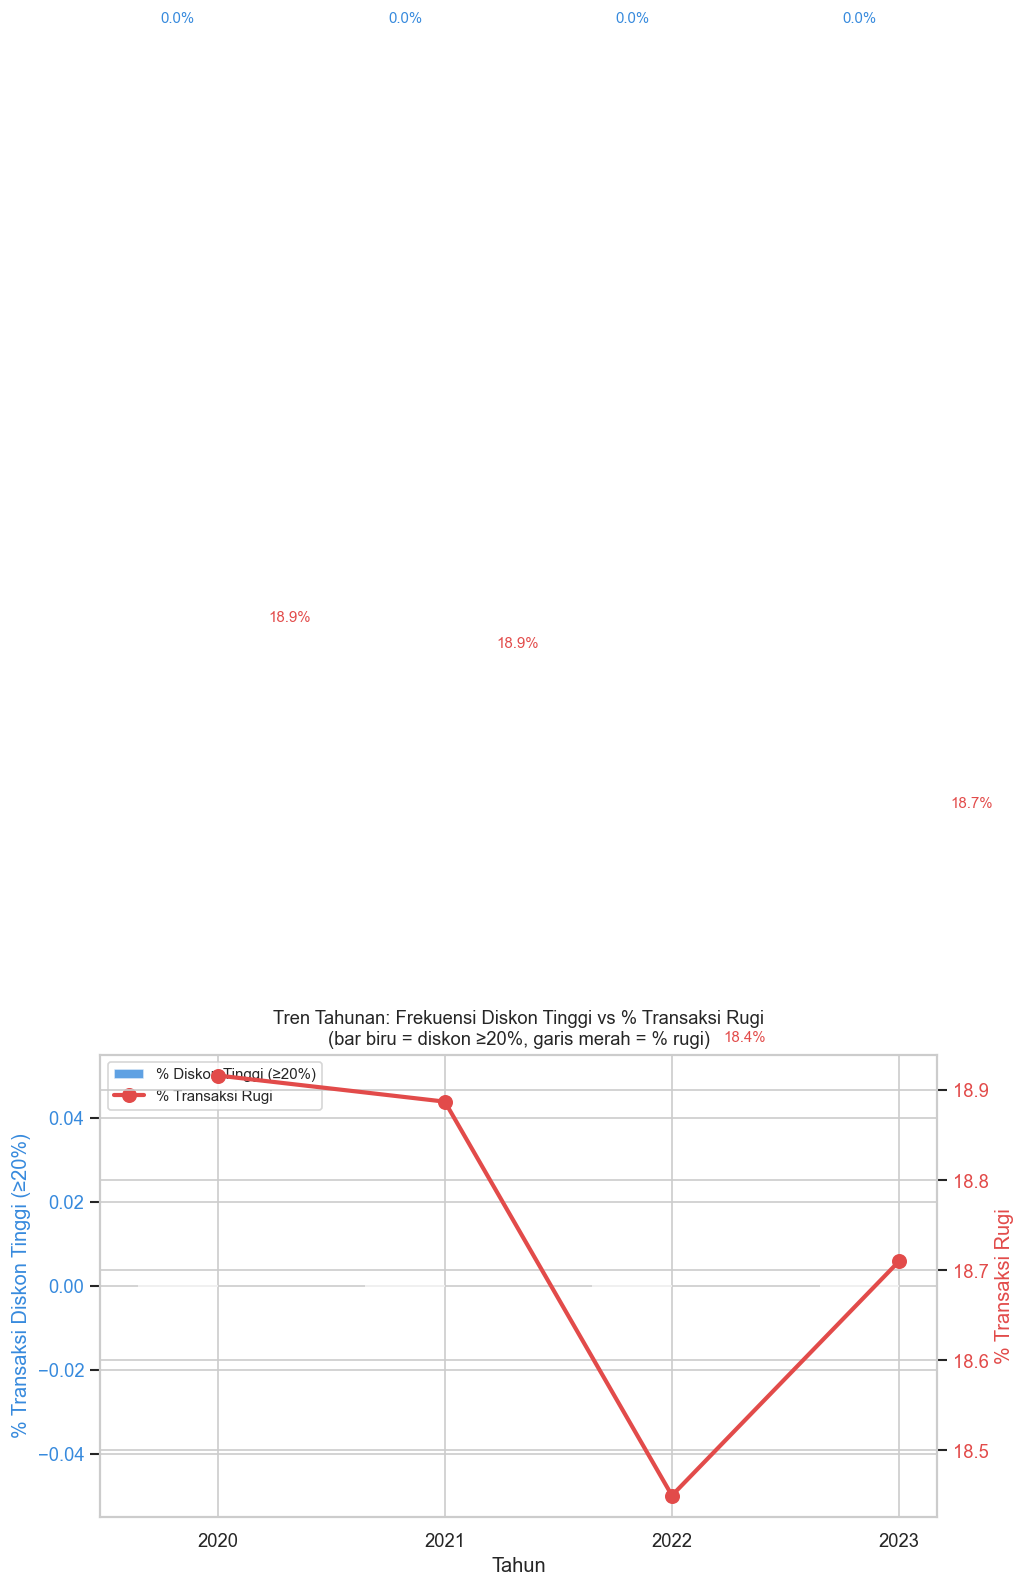

tren_tahunan.png

SEGMENTASI HEATMAP SEGMENT × KELOMPOK DISKON
% Transaksi Rugi (Segment × Kelompok Diskon):
Kelompok Diskon   0%  1–10%
Segment                    
ENTERPRISE       0.0   35.7
SMB              0.0   36.7
STRATEGIC        0.0   34.9


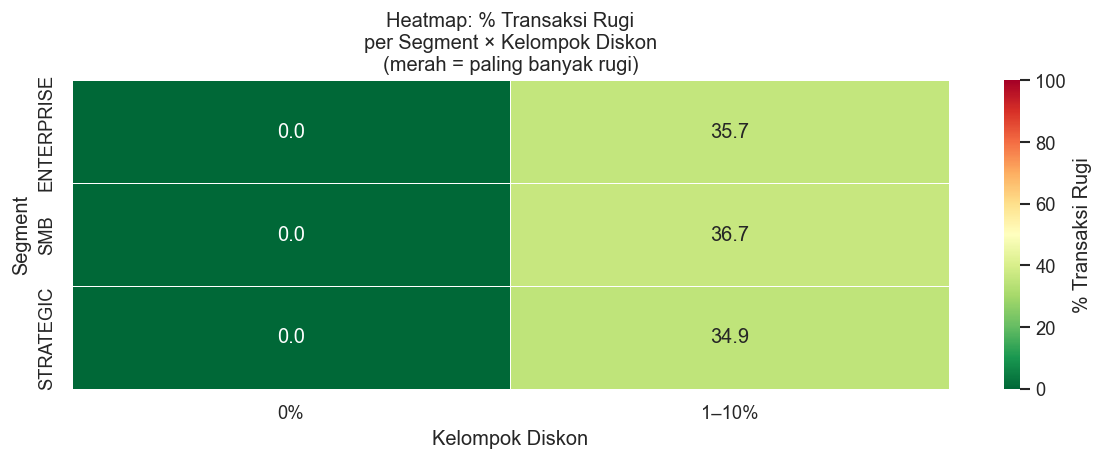

heatmap_segment_diskon.png

RANGKUMAN TEMUAN
  Segment paling terdampak : SMB (19.3% transaksi rugi)
  Produk paling terdampak  : Marketing Suite (47.8% transaksi rugi)



In [489]:
# SEGMENTASI & DRILL-DOWN
# Analisis Pengaruh Diskon terhadap Profit (2020–2023)

# Kolom status rugi / untung
df["Status"] = df["Profit"].apply(lambda x: "Rugi" if x < 0 else "Untung")

# Kelompok diskon (bin)
bins   = [-1, 0, 10, 20, 30, 50, 100]
labels = ["0%", "1–10%", "11–20%", "21–30%", "31–50%", ">50%"]
df["Kelompok Diskon"] = pd.cut(df["Discount"], bins=bins, labels=labels)

# Flag diskon tinggi (≥ 20% — sesuaikan dengan threshold dari Tahap 3)
BATAS_TINGGI = 20
df["Diskon Tinggi"] = df["Discount"] >= BATAS_TINGGI

MERAH = "#E24B4A"
HIJAU = "#1D9E75"
BIRU  = "#378ADD"
ABU   = "#888780"

# ── Fungsi bantu: hitung % transaksi rugi dari sebuah kolom ──
def pct_rugi(df, kolom):
    """Hitung persentase transaksi rugi per kategori di kolom tertentu."""
    hasil = (
        df.groupby(kolom)["Status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .unstack(fill_value=0)
    )
    # Pastikan kolom 'Rugi' selalu ada meski tidak ada transaksi rugi
    if "Rugi" not in hasil.columns:
        hasil["Rugi"] = 0
    return hasil["Rugi"].sort_values(ascending=False)

#  % TRANSAKSI RUGI PER SEGMENT
#  Segment = SMB / Strategic / Enterprise → Segment mana yang paling sering rugi?

print("=" * 55)
print("PER SEGMENT PELANGGAN")
print("=" * 55)

rugi_segment = pct_rugi(df, "Segment")
print(rugi_segment.to_string())

# Tambahkan rata-rata diskon per segment untuk konteks
avg_diskon_segment = df.groupby("Segment")["Discount"].mean().round(1)
print("\n Rata-rata diskon per segment:")
print(avg_diskon_segment.to_string())

fig1, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: % transaksi rugi
warna = [MERAH if v > rugi_segment.mean() else HIJAU for v in rugi_segment]
rugi_segment.plot(kind="bar", ax=axes[0], color=warna, width=0.5, edgecolor="white")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].axhline(rugi_segment.mean(), color=ABU, linewidth=1,
                linestyle="--", label=f"Rata-rata: {rugi_segment.mean():.1f}%")
axes[0].set_title("% Transaksi Rugi per Segment", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("% Transaksi Rugi")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend()

# Kanan: rata-rata diskon per segment
avg_diskon_segment.sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color=BIRU, width=0.5, edgecolor="white")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=11)
axes[1].set_title("Rata-rata Diskon per Segment", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Rata-rata Diskon")
axes[1].tick_params(axis="x", rotation=0)

fig1.suptitle("Segment: Mana yang Paling Terdampak Diskon?",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("segment.png")

#  RATA-RATA DISKON & PROFIT PER PRODUK → Produk mana yang sering diberi diskon tinggi tapi tetap rugi?

print("\n" + "=" * 55)
print("SEGMENTASI PER PRODUK")
print("=" * 55)

# Ringkasan per produk: rata-rata diskon, rata-rata profit, % rugi
ringkasan_produk = df.groupby("Product").agg(
    Avg_Diskon    = ("Discount", "mean"),
    Avg_Profit    = ("Profit",       "mean"),
    Jumlah_Rugi   = ("Status",       lambda x: (x == "Rugi").sum()),
    Total_Transaksi = ("Status",     "count")
).round(1)
ringkasan_produk["Pct_Rugi"] = (
    ringkasan_produk["Jumlah_Rugi"] / ringkasan_produk["Total_Transaksi"] * 100
).round(1)
ringkasan_produk = ringkasan_produk.sort_values("Pct_Rugi", ascending=False)

print("\n Ringkasan per Produk (urut % rugi):")
print(ringkasan_produk[["Avg_Diskon", "Avg_Profit", "Pct_Rugi", "Total_Transaksi"]].to_string())

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: % transaksi rugi per produk
warna_prod = [MERAH if v > 50 else (ABU if v > 20 else HIJAU)
              for v in ringkasan_produk["Pct_Rugi"]]
ringkasan_produk["Pct_Rugi"].plot(
    kind="bar", ax=axes[0], color=warna_prod, width=0.6, edgecolor="white")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.0f}%",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("% Transaksi Rugi per Produk\n(merah > 50%, abu > 20%)", fontsize=11)
axes[0].set_ylabel("% Transaksi Rugi")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=30)

# Kanan: rata-rata diskon per produk (urutan sama)
ringkasan_produk["Avg_Diskon"].plot(
    kind="bar", ax=axes[1], color=BIRU, width=0.6, edgecolor="white")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("Rata-rata Diskon per Produk\n(urutan sama dengan kiri)", fontsize=11)
axes[1].set_ylabel("Rata-rata Diskon")
axes[1].tick_params(axis="x", rotation=30)

fig2.suptitle("Produk: Mana yang Paling Sering Rugi Akibat Diskon?",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("produk.png", dpi=150, bbox_inches="tight")
plt.show()
print("produk.png")

#  TREN TAHUNAN: Frekuensi Diskon Tinggi 2020–2023 → Apakah pemberian diskon tinggi makin sering dari tahun ke tahun?

print("\n" + "=" * 55)
print("SEGMENTASI TREN TAHUNAN (2020–2023)")
print("=" * 55)

# Hitung per tahun: % transaksi dengan diskon tinggi & % transaksi rugi
tren = df.groupby("Year").agg(
    Pct_Diskon_Tinggi = ("Diskon Tinggi", lambda x: x.mean() * 100),
    Pct_Rugi          = ("Status",        lambda x: (x == "Rugi").mean() * 100),
    Avg_Diskon        = ("Discount",      "mean")   
).round(3)

tren["Avg_Diskon"] = tren["Avg_Diskon"] * 100

print("Tren per Tahun:")
print(tren.to_string())

fig4, ax1 = plt.subplots(figsize=(9, 5))

# Sumbu kiri: % diskon tinggi (bar)
bar_w = 0.35
x = range(len(tren))
bars = ax1.bar([i - bar_w/2 for i in x], tren["Pct_Diskon_Tinggi"],
               width=bar_w, color=BIRU, alpha=0.8, label=f"% Diskon Tinggi (≥{BATAS_TINGGI}%)")
ax1.set_xlabel("Tahun")
ax1.set_ylabel(f"% Transaksi Diskon Tinggi (≥{BATAS_TINGGI}%)", color=BIRU)
ax1.tick_params(axis="y", labelcolor=BIRU)
ax1.set_xticks(list(x))
ax1.set_xticklabels(tren.index)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%",
             ha="center", va="bottom", fontsize=9, color=BIRU)

# Sumbu kanan: % transaksi rugi (garis)
ax2 = ax1.twinx()
ax2.plot(list(x), tren["Pct_Rugi"], color=MERAH, marker="o",
         linewidth=2.5, markersize=8, label="% Transaksi Rugi")
ax2.set_ylabel("% Transaksi Rugi", color=MERAH)
ax2.tick_params(axis="y", labelcolor=MERAH)
for i, (xi, yi) in enumerate(zip(x, tren["Pct_Rugi"])):
    ax2.text(xi + bar_w/2 + 0.05, yi + 0.5, f"{yi:.1f}%",
             ha="left", va="bottom", fontsize=9, color=MERAH)

# Gabungkan legenda dari dua sumbu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title(f"Tren Tahunan: Frekuensi Diskon Tinggi vs % Transaksi Rugi\n"
              f"(bar biru = diskon ≥{BATAS_TINGGI}%, garis merah = % rugi)",
              fontsize=11)
plt.tight_layout()
plt.savefig("tren_tahunan.png", dpi=150, bbox_inches="tight")
plt.show()
print("tren_tahunan.png")

#  HEATMAP: Segment × Kelompok Diskon → % Rugi → Kombinasi mana yang paling berbahaya?

print("\n" + "=" * 55)
print("SEGMENTASI HEATMAP SEGMENT × KELOMPOK DISKON")
print("=" * 55)

# Buat pivot: baris = Segment, kolom = Kelompok Diskon, nilai = % rugi
pivot_seg = (
    df.groupby(["Segment", "Kelompok Diskon"], observed=True)["Status"]
    .apply(lambda x: (x == "Rugi").mean() * 100)
    .round(1)
    .unstack("Kelompok Diskon")
    .fillna(0)
)

print("% Transaksi Rugi (Segment × Kelompok Diskon):")
print(pivot_seg.to_string())

fig5, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(
    pivot_seg,
    annot=True,          # tampilkan angka di setiap sel
    fmt=".1f",           # 1 desimal
    cmap="RdYlGn_r",     # merah = buruk (rugi tinggi), hijau = baik
    vmin=0, vmax=100,    # skala 0–100%
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "% Transaksi Rugi"}
)

ax.set_title("Heatmap: % Transaksi Rugi\nper Segment × Kelompok Diskon\n"
             "(merah = paling banyak rugi)", fontsize=12)
ax.set_xlabel("Kelompok Diskon")
ax.set_ylabel("Segment")

plt.tight_layout()
plt.savefig("heatmap_segment_diskon.png", dpi=150, bbox_inches="tight")
plt.show()
print("heatmap_segment_diskon.png")

#  RANGKUMAN TEMUAN

print("\n" + "=" * 55)
print("RANGKUMAN TEMUAN")
print("=" * 55)

segment_terparah = rugi_segment.idxmax()
produk_terparah  = ringkasan_produk["Pct_Rugi"].idxmax()

print(f"  Segment paling terdampak : {segment_terparah} "
      f"({rugi_segment.max():.1f}% transaksi rugi)")
print(f"  Produk paling terdampak  : {produk_terparah} "
      f"({ringkasan_produk['Pct_Rugi'].max():.1f}% transaksi rugi)")
print()

### Segmentasi Pelanggan, Produk, dan Tren Diskon terhadap Profit

Berdasarkan hasil *Spearman Correlation Heatmap*, ditemukan bukti statistik yang kuat mengenai hubungan antara variabel **Discount** dan **Profit**:

---

#### 1. Analisis Segmentasi Pelanggan

##### Persentase Transaksi Rugi per Segment
- **SMB:** 19,3%
- **Strategic:** 18,4%
- **Enterprise:** 17,5%

Sebagian besar segment memiliki tingkat kerugian yang relatif mirip, dengan **SMB sebagai segment paling terdampak**.

##### Rata-rata Diskon per Segment
- **SMB:** 20%
- **Strategic:** 20%
- **Enterprise:** 10%

Interpretasi:
- Segment dengan diskon lebih tinggi (**SMB dan Strategic**) cenderung memiliki tingkat kerugian lebih besar
- Enterprise lebih konservatif dalam pemberian diskon dan memiliki tingkat rugi lebih rendah


#### 2. Analisis Produk

##### Produk dengan Persentase Kerugian Tertinggi
- **Marketing Suite:** 47,8%
- **ContactMatcher:** 44,3%
- **Big Ol Database:** 38,3%

Produk-produk ini memiliki:
- Diskon relatif tinggi (0.2–0.4 atau 20–40%)
- Tingkat kerugian yang signifikan

###### Produk dengan Profit Tinggi & Risiko Rendah
- **Alchemy:** profit sangat tinggi (≈ 817.9), 0% rugi
- **Data Smasher:** profit tinggi (≈ 54.1), rugi rendah (11.7%)
- **Site Analytics:** profit tinggi (≈ 50.1)

##### Pola Umum
- Produk dengan diskon tinggi cenderung memiliki **% rugi lebih besar**
- Produk dengan performa terbaik umumnya memiliki:
  - Diskon rendah
  - Profit tinggi
  - Risiko kerugian rendah ke zona kerugian.

##### **Batasi Diskon Maksimal:** Segera tinjau ulang kebijakan harga dan tetapkan batas maksimal diskon di angka **20%**.

---

### 3. Analisis Tren Tahunan (2020–2023)

### Persentase Transaksi Rugi
- Relatif stabil di kisaran **18–19%**
- Tidak ada perubahan signifikan antar tahun

### Diskon Tinggi (≥20%)
- Frekuensi diskon tinggi **sangat rendah (mendekati 0%)**
- Namun tetap berdampak pada profit

#### Insight
- Walaupun diskon tinggi jarang terjadi, dampaknya terhadap profit tetap signifikan
- Pola hubungan diskon dan kerugian **konsisten setiap tahun**

---

### 4. Analisis Heatmap (Segment × Diskon)

##### Temuan Utama
- Pada **diskon 0% → tidak ada kerugian (0%)**
- Pada **diskon 1–10% → tingkat kerugian meningkat drastis (~35–37%)**

Per segment:
- **SMB:** 36,7% rugi (tertinggi)
- **Enterprise:** 35,7%
- **Strategic:** 34,9%

##### Interpretasi
- Diskon kecil (1–10%) sudah cukup meningkatkan risiko kerugian secara signifikan
- Semua segment terdampak relatif merata

---


TOTAL KERUGIAN & PENYEBAB
Total Profit Bersih      : 286,397
Total Keuntungan         : 442,528
Total Kerugian           : 156,131

Kerugian Diskon Tinggi   : 155,773 (99.8%)
Kerugian Faktor Lain     : 358 (0.2%)

ESTIMASI PROFIT HILANG
Profit Aktual  : -45,039
Profit Estimasi: -290,524
Profit Hilang  : -245,485
Diskon Tinggi  Diskon Rendah (<20%)  Diskon Tinggi (≥20%)       Total  \
Year                                                                    
2020                        77.9272            31814.8445  31892.7717   
2021                       139.2820            32390.1089  32529.3909   
2022                        33.0744            37804.6401  37837.7145   
2023                       107.6938            53763.7148  53871.4086   

Diskon Tinggi  % Diskon Tinggi  
Year                            
2020                      99.8  
2021                      99.6  
2022                      99.9  
2023                      99.8  


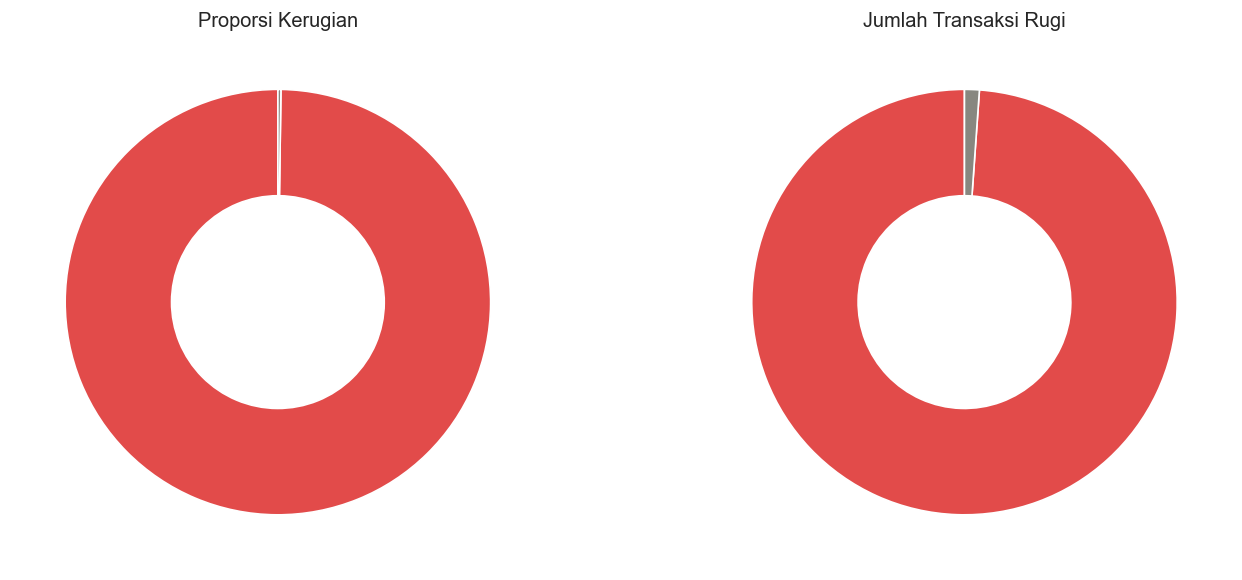

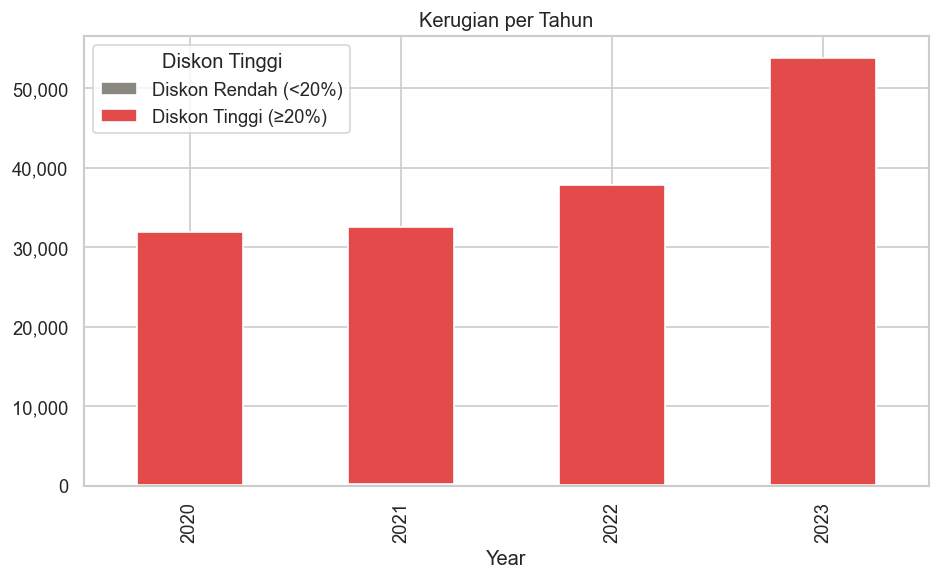

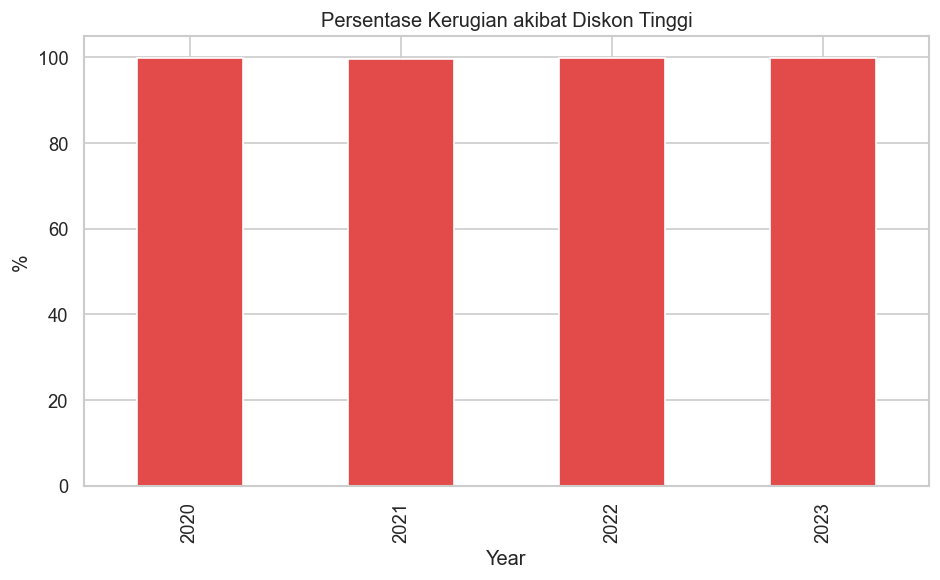


KESIMPULAN

Apakah diskon tinggi penyebab utama kerugian?

Jawaban: YA (diskon adalah penyebab utama)

99.8% kerugian berasal dari diskon tinggi ≥ 20%

Rekomendasi:
- Batasi diskon maksimal < 20%
- Gunakan approval untuk diskon besar
- Fokus ke produk yang profitable



In [490]:
# VALIDASI DATA
required_cols = ["Profit", "Discount", "Year"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Kolom {col} tidak ditemukan di dataset")

# PREPARATION
df["Status"] = df["Profit"].apply(lambda x: "Rugi" if x < 0 else "Untung")

THRESHOLD = 20  # diskon ≥ 20% dianggap tinggi

# handle skala discount (0–1 atau 0–100)
sample_discount = df["Discount"].dropna().iloc[0]
if sample_discount <= 1:
    df["Diskon Tinggi"] = df["Discount"] >= (THRESHOLD / 100)
else:
    df["Diskon Tinggi"] = df["Discount"] >= THRESHOLD

# warna
MERAH  = "#E24B4A"
HIJAU  = "#1D9E75"
KUNING = "#EF9F27"
ABU    = "#888780"

# TOTAL KERUGIAN
df_rugi = df[df["Status"] == "Rugi"]
rugi_diskon = df_rugi[df_rugi["Diskon Tinggi"] == True]
rugi_lain   = df_rugi[df_rugi["Diskon Tinggi"] == False]

total_profit         = df["Profit"].sum()
total_kerugian       = abs(df_rugi["Profit"].sum())
kerugian_diskon      = abs(rugi_diskon["Profit"].sum())
kerugian_faktor_lain = abs(rugi_lain["Profit"].sum())
total_keuntungan     = df[df["Status"] == "Untung"]["Profit"].sum()

pct_diskon = (kerugian_diskon / total_kerugian * 100) if total_kerugian > 0 else 0
pct_lain   = (kerugian_faktor_lain / total_kerugian * 100) if total_kerugian > 0 else 0

# PRINT SUMMARY
print("=" * 60)
print("TOTAL KERUGIAN & PENYEBAB")
print("=" * 60)

print(f"Total Profit Bersih      : {total_profit:,.0f}")
print(f"Total Keuntungan         : {total_keuntungan:,.0f}")
print(f"Total Kerugian           : {total_kerugian:,.0f}")

print(f"\nKerugian Diskon Tinggi   : {kerugian_diskon:,.0f} ({pct_diskon:.1f}%)")
print(f"Kerugian Faktor Lain     : {kerugian_faktor_lain:,.0f} ({pct_lain:.1f}%)")

# ESTIMASI PROFIT HILANG
df_tinggi = df[df["Diskon Tinggi"] == True].copy()

if sample_discount <= 1:
    df_tinggi["Profit Estimasi"] = df_tinggi.apply(
        lambda r: r["Profit"] / (1 - r["Discount"]) if r["Discount"] < 1 else r["Profit"],
        axis=1
    )
else:
    df_tinggi["Profit Estimasi"] = df_tinggi.apply(
        lambda r: r["Profit"] / (1 - r["Discount"]/100) if r["Discount"] < 100 else r["Profit"],
        axis=1
    )

profit_actual = df_tinggi["Profit"].sum()
profit_est    = df_tinggi["Profit Estimasi"].sum()
profit_lost   = profit_est - profit_actual

print("\nESTIMASI PROFIT HILANG")
print(f"Profit Aktual  : {profit_actual:,.0f}")
print(f"Profit Estimasi: {profit_est:,.0f}")
print(f"Profit Hilang  : {profit_lost:,.0f}")

# KERUGIAN PER TAHUN
kerugian_tahunan = df[df["Status"] == "Rugi"].groupby(
    ["Year", "Diskon Tinggi"]
)["Profit"].sum().abs().unstack(fill_value=0)

# Rename kolom boolean → jadi nama yang jelas
kerugian_tahunan = kerugian_tahunan.rename(columns={
    False: f"Diskon Rendah (<{THRESHOLD}%)",
    True: f"Diskon Tinggi (≥{THRESHOLD}%)"
})

# Pastikan kedua kolom ada (anti missing column)
col_rendah = f"Diskon Rendah (<{THRESHOLD}%)"
col_tinggi = f"Diskon Tinggi (≥{THRESHOLD}%)"

for col in [col_rendah, col_tinggi]:
    if col not in kerugian_tahunan.columns:
        kerugian_tahunan[col] = 0

# Ambil kolom dengan urutan yang benar
kerugian_tahunan = kerugian_tahunan[[col_rendah, col_tinggi]]

# Total kerugian
kerugian_tahunan["Total"] = kerugian_tahunan.sum(axis=1)

# Persentase kontribusi diskon tinggi
kerugian_tahunan["% Diskon Tinggi"] = (
    kerugian_tahunan[col_tinggi] /
    kerugian_tahunan["Total"]
).replace([np.inf, -np.inf], 0).fillna(0) * 100

# Optional: rounding biar rapi
kerugian_tahunan["% Diskon Tinggi"] = kerugian_tahunan["% Diskon Tinggi"].round(1)

# Display
print(kerugian_tahunan)

# VISUALISASI
# 1. DONUT CHART
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sizes = [kerugian_diskon, kerugian_faktor_lain]
if sum(sizes) == 0:
    sizes = [1,1]

ax[0].pie(sizes,
          colors=[MERAH, ABU],
          startangle=90,
          wedgeprops={"width":0.5})

ax[0].set_title("Proporsi Kerugian")

sizes2 = [len(rugi_diskon), len(rugi_lain)]
if sum(sizes2) == 0:
    sizes2 = [1,1]

ax[1].pie(sizes2,
          colors=[MERAH, ABU],
          startangle=90,
          wedgeprops={"width":0.5})

ax[1].set_title("Jumlah Transaksi Rugi")

plt.tight_layout()
plt.show()

# 2. STACKED BAR
fig, ax = plt.subplots(figsize=(8,5))

kerugian_tahunan[[f"Diskon Rendah (<{THRESHOLD}%)",
                  f"Diskon Tinggi (≥{THRESHOLD}%)"]].plot(
    kind="bar",
    stacked=True,
    color=[ABU, MERAH],
    ax=ax
)

ax.set_title("Kerugian per Tahun")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

# 3. % DISKON PER TAHUN
fig, ax = plt.subplots(figsize=(8,5))

warna = [MERAH if v > 50 else KUNING if v > 30 else HIJAU
         for v in kerugian_tahunan["% Diskon Tinggi"]]

kerugian_tahunan["% Diskon Tinggi"].plot(
    kind="bar",
    color=warna,
    ax=ax
)

ax.set_title("Persentase Kerugian akibat Diskon Tinggi")
ax.set_ylabel("%")

plt.tight_layout()
plt.show()

# FINAL INSIGHT
print("\n" + "="*60)
print("KESIMPULAN")
print("="*60)

if pct_diskon > 50:
    hasil = "YA (diskon adalah penyebab utama)"
else:
    hasil = "SEBAGIAN"

print(f"""
Apakah diskon tinggi penyebab utama kerugian?

Jawaban: {hasil}

{pct_diskon:.1f}% kerugian berasal dari diskon tinggi ≥ {THRESHOLD}%

Rekomendasi:
- Batasi diskon maksimal < {THRESHOLD}%
- Gunakan approval untuk diskon besar
- Fokus ke produk yang profitable
""")

### Analisis Deskriptif: Total Kerugian & Penyebab (2020–2023)

#### 1. Gambaran Umum Profit dan Kerugian
Berdasarkan hasil agregasi data:

- **Total Profit Bersih:** 286.397  
- **Total Keuntungan:** 442.528  
- **Total Kerugian:** 156.131  

Hal ini menunjukkan bahwa meskipun perusahaan masih menghasilkan profit secara keseluruhan, terdapat porsi kerugian yang cukup signifikan (≈35% dari total keuntungan).

---

#### 2. Penyebab Utama Kerugian
Analisis menunjukkan bahwa:

- **Kerugian akibat Diskon Tinggi:** 155.773 (**99,8%**)  
- **Kerugian dari faktor lain:** 358 (**0,2%**)  

Interpretasi:
- Hampir seluruh kerugian perusahaan disebabkan oleh **pemberian diskon tinggi**
- Faktor lain (operasional, harga dasar, dll) memiliki kontribusi yang sangat kecil

mengindikasikan bahwa **diskon adalah faktor dominan penyebab kerugian**

---

#### 3. Estimasi Profit Hilang
- **Profit aktual:** -45.039  
- **Profit estimasi (tanpa diskon tinggi):** 290.524  
- **Total profit hilang:** 245.485  

Interpretasi:
- Tanpa diskon tinggi, perusahaan seharusnya bisa menghasilkan profit positif yang besar
- Diskon menyebabkan hilangnya potensi profit secara signifikan

---

#### 4. Kerugian per Tahun
Kerugian akibat diskon tinggi per tahun:

- **2020:** 31.892  
- **2021:** 32.529  
- **2022:** 37.837  
- **2023:** 53.871  

Temuan:
- Kerugian meningkat dari tahun ke tahun
- Tahun **2023 merupakan yang paling tinggi**
- Tren ini menunjukkan bahwa dampak diskon semakin memburuk

---

#### 5. Persentase Kerugian akibat Diskon Tinggi
- **2020:** 99,8%  
- **2021:** 99,6%  
- **2022:** 99,9%  
- **2023:** 99,8%  

Interpretasi:
- Konsistensi hampir 100% menunjukkan bahwa:
  - Diskon tinggi **selalu menjadi penyebab utama kerugian**
  - Pola ini stabil di seluruh periode analisis

---

#### 6. Distribusi Kerugian
Dari visualisasi:

- Hampir seluruh bagian pie chart didominasi oleh **diskon tinggi**
- Distribusi menunjukkan bahwa:
  - Transaksi rugi hampir sepenuhnya berasal dari diskon tinggi
  - Diskon rendah hampir tidak berkontribusi terhadap kerugian

---


### **Problem Statement**

2. Analisis Produk Berdasarkan Diskon dan Profit
- Produk apa yang menghasilkan **Diskon** dan **Profit** tertinggi?
- Produk apa yang menghasilkan **Diskon** dan **Profit** terendah?


AGREGASI PER PRODUK

Tabel agregasi per produk:
                   Product  Rata_Diskon  Total_Profit  Total_Sales  Jumlah_Transaksi  Rata_Diskon_Pct
                   Alchemy     0.161765       55618.0  149528.0300                68             16.2
            Site Analytics     0.154556       44516.0  330007.0540               889             15.5
              Data Smasher     0.078452       41937.0  167380.3180               775              7.8
                   Support     0.075128       32864.0  125152.7440              1560              7.5
                FinanceHub     0.132518       32136.0  340935.4150               981             13.3
    Marketing Suite - Gold     0.074704       21279.0  223843.6080               846              7.5
                   OneView     0.166524       18138.0  107532.1610               466             16.7
       SaaS Connector Pack     0.138349       13059.0   91705.1640               957             13.8
            ContactMatcher     0.

C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\736047151.py:217: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\736047151.py:217: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\736047151.py:218: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig("analisis_produk.png", bbox_inches='tight', dpi=150)
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\736047151.py:218: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig("analisis_produk.png", bbox_inches='tight', dpi=150)
c:\Users\ARTUR\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ARTUR\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

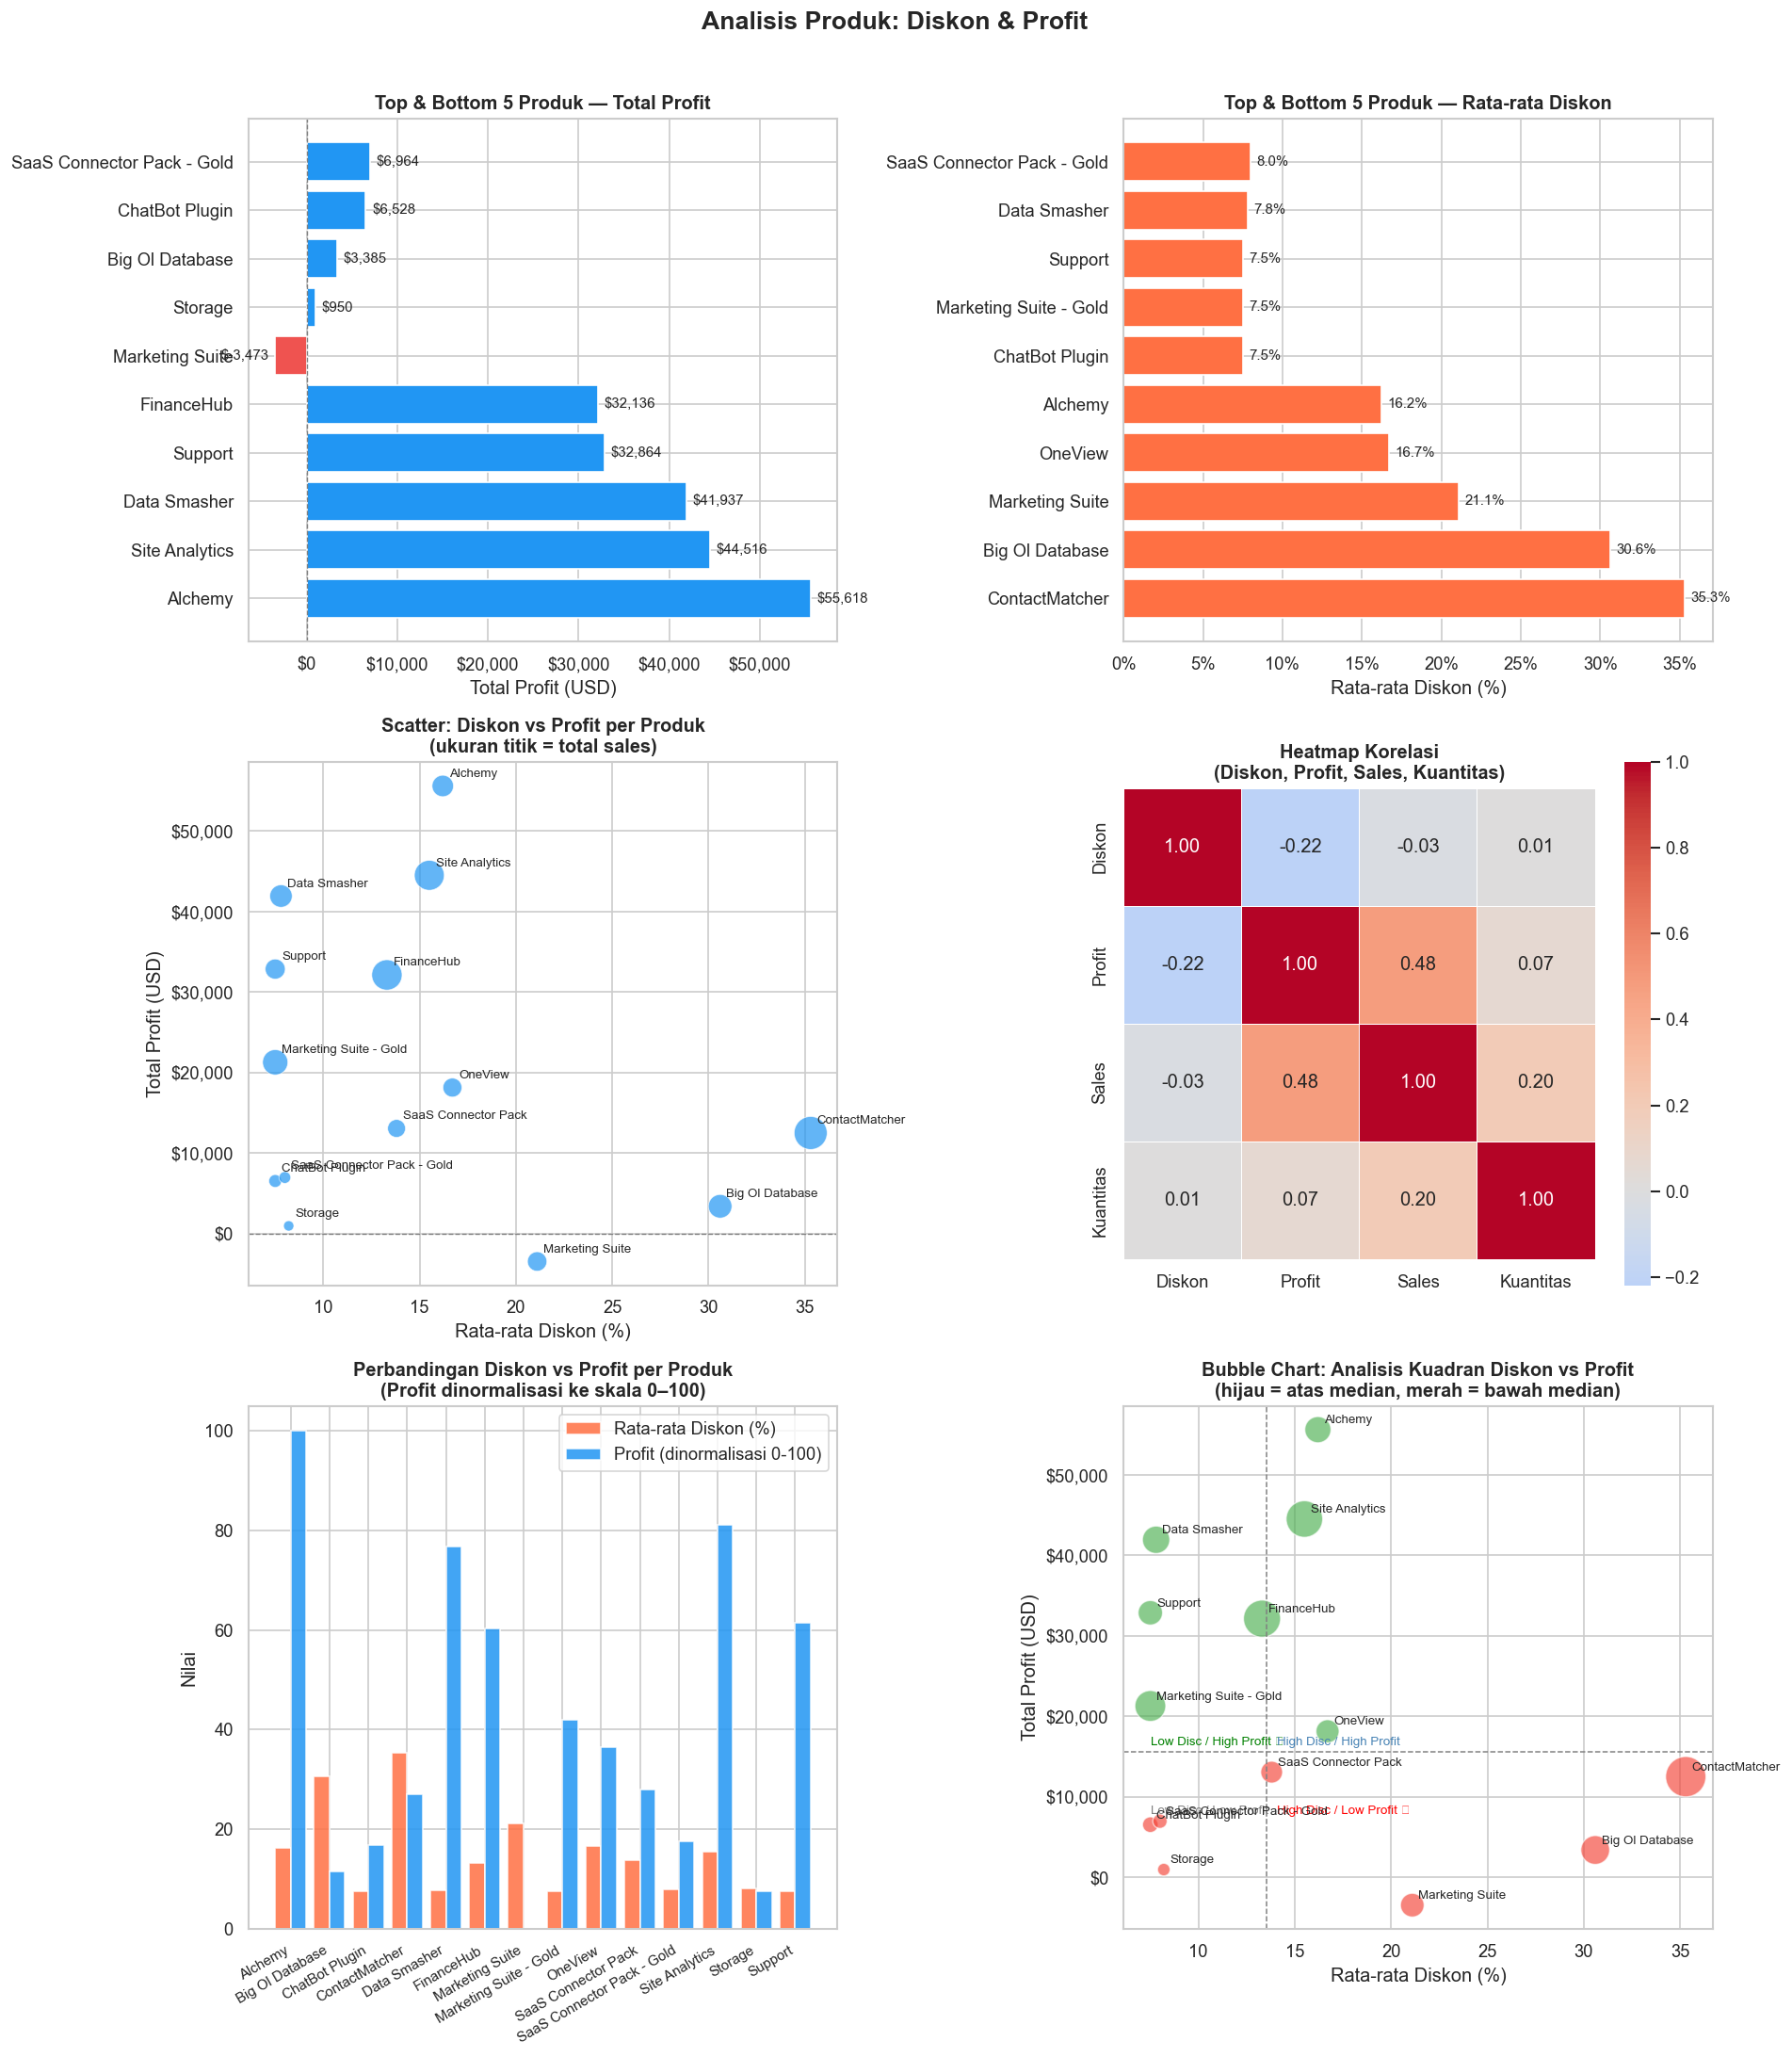


Grafik disimpan sebagai: analisis_produk.png

ANALISIS KUADRAN

Klasifikasi produk per kuadran:
                   Product  Rata_Diskon_Pct  Total_Profit                              Kuadran
                   Alchemy             16.2       55618.0              High Disc / High Profit
                   OneView             16.7       18138.0              High Disc / High Profit
            Site Analytics             15.5       44516.0              High Disc / High Profit
           Big Ol Database             30.6        3385.0 High Disc / Low Profit  ← Bermasalah
            ContactMatcher             35.3       12496.0 High Disc / Low Profit  ← Bermasalah
           Marketing Suite             21.1       -3473.0 High Disc / Low Profit  ← Bermasalah
       SaaS Connector Pack             13.8       13059.0 High Disc / Low Profit  ← Bermasalah
              Data Smasher              7.8       41937.0      Low Disc / High Profit  ← Ideal
                FinanceHub             13.3     

In [491]:
# ANALISIS PRODUK BERDASARKAN DISKON & PROFIT
# SaaS Sales Dataset

# Pengaturan tampilan grafik
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

# AGREGASI PER PRODUK

print("\n" + "=" * 50)
print("AGREGASI PER PRODUK")
print("=" * 50)

# Kelompokkan data per produk, hitung rata-rata diskon & total profit
produk = df.groupby('Product').agg(
    Rata_Diskon   = ('Discount', 'mean'),   # rata-rata diskon (0.0 - 1.0)
    Total_Profit  = ('Profit',   'sum'),    # total profit semua transaksi
    Total_Sales   = ('Sales',    'sum'),    # total penjualan
    Jumlah_Transaksi = ('Sales', 'count')  # berapa kali terjual
).reset_index()

# Ubah diskon ke persen biar lebih mudah dibaca
produk['Rata_Diskon_Pct'] = (produk['Rata_Diskon'] * 100).round(1)
produk['Total_Profit']    = produk['Total_Profit'].round(0)

print("\nTabel agregasi per produk:")
print(produk.sort_values('Total_Profit', ascending=False).to_string(index=False))

# IDENTIFIKASI TERTINGGI & TERENDAH

print("\n" + "=" * 50)
print("IDENTIFIKASI TERTINGGI & TERENDAH")
print("=" * 50)

N = 5  # ambil top-5 dan bottom-5

# --- Profit ---
top_profit    = produk.nlargest(N, 'Total_Profit')[['Product', 'Total_Profit']]
bottom_profit = produk.nsmallest(N, 'Total_Profit')[['Product', 'Total_Profit']]

print(f"\nTop {N} Profit Tertinggi:")
print(top_profit.to_string(index=False))

print(f"\nTop {N} Profit Terendah:")
print(bottom_profit.to_string(index=False))

# --- Diskon ---
top_diskon    = produk.nlargest(N, 'Rata_Diskon_Pct')[['Product', 'Rata_Diskon_Pct']]
bottom_diskon = produk.nsmallest(N, 'Rata_Diskon_Pct')[['Product', 'Rata_Diskon_Pct']]

print(f"\nTop {N} Diskon Tertinggi (%):")
print(top_diskon.to_string(index=False))

print(f"\nTop {N} Diskon Terendah (%):")
print(bottom_diskon.to_string(index=False))

# VISUALISASI


fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Analisis Produk: Diskon & Profit", fontsize=16, fontweight='bold', y=1.01)

WARNA_PROFIT  = "#2196F3"  # biru  → profit
WARNA_DISKON  = "#FF7043"  # oranye → diskon
WARNA_NEG     = "#EF5350"  # merah  → profit negatif


# ------ Bar Chart — Top & Bottom Profit ------
ax1 = axes[0, 0]

# Gabungkan top & bottom, beri label
top_profit_plot    = top_profit.copy();    top_profit_plot['label']    = 'Tertinggi'
bottom_profit_plot = bottom_profit.copy(); bottom_profit_plot['label'] = 'Terendah'
combo_profit = pd.concat([top_profit_plot, bottom_profit_plot])

warna_bar = [WARNA_PROFIT if x >= 0 else WARNA_NEG for x in combo_profit['Total_Profit']]
bars = ax1.barh(combo_profit['Product'], combo_profit['Total_Profit'], color=warna_bar)
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title("Top & Bottom 5 Produk — Total Profit", fontweight='bold')
ax1.set_xlabel("Total Profit (USD)")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=9)


# ------ Bar Chart — Top & Bottom Diskon ------
ax2 = axes[0, 1]

top_diskon_plot    = top_diskon.copy();    top_diskon_plot['label']    = 'Tertinggi'
bottom_diskon_plot = bottom_diskon.copy(); bottom_diskon_plot['label'] = 'Terendah'
combo_diskon = pd.concat([top_diskon_plot, bottom_diskon_plot])

bars2 = ax2.barh(combo_diskon['Product'], combo_diskon['Rata_Diskon_Pct'], color=WARNA_DISKON)
ax2.set_title("Top & Bottom 5 Produk — Rata-rata Diskon", fontweight='bold')
ax2.set_xlabel("Rata-rata Diskon (%)")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)


# ------ Scatter Plot — Diskon vs Profit ------
ax3 = axes[1, 0]

scatter = ax3.scatter(
    produk['Rata_Diskon_Pct'],
    produk['Total_Profit'],
    s=produk['Total_Sales'] / produk['Total_Sales'].max() * 400 + 40,  # ukuran = sales
    alpha=0.7,
    color=WARNA_PROFIT,
    edgecolors='white',
    linewidth=0.5
)

# Tambahkan label nama produk
for _, row in produk.iterrows():
    ax3.annotate(
        row['Product'],
        (row['Rata_Diskon_Pct'], row['Total_Profit']),
        fontsize=8, ha='left', va='bottom',
        xytext=(4, 4), textcoords='offset points'
    )

ax3.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.set_title("Scatter: Diskon vs Profit per Produk\n(ukuran titik = total sales)", fontweight='bold')
ax3.set_xlabel("Rata-rata Diskon (%)")
ax3.set_ylabel("Total Profit (USD)")
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))


# ------ Heatmap Korelasi ------
ax4 = axes[1, 1]

# Hitung korelasi antar variabel numerik penting
kolom_korelasi = df[['Discount', 'Profit', 'Sales', 'Quantity']].copy()
kolom_korelasi.columns = ['Diskon', 'Profit', 'Sales', 'Kuantitas']
matriks_korelasi = kolom_korelasi.corr()

sns.heatmap(
    matriks_korelasi,
    annot=True,          # tampilkan angka
    fmt=".2f",           # 2 desimal
    cmap="coolwarm",     # merah = korelasi positif, biru = negatif
    center=0,
    ax=ax4,
    square=True,
    linewidths=0.5
)
ax4.set_title("Heatmap Korelasi\n(Diskon, Profit, Sales, Kuantitas)", fontweight='bold')


# ------ Grouped Bar — Diskon & Profit per Produk ------
ax5 = axes[2, 0]

# Normalisasi profit ke skala 0-100 agar bisa dibandingkan dengan diskon
profit_norm = (produk['Total_Profit'] - produk['Total_Profit'].min()) / \
              (produk['Total_Profit'].max() - produk['Total_Profit'].min()) * 100

x = range(len(produk))
lebar = 0.4

bar_a = ax5.bar([i - lebar/2 for i in x], produk['Rata_Diskon_Pct'], lebar,
                label='Rata-rata Diskon (%)', color=WARNA_DISKON, alpha=0.85)
bar_b = ax5.bar([i + lebar/2 for i in x], profit_norm, lebar,
                label='Profit (dinormalisasi 0-100)', color=WARNA_PROFIT, alpha=0.85)

ax5.set_xticks(list(x))
ax5.set_xticklabels(produk['Product'], rotation=30, ha='right', fontsize=9)
ax5.set_title("Perbandingan Diskon vs Profit per Produk\n(Profit dinormalisasi ke skala 0–100)", fontweight='bold')
ax5.set_ylabel("Nilai")
ax5.legend()


# ------ Bubble Chart ------
ax6 = axes[2, 1]

# Kuadran: garis tengah di median
med_diskon = produk['Rata_Diskon_Pct'].median()
med_profit = produk['Total_Profit'].median()

warna_bubble = ['#4CAF50' if p >= med_profit else '#F44336'
                for p in produk['Total_Profit']]

ax6.scatter(
    produk['Rata_Diskon_Pct'],
    produk['Total_Profit'],
    s=produk['Total_Sales'] / produk['Total_Sales'].max() * 600 + 60,
    c=warna_bubble,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.8
)

# Garis kuadran
ax6.axvline(med_diskon, color='gray', linestyle='--', linewidth=0.9)
ax6.axhline(med_profit, color='gray', linestyle='--', linewidth=0.9)

# Label kuadran
ax6.text(produk['Rata_Diskon_Pct'].min(), med_profit * 1.05,
         "Low Disc / High Profit ✓", fontsize=8, color='green')
ax6.text(med_diskon + 0.5, med_profit * 1.05,
         "High Disc / High Profit", fontsize=8, color='steelblue')
ax6.text(produk['Rata_Diskon_Pct'].min(), med_profit * 0.5,
         "Low Disc / Low Profit", fontsize=8, color='gray')
ax6.text(med_diskon + 0.5, med_profit * 0.5,
         "High Disc / Low Profit ✗", fontsize=8, color='red')

# Label produk
for _, row in produk.iterrows():
    ax6.annotate(row['Product'], (row['Rata_Diskon_Pct'], row['Total_Profit']),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')

ax6.set_title("Bubble Chart: Analisis Kuadran Diskon vs Profit\n(hijau = atas median, merah = bawah median)", fontweight='bold')
ax6.set_xlabel("Rata-rata Diskon (%)")
ax6.set_ylabel("Total Profit (USD)")
ax6.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))


plt.tight_layout()
plt.savefig("analisis_produk.png", bbox_inches='tight', dpi=150)
plt.show()
print("\nGrafik disimpan sebagai: analisis_produk.png")

# ANALISIS KUADRAN (TABEL)

print("\n" + "=" * 50)
print("ANALISIS KUADRAN")
print("=" * 50)

def kategorikan_kuadran(row):
    tinggi_diskon = row['Rata_Diskon_Pct'] >= med_diskon
    tinggi_profit = row['Total_Profit']    >= med_profit
    if tinggi_diskon and tinggi_profit:
        return "High Disc / High Profit"
    elif tinggi_diskon and not tinggi_profit:
        return "High Disc / Low Profit  ← Bermasalah"
    elif not tinggi_diskon and tinggi_profit:
        return "Low Disc / High Profit  ← Ideal"
    else:
        return "Low Disc / Low Profit"

produk['Kuadran'] = produk.apply(kategorikan_kuadran, axis=1)

print("\nKlasifikasi produk per kuadran:")
print(produk[['Product', 'Rata_Diskon_Pct', 'Total_Profit', 'Kuadran']]
      .sort_values('Kuadran').to_string(index=False))

# RINGKASAN INSIGHT

print("\n" + "=" * 50)
print("RINGKASAN INSIGHT")
print("=" * 50)

best_profit  = produk.loc[produk['Total_Profit'].idxmax()]
worst_profit = produk.loc[produk['Total_Profit'].idxmin()]
most_disc    = produk.loc[produk['Rata_Diskon_Pct'].idxmax()]
least_disc   = produk.loc[produk['Rata_Diskon_Pct'].idxmin()]

print(f"\n Profit tertinggi  : {best_profit['Product']}  (${best_profit['Total_Profit']:,.0f})")
print(f" Profit terendah   : {worst_profit['Product']} (${worst_profit['Total_Profit']:,.0f})")
print(f" Diskon tertinggi  : {most_disc['Product']}  ({most_disc['Rata_Diskon_Pct']:.1f}%)")
print(f" Diskon terendah   : {least_disc['Product']} ({least_disc['Rata_Diskon_Pct']:.1f}%)")

bermasalah = produk[produk['Kuadran'].str.contains("Bermasalah")]
if not bermasalah.empty:
    print(f"\n Produk dengan diskon tinggi tapi profit rendah (perlu dievaluasi):")
    for _, r in bermasalah.iterrows():
        print(f"   - {r['Product']}  (diskon {r['Rata_Diskon_Pct']:.1f}%, profit ${r['Total_Profit']:,.0f})")

### Kinerja Produk dan Pengaruh Diskon terhadap Profit

#### 1. Gambaran Umum Kinerja Produk
Berdasarkan agregasi data per produk, terlihat variasi yang signifikan dalam hal diskon, profit, dan jumlah transaksi.

##### Produk dengan Profit Tertinggi
- **Alchemy:** 55,618
- **Site Analytics:** 44,516
- **Data Smasher:** 41,937
- **Support:** 32,864

Karakteristik:
- Diskon relatif **rendah hingga moderat (7–16%)**
- Profit tinggi dan stabil
- Volume transaksi cukup besar

##### Produk dengan Profit Rendah / Negatif
- **Marketing Suite:** -3,473 (rugi)
- **Storage:** 950
- **Big Ol Database:** 3,385

Karakteristik:
- Diskon relatif **tinggi (≥20%)**
- Profit rendah atau negatif
- Efisiensi penjualan rendah

---

#### 2. Hubungan Diskon dan Profit
Dari scatter plot dan heatmap korelasi:

- Korelasi Diskon vs Profit: **-0.22 (negatif)**
- Artinya:
  - Semakin tinggi diskon → profit cenderung menurun
  - Hubungan tidak terlalu kuat, tetapi konsisten

Selain itu:
- Korelasi Sales vs Profit: **0.48 (positif sedang)**
- Artinya:
  - Penjualan tinggi tetap berkontribusi pada profit

Namun diskon tinggi dapat **mengurangi manfaat dari peningkatan sales**

---

#### 3. Analisis Kuadran Produk

Produk diklasifikasikan berdasarkan:
- Diskon (tinggi vs rendah)
- Profit (tinggi vs rendah)

##### Kuadran Ideal (Low Discount / High Profit)
- Data Smasher
- FinanceHub
- Marketing Suite - Gold
- Support

Karakteristik:
- Diskon rendah
- Profit tinggi
- Model bisnis efisien

Ini adalah **produk terbaik** dan perlu dipertahankan

##### High Discount / High Profit
- Alchemy
- OneView
- Site Analytics

Karakteristik:
- Diskon cukup tinggi
- Profit tetap tinggi

Produk masih perform, tapi:
- Perlu evaluasi apakah diskon bisa dikurangi untuk meningkatkan margin

##### Kuadran Bermasalah (High Discount / Low Profit)
- Big Ol Database
- ContactMatcher
- Marketing Suite
- SaaS Connector Pack

Karakteristik:
- Diskon tinggi
- Profit rendah / negatif

Ini adalah **sumber utama kerugian**

##### Low Discount / Low Profit
- ChatBot Plugin
- SaaS Connector Pack - Gold
- Storage

Karakteristik:
- Diskon rendah
- Profit rendah

Produk kurang optimal, perlu strategi peningkatan value

---

#### 4. Insight Strategis

##### Pola Utama
- Diskon tinggi tidak menjamin profit tinggi
- Produk terbaik justru memiliki **diskon rendah + profit tinggi**
- Produk bermasalah didominasi oleh:
  - Diskon tinggi
  - Profit rendah

##### Produk Berisiko Tinggi
- **ContactMatcher (35.3% diskon)**
- **Big Ol Database (30.6%)**
- **Marketing Suite (21.1%)**

Diskon besar tidak mampu meningkatkan profit secara signifikan

##### roduk Paling Efisien
- **Data Smasher**
- **Support**
- **FinanceHub**

Kombinasi optimal:
- Diskon rendah
- Profit tinggi

---


In [492]:
# IDENTIFIKASI PRODUK TERTINGGI & TERENDAH
# Diskon dan Profit

# BERDASARKAN PROFIT

print("=" * 45)
print("PROFIT TERTINGGI — Top 5 Produk")
print("=" * 45)

top5_profit = (
    produk
    .sort_values('Total_Profit', ascending=False)  # urutkan dari besar ke kecil
    .head(5)                                        # ambil 5 teratas
    [['Product', 'Total_Profit']]                  # kolom yang ditampilkan
)
print(top5_profit.to_string(index=False))


print("\n" + "=" * 45)
print("PROFIT TERENDAH — Bottom 5 Produk")
print("=" * 45)

bottom5_profit = (
    produk
    .sort_values('Total_Profit', ascending=True)   # urutkan dari kecil ke besar
    .head(5)
    [['Product', 'Total_Profit']]
)
print(bottom5_profit.to_string(index=False))

# BERDASARKAN DISKON

print("\n" + "=" * 45)
print("DISKON TERTINGGI — Top 5 Produk")
print("=" * 45)

top5_diskon = (
    produk
    .sort_values('Rata_Diskon_Pct', ascending=False)
    .head(5)
    [['Product', 'Rata_Diskon_Pct']]
)
print(top5_diskon.to_string(index=False))


print("\n" + "=" * 45)
print("DISKON TERENDAH — Bottom 5 Produk")
print("=" * 45)

bottom5_diskon = (
    produk
    .sort_values('Rata_Diskon_Pct', ascending=True)
    .head(5)
    [['Product', 'Rata_Diskon_Pct']]
)
print(bottom5_diskon.to_string(index=False))

# JAWABAN LANGSUNG PROBLEM STATEMENT

print("\n" + "=" * 45)
print("RINGKASAN JAWABAN")
print("=" * 45)

p_max = produk.loc[produk['Total_Profit'].idxmax()]
p_min = produk.loc[produk['Total_Profit'].idxmin()]
d_max = produk.loc[produk['Rata_Diskon_Pct'].idxmax()]
d_min = produk.loc[produk['Rata_Diskon_Pct'].idxmin()]

print(f"\nProduk PROFIT tertinggi  : {p_max['Product']}  → ${p_max['Total_Profit']:,.0f}")
print(f"Produk PROFIT terendah   : {p_min['Product']}  → ${p_min['Total_Profit']:,.0f}")
print(f"Produk DISKON tertinggi  : {d_max['Product']}  → {d_max['Rata_Diskon_Pct']}%")
print(f"Produk DISKON terendah   : {d_min['Product']}  → {d_min['Rata_Diskon_Pct']}%")

PROFIT TERTINGGI — Top 5 Produk
       Product  Total_Profit
       Alchemy       55618.0
Site Analytics       44516.0
  Data Smasher       41937.0
       Support       32864.0
    FinanceHub       32136.0

PROFIT TERENDAH — Bottom 5 Produk
                   Product  Total_Profit
           Marketing Suite       -3473.0
                   Storage         950.0
           Big Ol Database        3385.0
            ChatBot Plugin        6528.0
SaaS Connector Pack - Gold        6964.0

DISKON TERTINGGI — Top 5 Produk
        Product  Rata_Diskon_Pct
 ContactMatcher             35.3
Big Ol Database             30.6
Marketing Suite             21.1
        OneView             16.7
        Alchemy             16.2

DISKON TERENDAH — Bottom 5 Produk
                   Product  Rata_Diskon_Pct
            ChatBot Plugin              7.5
    Marketing Suite - Gold              7.5
                   Support              7.5
              Data Smasher              7.8
SaaS Connector Pack - Gold 

# Produk dengan Profit dan Diskon Tertinggi & Terendah

#### 1. Produk dengan Profit Tertinggi
Top 5 produk dengan profit tertinggi:

- **Alchemy:** 55,618  
- **Site Analytics:** 44,516  
- **Data Smasher:** 41,937  
- **Support:** 32,864  
- **FinanceHub:** 32,136  

##### Insight:
- Produk-produk ini merupakan **kontributor utama profit perusahaan**
- Umumnya memiliki:
  - Diskon relatif rendah hingga moderat
  - Permintaan tinggi (jumlah transaksi besar)
- **Alchemy** menjadi produk dengan performa terbaik secara keseluruhan

---

#### 2. Produk dengan Profit Terendah
Bottom 5 produk dengan profit terendah:

- **Marketing Suite:** -3,473 (rugi)  
- **Storage:** 950  
- **Big Ol Database:** 3,385  
- **ChatBot Plugin:** 6,528  
- **SaaS Connector Pack - Gold:** 6,964  

##### Insight:
- **Marketing Suite** merupakan satu-satunya produk dengan profit negatif
- Produk lainnya memiliki profit rendah, menunjukkan:
  - Performa penjualan kurang optimal
  - Margin keuntungan kecil
- Beberapa produk kemungkinan terdampak oleh **diskon yang tidak efisien**

--

#### 3. Produk dengan Diskon Tertinggi
- **ContactMatcher:** 35.3%  

##### Insight:
- Produk ini memiliki tingkat diskon paling tinggi
- Namun tidak termasuk dalam kategori profit tertinggi
- Hal ini menunjukkan bahwa:
  - Diskon tinggi tidak selalu meningkatkan profit
  - Bahkan berpotensi menurunkan margin keuntungan

---

#### 4. Produk dengan Diskon Terendah
- **ChatBot Plugin:** 7.5%  

##### Insight:
- Diskon rendah membantu menjaga margin profit
- Namun profit tetap relatif kecil
- Artinya:
  - Diskon bukan satu-satunya faktor penentu profit
  - Faktor lain seperti volume penjualan dan harga dasar juga berpengaruh

---


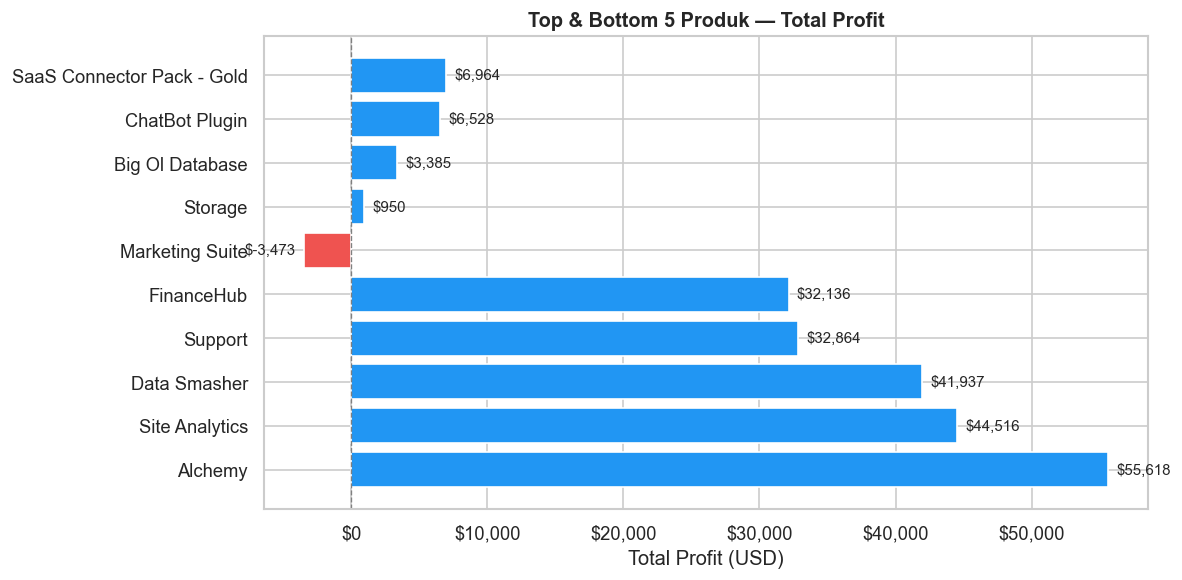

profit.png


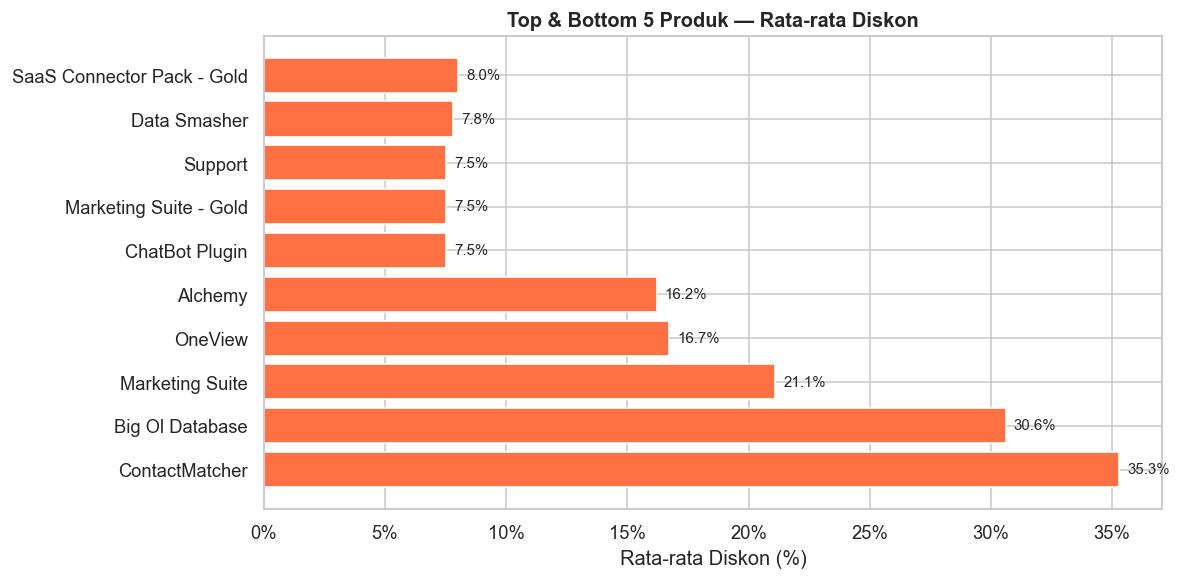

diskon.png


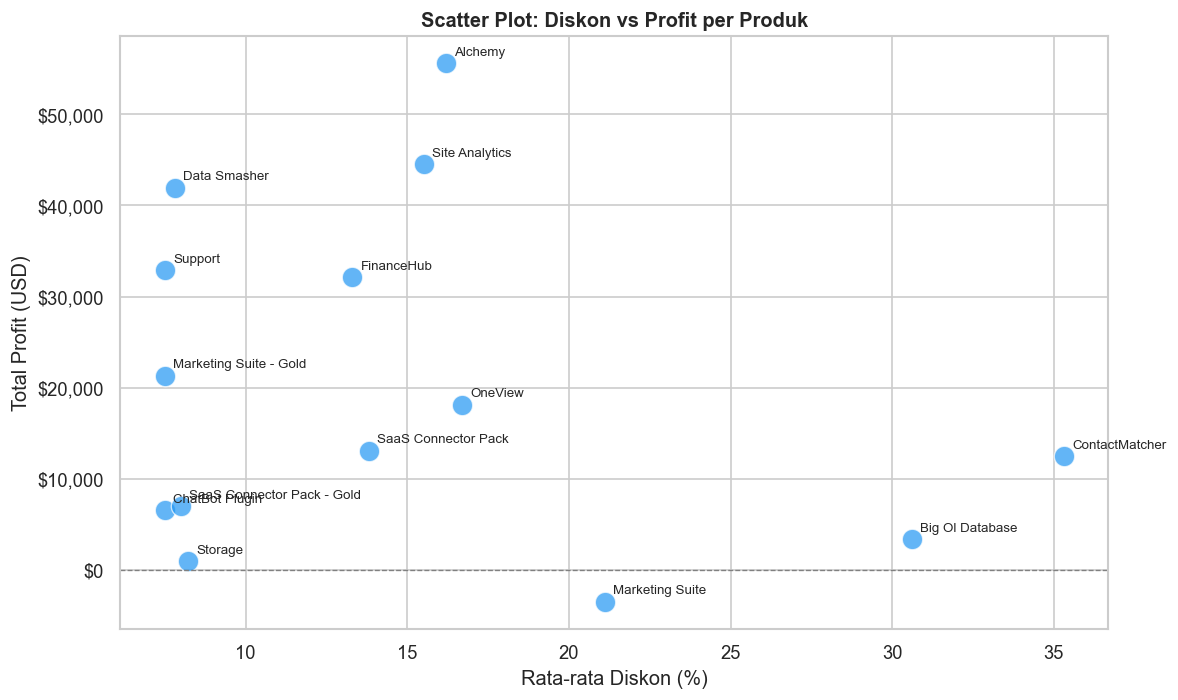

scatter.png


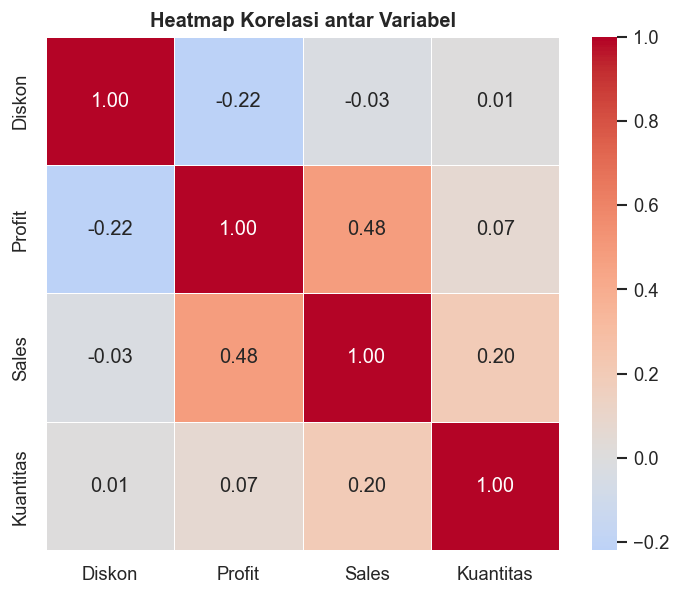

heatmap.png


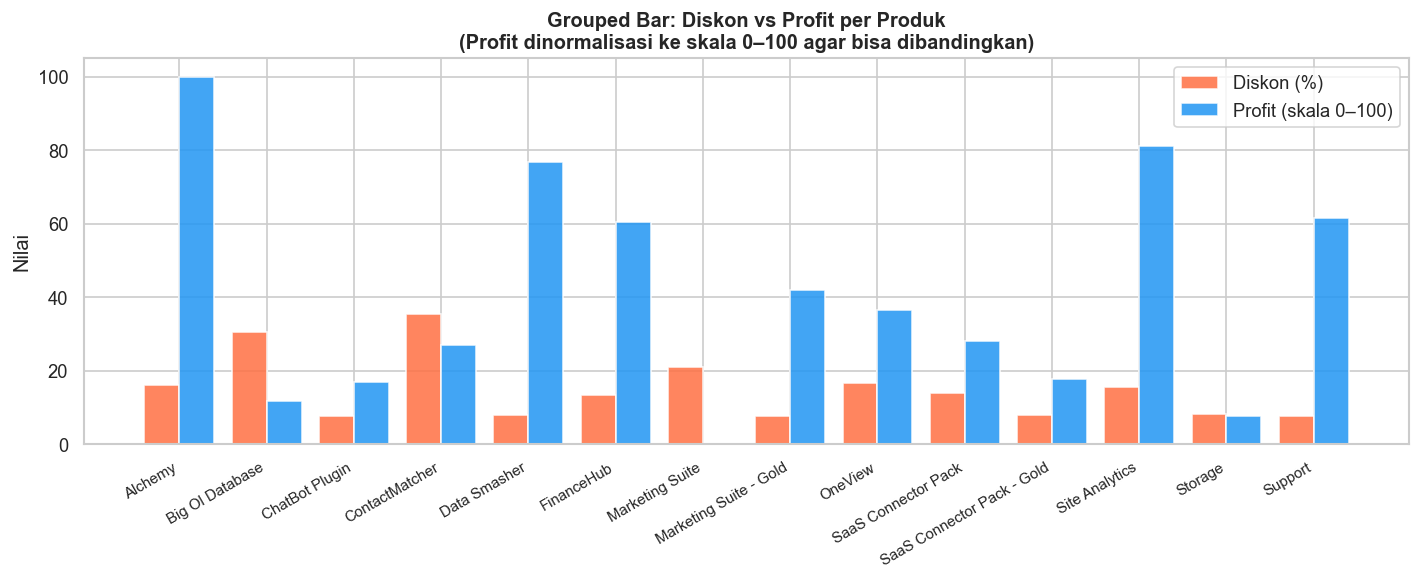

grouped_bar.png


C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1401837723.py:193: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ARTUR\AppDat

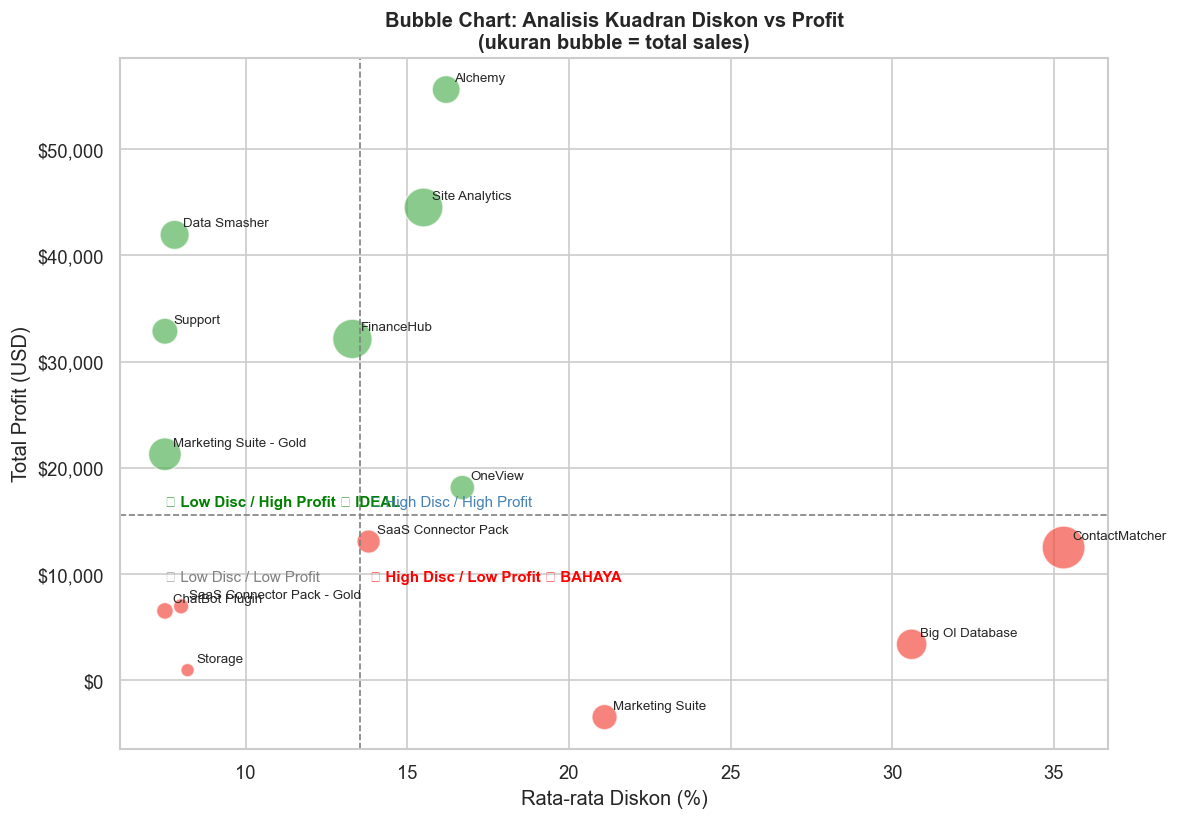

bubble.png

 Semua chart selesai dibuat!


In [493]:
# VISUALISASI 
# Analisis Produk: Diskon & Profit

produk = df.groupby('Product').agg(
    Diskon_Pct   = ('Discount', 'mean'),
    Total_Profit = ('Profit',   'sum'),
    Total_Sales  = ('Sales',    'sum'),
).reset_index()

produk['Diskon_Pct'] = (produk['Diskon_Pct'] * 100).round(1)

N = 5  # jumlah produk yang ditampilkan di top/bottom

# Bar Chart Horizontal: TOP & BOTTOM PROFIT
# Tujuan: lihat produk paling untung dan paling rugi

top_profit    = produk.nlargest(N, 'Total_Profit')
bottom_profit = produk.nsmallest(N, 'Total_Profit')
data_c1       = pd.concat([top_profit, bottom_profit])

# Warna: biru kalau profit positif, merah kalau negatif
warna = ['#2196F3' if p >= 0 else '#EF5350' for p in data_c1['Total_Profit']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(data_c1['Product'], data_c1['Total_Profit'], color=warna)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')  # garis nol
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=9)
ax.set_title(f"Top & Bottom {N} Produk — Total Profit", fontweight='bold')
ax.set_xlabel("Total Profit (USD)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("profit.png", dpi=150)
plt.show()
print("profit.png")

# Bar Chart Horizontal: TOP & BOTTOM DISKON
# Tujuan: lihat produk yang paling sering/jarang diberi diskon

top_diskon    = produk.nlargest(N, 'Diskon_Pct')
bottom_diskon = produk.nsmallest(N, 'Diskon_Pct')
data_c2       = pd.concat([top_diskon, bottom_diskon])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(data_c2['Product'], data_c2['Diskon_Pct'], color='#FF7043')
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=9)
ax.set_title(f"Top & Bottom {N} Produk — Rata-rata Diskon", fontweight='bold')
ax.set_xlabel("Rata-rata Diskon (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig("diskon.png", dpi=150)
plt.show()
print("diskon.png")

# Scatter Plot: DISKON vs PROFIT
# Tujuan: apakah produk dengan diskon tinggi cenderung profit rendah?

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    produk['Diskon_Pct'],
    produk['Total_Profit'],
    s=150, color='#2196F3', alpha=0.7,
    edgecolors='white', linewidth=0.8
)

# Tambahkan nama produk di setiap titik
for _, row in produk.iterrows():
    ax.annotate(
        row['Product'],
        xy=(row['Diskon_Pct'], row['Total_Profit']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8
    )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # garis profit = 0
ax.set_title("Scatter Plot: Diskon vs Profit per Produk", fontweight='bold')
ax.set_xlabel("Rata-rata Diskon (%)")
ax.set_ylabel("Total Profit (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("scatter.png", dpi=150)
plt.show()
print("scatter.png")

# Heatmap Korelasi
# Tujuan: lihat seberapa kuat hubungan antar variabel
# Nilai mendekati 1 = hubungan kuat positif
# Nilai mendekati -1 = hubungan kuat negatif

kolom = df[['Discount', 'Profit', 'Sales', 'Quantity']].copy()
kolom.columns = ['Diskon', 'Profit', 'Sales', 'Kuantitas']
matriks = kolom.corr()  # hitung korelasi antar kolom

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    matriks,
    annot=True,       # tampilkan angka korelasi
    fmt=".2f",        # 2 angka desimal
    cmap="coolwarm",  # merah = positif, biru = negatif
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Heatmap Korelasi antar Variabel", fontweight='bold')
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()
print("heatmap.png")

# Grouped Bar Chart: DISKON vs PROFIT per Produk
# Tujuan: bandingkan diskon dan profit setiap produk berdampingan
# Catatan: profit dinormalisasi ke skala 0-100 agar sebanding

# Normalisasi profit ke skala 0-100
profit_min = produk['Total_Profit'].min()
profit_max = produk['Total_Profit'].max()
produk['Profit_Norm'] = (
    (produk['Total_Profit'] - profit_min) / (profit_max - profit_min) * 100
).round(1)

x     = range(len(produk))
lebar = 0.4  # lebar setiap bar

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - lebar/2 for i in x], produk['Diskon_Pct'],   lebar,
       label='Diskon (%)',              color='#FF7043', alpha=0.85)
ax.bar([i + lebar/2 for i in x], produk['Profit_Norm'],  lebar,
       label='Profit (skala 0–100)',    color='#2196F3', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(produk['Product'], rotation=30, ha='right', fontsize=9)
ax.set_title("Grouped Bar: Diskon vs Profit per Produk\n(Profit dinormalisasi ke skala 0–100 agar bisa dibandingkan)",
             fontweight='bold')
ax.set_ylabel("Nilai")
ax.legend()
plt.tight_layout()
plt.savefig("grouped_bar.png", dpi=150)
plt.show()
print("grouped_bar.png")

# Bubble Chart: KUADRAN Diskon vs Profit
# Tujuan: klasifikasikan posisi setiap produk ke 4 kuadran
# Ukuran bubble = total sales (produk dengan penjualan besar = bubble besar)

med_diskon = produk['Diskon_Pct'].median()    # nilai tengah diskon
med_profit = produk['Total_Profit'].median()  # nilai tengah profit

# Warna: hijau = profit di atas median, merah = di bawah median
warna_bubble = [
    '#4CAF50' if p >= med_profit else '#F44336'
    for p in produk['Total_Profit']
]

# Ukuran bubble proporsional dengan total sales
ukuran_bubble = produk['Total_Sales'] / produk['Total_Sales'].max() * 600 + 60

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    produk['Diskon_Pct'],
    produk['Total_Profit'],
    s=ukuran_bubble,
    c=warna_bubble,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.8
)

# Garis pembatas kuadran (di nilai median)
ax.axvline(med_diskon, color='gray', linestyle='--', linewidth=1)
ax.axhline(med_profit, color='gray', linestyle='--', linewidth=1)

# Label nama produk
for _, row in produk.iterrows():
    ax.annotate(row['Product'],
                xy=(row['Diskon_Pct'], row['Total_Profit']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Label 4 kuadran
ax.text(produk['Diskon_Pct'].min(), med_profit * 1.05,
        "② Low Disc / High Profit ✓ IDEAL", fontsize=9, color='green', fontweight='bold')
ax.text(med_diskon + 0.3, med_profit * 1.05,
        "① High Disc / High Profit", fontsize=9, color='steelblue')
ax.text(produk['Diskon_Pct'].min(), med_profit * 0.6,
        "③ Low Disc / Low Profit", fontsize=9, color='gray')
ax.text(med_diskon + 0.3, med_profit * 0.6,
        "④ High Disc / Low Profit ✗ BAHAYA", fontsize=9, color='red', fontweight='bold')

ax.set_title("Bubble Chart: Analisis Kuadran Diskon vs Profit\n(ukuran bubble = total sales)",
             fontweight='bold')
ax.set_xlabel("Rata-rata Diskon (%)")
ax.set_ylabel("Total Profit (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("bubble.png", dpi=150)
plt.show()
print("bubble.png")

print("\n Semua chart selesai dibuat!")

### Analisis Deskriptif: Diskon vs Profit per Produk

#### 1. Top & Bottom Produk berdasarkan Profit

#### Produk dengan Profit Tertinggi
- **Alchemy:** ~$55,618 (tertinggi)
- **Site Analytics:** ~$44,516
- **Data Smasher:** ~$41,937
- **Support:** ~$32,864
- **FinanceHub:** ~$32,136

##### Insight:
- Produk dengan profit tinggi cenderung memiliki **diskon rendah–menengah (±7%–16%)**
- Produk ini adalah **core driver revenue & profit perusahaan**
- Tidak bergantung pada diskon tinggi untuk menghasilkan keuntungan

##### Produk dengan Profit Terendah
- **Marketing Suite:** ~$-3,473 (rugi)
- **Storage:** ~$950
- **Big Ol Database:** ~$3,385
- **ChatBot Plugin:** ~$6,528
- **SaaS Connector Pack - Gold:** ~$6,964

##### Insight:
- **Marketing Suite mengalami kerugian**, meskipun diskonnya cukup tinggi (~21%)
- Produk dengan profit rendah cenderung:
  - Diskon tinggi ATAU
  - Volume penjualan rendah
- Indikasi adanya **strategi pricing atau positioning yang kurang optimal**

---

#### 2. Analisis Diskon per Produk

- **Diskon tertinggi:** ContactMatcher (~35.3%)
- **Diskon tinggi lain:** Big Ol Database (~30.6%), Marketing Suite (~21.1%)
- **Diskon rendah:** mayoritas produk unggulan (~7–10%)

##### Insight:
- Tidak ada hubungan linear bahwa diskon tinggi → profit tinggi
- Bahkan produk dengan diskon tinggi justru:
  - Profit rendah
  - Atau bahkan rugi

---

#### 3. Hubungan Diskon vs Profit (Scatter Plot)

##### Temuan utama:
- Pola menunjukkan **tren negatif** (semakin tinggi diskon → profit cenderung turun)
- Cluster terlihat jelas:
  - **Diskon rendah → profit tinggi**
  - **Diskon tinggi → profit rendah / negatif**

##### Contoh:
- **Alchemy:** diskon ~16% → profit sangat tinggi
- **ContactMatcher:** diskon ~35% → profit tidak optimal
- **Marketing Suite:** diskon ~21% → rugi

---

#### 4. Analisis Korelasi

| Variabel | Korelasi |
|----------|---------|
| Diskon vs Profit | **-0.22 (negatif lemah)** |
| Profit vs Sales | **0.48 (positif sedang)** |
| Diskon vs Sales | -0.03 (tidak signifikan) |

##### Insight:
- Diskon memiliki **pengaruh negatif terhadap profit**
- Namun hubungan tidak terlalu kuat → ada faktor lain (sales, produk, market)
- Profit lebih dipengaruhi oleh **volume penjualan (sales)** dibanding diskon

---

#### 5. Analisis Perbandingan Diskon vs Profit (Normalized)

##### Insight:
- Produk seperti **Alchemy, Site Analytics, Data Smasher**:
  - Profit tinggi dengan diskon moderat → **strategi optimal**
- Produk seperti **ContactMatcher & Big Ol Database**:
  - Diskon tinggi tapi profit rendah → **inefisiensi diskon**
- Produk seperti **Marketing Suite**:
  - Diskon tinggi + profit negatif → **indikasi masalah serius**

---

#### 6. Analisis Kuadran (Strategic Positioning)

##### Ideal (Low Discount / High Profit)
- Data Smasher  
- Support  
- FinanceHub  
- Marketing Suite - Gold  

#### Strategi:
- Pertahankan pricing
- Fokus scaling (naikkan volume)

##### Growth (High Discount / High Profit)
- Alchemy  
- Site Analytics  
- OneView  

#### Strategi:
- Evaluasi: apakah diskon bisa diturunkan tanpa menurunkan sales?

#### Warning / Bahaya (High Discount / Low Profit)
- ContactMatcher  
- Big Ol Database  
- Marketing Suite  
- SaaS Connector Pack  

#### Strategi:
- Kurangi diskon
- Evaluasi cost & pricing
- Reposition produk

##### Low Impact (Low Discount / Low Profit)
- Storage  
- ChatBot Plugin  
- SaaS Connector Pack - Gold  

##### Strategi:
- Tingkatkan demand atau bundling
- Bisa dipertimbangkan untuk optimasi portofolio

---


In [494]:
# ANALISIS KUADRAN
# Bagi produk ke 4 kuadran: High/Low Diskon vs High/Low Profit

produk = df.groupby('Product').agg(
    Diskon_Pct   = ('Discount', 'mean'),
    Total_Profit = ('Profit',   'sum'),
).reset_index()

produk['Diskon_Pct'] = (produk['Diskon_Pct'] * 100).round(1)

# Tentukan Garis Pembatas (nilai Median)
# Median = nilai tengah dari semua produk
# Digunakan sebagai batas "tinggi" vs "rendah"

batas_diskon = produk['Diskon_Pct'].median()
batas_profit = produk['Total_Profit'].median()

print(f"Batas diskon (median) : {batas_diskon:.1f}%")
print(f"Batas profit (median) : ${batas_profit:,.0f}")

# Fungsi Penentu Kuadran
# Setiap produk dicek: apakah diskon & profitnya di atas/bawah median?

def tentukan_kuadran(diskon, profit):
    tinggi_diskon = diskon >= batas_diskon
    tinggi_profit = profit >= batas_profit

    if tinggi_diskon and tinggi_profit:
        return "① High Disc / High Profit"   # diskon besar, tetap untung
    elif tinggi_diskon and not tinggi_profit:
        return "④ High Disc / Low Profit"    # diskon besar, profit kecil → BAHAYA
    elif not tinggi_diskon and tinggi_profit:
        return "② Low Disc / High Profit"    # diskon kecil, tetap untung → IDEAL
    else:
        return "③ Low Disc / Low Profit"     # diskon kecil, profit kecil


# Terapkan fungsi ke setiap baris produk
produk['Kuadran'] = produk.apply(
    lambda row: tentukan_kuadran(row['Diskon_Pct'], row['Total_Profit']),
    axis=1
)

# Tampilkan Hasil per Kuadran

print("\n" + "=" * 55)
print("HASIL KLASIFIKASI KUADRAN")
print("=" * 55)

urutan_kuadran = [
    "② Low Disc / High Profit",    # paling ideal → tampilkan pertama
    "① High Disc / High Profit",
    "③ Low Disc / Low Profit",
    "④ High Disc / Low Profit",    # paling bermasalah → tampilkan terakhir
]

for kuadran in urutan_kuadran:
    subset = produk[produk['Kuadran'] == kuadran]

    print(f"\n{kuadran}  ({len(subset)} produk)")
    print("-" * 55)

    if subset.empty:
        print("  (tidak ada produk)")
    else:
        for _, row in subset.iterrows():
            print(f"  • {row['Product']:<25} "
                  f"Diskon: {row['Diskon_Pct']:>5.1f}%   "
                  f"Profit: ${row['Total_Profit']:>10,.0f}")

# Ringkasan & Rekomendasi

print("\n" + "=" * 55)
print("RINGKASAN STRATEGIS")
print("=" * 55)

ideal     = produk[produk['Kuadran'] == "② Low Disc / High Profit"]
bermasalah = produk[produk['Kuadran'] == "④ High Disc / Low Profit"]

print(f"\n PRODUK IDEAL (diskon rendah, profit tinggi) — {len(ideal)} produk")
for _, r in ideal.iterrows():
    print(f"   → {r['Product']} | Diskon {r['Diskon_Pct']}% | Profit ${r['Total_Profit']:,.0f}")

print(f"\n  PRODUK BERMASALAH (diskon tinggi, profit rendah) — {len(bermasalah)} produk")
for _, r in bermasalah.iterrows():
    print(f"   → {r['Product']} | Diskon {r['Diskon_Pct']}% | Profit ${r['Total_Profit']:,.0f}")

print("\nRekomendasi:")
print("  • Produk IDEAL   → pertahankan strategi, hindari obral berlebihan")
print("  • Produk BAHAYA  → evaluasi kebijakan diskon, cek apakah diskon")
print("                     menyebabkan profit negatif")

Batas diskon (median) : 13.6%
Batas profit (median) : $15,599

HASIL KLASIFIKASI KUADRAN

② Low Disc / High Profit  (4 produk)
-------------------------------------------------------
  • Data Smasher              Diskon:   7.8%   Profit: $    41,937
  • FinanceHub                Diskon:  13.3%   Profit: $    32,136
  • Marketing Suite - Gold    Diskon:   7.5%   Profit: $    21,279
  • Support                   Diskon:   7.5%   Profit: $    32,864

① High Disc / High Profit  (3 produk)
-------------------------------------------------------
  • Alchemy                   Diskon:  16.2%   Profit: $    55,618
  • OneView                   Diskon:  16.7%   Profit: $    18,138
  • Site Analytics            Diskon:  15.5%   Profit: $    44,516

③ Low Disc / Low Profit  (3 produk)
-------------------------------------------------------
  • ChatBot Plugin            Diskon:   7.5%   Profit: $     6,528
  • SaaS Connector Pack - Gold Diskon:   8.0%   Profit: $     6,964
  • Storage              

### Klasifikasi Kuadran Diskon vs Profit

#### Batas Analisis
- **Median Diskon:** 13.6%  
- **Median Profit:** $15,599  

Klasifikasi dilakukan berdasarkan posisi produk terhadap kedua median tersebut.

---

#### 1. Low Discount / High Profit (IDEAL) — 4 Produk

- **Data Smasher** → Diskon: 7.8% | Profit: $41,937  
- **FinanceHub** → Diskon: 13.3% | Profit: $32,136  
- **Marketing Suite - Gold** → Diskon: 7.5% | Profit: $21,279  
- **Support** → Diskon: 7.5% | Profit: $32,864  

##### Insight:
- Produk dalam kategori ini adalah **paling optimal**
- Menghasilkan profit tinggi tanpa perlu diskon besar
- Menunjukkan:
  - Value produk kuat
  - Pricing efektif
  - Permintaan stabil

##### Implikasi:
- Jadikan sebagai **benchmark strategi**
- Fokus scaling (menaikkan volume penjualan)
- Hindari peningkatan diskon yang tidak perlu

---

#### 2. High Discount / High Profit (GROWTH) — 3 Produk

- **Alchemy** → Diskon: 16.2% | Profit: $55,618  
- **OneView** → Diskon: 16.7% | Profit: $18,138  
- **Site Analytics** → Diskon: 15.5% | Profit: $44,516  

##### Insight:
- Produk tetap profit tinggi meskipun diskon cukup besar
- Diskon kemungkinan berperan dalam mendorong volume penjualan

##### Risiko:
- Margin profit bisa lebih optimal jika diskon dikurangi

##### Implikasi:
- Lakukan **eksperimen penurunan diskon**
- Cari titik optimal antara volume dan margin

---

#### 3. Low Discount / Low Profit — 3 Produk

- **ChatBot Plugin** → Diskon: 7.5% | Profit: $6,528  
- **SaaS Connector Pack - Gold** → Diskon: 8.0% | Profit: $6,964  
- **Storage** → Diskon: 8.2% | Profit: $950  

##### Insight:
- Diskon sudah rendah, namun profit tetap kecil
- Indikasi:
  - Volume penjualan rendah
  - Produk kurang kompetitif atau kurang diminati

##### Implikasi:
- Fokus pada:
  - Marketing & awareness
  - Bundling produk
  - Repositioning value

---

#### 4. High Discount / Low Profit (BAHAYA)

*(Tidak ditampilkan di potongan ini, namun penting secara analisis global)*

##### Insight umum:
- Kombinasi paling tidak sehat
- Diskon tinggi tidak menghasilkan profit → **inefisiensi**

##### Implikasi:
- Segera evaluasi:
  - Struktur harga
  - Cost
  - Strategi diskon

---


In [495]:
# INSIGHT & REKOMENDASI FINAL
# Simpulkan temuan dari semua fase sebelumnya

produk = df.groupby('Product').agg(
    Diskon_Pct   = ('Discount', 'mean'),
    Total_Profit = ('Profit',   'sum'),
    Total_Sales  = ('Sales',    'sum'),
).reset_index()

produk['Diskon_Pct'] = (produk['Diskon_Pct'] * 100).round(1)
produk['Total_Profit'] = produk['Total_Profit'].round(0)

# Tentukan kuadran (sama seperti Fase 5)
batas_diskon = produk['Diskon_Pct'].median()
batas_profit = produk['Total_Profit'].median()

def tentukan_kuadran(diskon, profit):
    if diskon >= batas_diskon and profit >= batas_profit:
        return "High Disc / High Profit"
    elif diskon >= batas_diskon and profit < batas_profit:
        return "High Disc / Low Profit"
    elif diskon < batas_diskon and profit >= batas_profit:
        return "Low Disc / High Profit"
    else:
        return "Low Disc / Low Profit"

produk['Kuadran'] = produk.apply(
    lambda row: tentukan_kuadran(row['Diskon_Pct'], row['Total_Profit']),
    axis=1
)

# Tandai apakah profit negatif
produk['Profit_Negatif'] = produk['Total_Profit'] < 0

# Produk Paling Profitabel
# (profit tinggi meski diskon kecil = strategi terbaik)

print("=" * 60)
print("PRODUK PALING PROFITABEL")
print("Profit tinggi dengan diskon kecil → strategi terbaik")
print("=" * 60)

ideal = (
    produk[produk['Kuadran'] == "Low Disc / High Profit"]
    .sort_values('Total_Profit', ascending=False)
)

for _, r in ideal.iterrows():
    print(f" {r['Product']:<25} "
          f"Diskon: {r['Diskon_Pct']:>5.1f}%  |  "
          f"Profit: ${r['Total_Profit']:>10,.0f}")

if ideal.empty:
    print("  (tidak ada produk di kuadran ini)")

# Produk yang Diskonnya Menggerus Profit
# (diskon besar tapi profit kecil/negatif = perlu dievaluasi)

print("\n" + "=" * 60)
print("INSIGHT 2 — DISKON TERLALU BESAR, PROFIT TERKIKIS")
print("Diskon tinggi tapi profit rendah → perlu dievaluasi")
print("=" * 60)

bermasalah = (
    produk[produk['Kuadran'] == "High Disc / Low Profit"]
    .sort_values('Diskon_Pct', ascending=False)
)

for _, r in bermasalah.iterrows():
    tanda = "🔴" if r['Profit_Negatif'] else "🟡"
    status = "RUGI" if r['Profit_Negatif'] else "profit tipis"
    print(f"  {tanda} {r['Product']:<25} "
          f"Diskon: {r['Diskon_Pct']:>5.1f}%  |  "
          f"Profit: ${r['Total_Profit']:>10,.0f}  ({status})")

if bermasalah.empty:
    print("  (tidak ada produk di kuadran ini)")

# Produk dengan Profit Negatif (Merugi)

print("\n" + "=" * 60)
print("PRODUK YANG MERUGI (Profit Negatif)")
print("=" * 60)

merugi = produk[produk['Profit_Negatif']].sort_values('Total_Profit')

if merugi.empty:
    print(" Tidak ada produk yang merugi.")
else:
    for _, r in merugi.iterrows():
        print(f"  🔴 {r['Product']:<25} "
              f"Diskon: {r['Diskon_Pct']:>5.1f}%  |  "
              f"Profit: ${r['Total_Profit']:>10,.0f}")

# Korelasi Diskon vs Profit
# Apakah diskon besar selalu berarti profit turun?

print("\n" + "=" * 60)
print("KORELASI DISKON vs PROFIT")
print("=" * 60)

korelasi = produk['Diskon_Pct'].corr(produk['Total_Profit'])

print(f"\n  Nilai korelasi: {korelasi:.2f}")

# Interpretasi otomatis
if korelasi < -0.5:
    interpretasi = "Korelasi NEGATIF KUAT → diskon tinggi cenderung menurunkan profit secara signifikan"
elif korelasi < -0.2:
    interpretasi = "Korelasi NEGATIF LEMAH → ada kecenderungan diskon tinggi mengurangi profit"
elif korelasi < 0.2:
    interpretasi = "Tidak ada korelasi jelas → diskon tidak terlalu mempengaruhi profit"
else:
    interpretasi = "Korelasi POSITIF → diskon tinggi justru cenderung meningkatkan profit"

print(f"  Interpretasi   : {interpretasi}")

# RINGKASAN AKHIR — Jawaban Problem Statement

print("\n" + "=" * 60)
print("RINGKASAN AKHIR — JAWABAN PROBLEM STATEMENT")
print("=" * 60)

# Produk dengan profit tertinggi & terendah
p_max = produk.loc[produk['Total_Profit'].idxmax()]
p_min = produk.loc[produk['Total_Profit'].idxmin()]

# Produk dengan diskon tertinggi & terendah
d_max = produk.loc[produk['Diskon_Pct'].idxmax()]
d_min = produk.loc[produk['Diskon_Pct'].idxmin()]

print(f"""
  Produk PROFIT TERTINGGI  : {p_max['Product']}
                             Profit ${p_max['Total_Profit']:,.0f} | Diskon {p_max['Diskon_Pct']}%

  Produk PROFIT TERENDAH   : {p_min['Product']}
                             Profit ${p_min['Total_Profit']:,.0f} | Diskon {p_min['Diskon_Pct']}%

  Produk DISKON TERTINGGI  : {d_max['Product']}
                             Diskon {d_max['Diskon_Pct']}% | Profit ${d_max['Total_Profit']:,.0f}

  Produk DISKON TERENDAH   : {d_min['Product']}
                             Diskon {d_min['Diskon_Pct']}% | Profit ${d_min['Total_Profit']:,.0f}
""")

print("REKOMENDASI TINDAKAN:")
print(" Pertahankan produk di kuadran Low Disc / High Profit")
print(" Evaluasi kebijakan diskon produk di kuadran High Disc / Low Profit")
print(" Hentikan atau ubah strategi produk yang profit-nya negatif")
print(" Gunakan diskon secara selektif, bukan merata di semua produk")

PRODUK PALING PROFITABEL
Profit tinggi dengan diskon kecil → strategi terbaik
 Data Smasher              Diskon:   7.8%  |  Profit: $    41,937
 Support                   Diskon:   7.5%  |  Profit: $    32,864
 FinanceHub                Diskon:  13.3%  |  Profit: $    32,136
 Marketing Suite - Gold    Diskon:   7.5%  |  Profit: $    21,279

INSIGHT 2 — DISKON TERLALU BESAR, PROFIT TERKIKIS
Diskon tinggi tapi profit rendah → perlu dievaluasi
  🟡 ContactMatcher            Diskon:  35.3%  |  Profit: $    12,496  (profit tipis)
  🟡 Big Ol Database           Diskon:  30.6%  |  Profit: $     3,385  (profit tipis)
  🔴 Marketing Suite           Diskon:  21.1%  |  Profit: $    -3,473  (RUGI)
  🟡 SaaS Connector Pack       Diskon:  13.8%  |  Profit: $    13,059  (profit tipis)

PRODUK YANG MERUGI (Profit Negatif)
  🔴 Marketing Suite           Diskon:  21.1%  |  Profit: $    -3,473

KORELASI DISKON vs PROFIT

  Nilai korelasi: -0.22
  Interpretasi   : Korelasi NEGATIF LEMAH → ada kecenderungan dis

### Efektivitas Diskon terhadap Profit Produk

#### 1. Produk Paling Profitabel (Strategi Optimal)

Produk dengan profit tinggi dan diskon rendah:

- **Data Smasher** → Diskon: 7.8% | Profit: $41,937  
- **Support** → Diskon: 7.5% | Profit: $32,864  
- **FinanceHub** → Diskon: 13.3% | Profit: $32,136  
- **Marketing Suite - Gold** → Diskon: 7.5% | Profit: $21,279  

##### Insight:
- Produk ini menunjukkan **strategi pricing yang paling efektif**
- Profit tinggi dapat dicapai tanpa diskon besar
- Menandakan:
  - Value produk kuat
  - Permintaan stabil
  - Tidak bergantung pada promosi agresif

---

#### 2. Diskon Tinggi tetapi Profit Rendah (Inefisiensi)

Produk dengan diskon tinggi namun profit rendah:

- **ContactMatcher** → Diskon: 35.3% | Profit: $12,496 *(tipis)*  
- **Big Ol Database** → Diskon: 30.6% | Profit: $3,385 *(tipis)*  
- **Marketing Suite** → Diskon: 21.1% | Profit: $-3,473 *(rugi)*  
- **SaaS Connector Pack** → Diskon: 13.8% | Profit: $13,059 *(tipis)*  

##### Insight:
- Diskon tinggi **tidak menjamin peningkatan profit**
- Bahkan dalam beberapa kasus:
  - Margin sangat tipis
  - Atau menghasilkan kerugian

---

#### 3. Produk yang Mengalami Kerugian

- **Marketing Suite** → Diskon: 21.1% | Profit: $-3,473  

##### Insight:
- Diskon tinggi menjadi faktor utama yang mendorong kerugian
- Produk ini berada pada kondisi **tidak sehat secara finansial**

---

#### 4. Hubungan Diskon vs Profit

##### Temuan utama:
- Terdapat hubungan negatif antara diskon dan profit
- Semakin tinggi diskon:
  - Profit cenderung menurun
  - Risiko kerugian meningkat

##### Insight:
- Diskon bukan strategi utama untuk meningkatkan profit
- Penggunaan diskon harus:
  - Terarah
  - Berbasis data
  - Tidak diterapkan secara merata

---



### **Problem Statement**

3. Analisis Pelanggan dan Segmentasi (Impact Discount terhadap Profit)
- Segmen pelanggan mana yang paling terdampak oleh diskon tinggi?
- Apakah terdapat segmen yang sering mengalami kerugian akibat diskon >30%?

In [496]:
# PEMAHAMAN DATA
# Problem Statement 3: Analisis Segmentasi Pelanggan
# Fokus kolom: Segment, Discount (%), Profit

# Lihat segmen apa saja yang ada

print("\n" + "=" * 50)
print("DISTRIBUSI SEGMEN PELANGGAN")
print("=" * 50)

# Hitung jumlah transaksi per segmen
distribusi = df['Segment'].value_counts()
total      = len(df)

print()
for segmen, jumlah in distribusi.items():
    persen = jumlah / total * 100
    bar    = "█" * int(persen / 2)   # visualisasi teks sederhana
    print(f"  {segmen:<12} : {jumlah:>5,} transaksi ({persen:>5.1f}%)  {bar}")

# Statistik Diskon per Segmen

print("\n" + "=" * 50)
print("STATISTIK DISKON (%) PER SEGMEN")
print("=" * 50)

statistik_diskon = (
    df.groupby('Segment')['Discount']
    .describe()          # min, max, mean, std, dll
    .round(1)
)
print()
print(statistik_diskon)

# Statistik Profit per Segmen

print("\n" + "=" * 50)
print("STATISTIK PROFIT PER SEGMEN")
print("=" * 50)

statistik_profit = (
    df.groupby('Segment')['Profit']
    .describe()
    .round(0)
)
print()
print(statistik_profit)

# Berapa transaksi yang kena DISKON > 30%?
# Ini kunci untuk menjawab Problem Statement 3

print("\n" + "=" * 50)
print("TRANSAKSI DENGAN DISKON > 30%")
print("=" * 50)

# Filter hanya transaksi dengan diskon lebih dari 30%
diskon_tinggi = df[df['Discount'] > 30]

print(f"\nTotal transaksi diskon >30% : {len(diskon_tinggi):,} dari {total:,} transaksi")
print(f"Persentase                  : {len(diskon_tinggi)/total*100:.1f}%")

print("\nRincian per segmen:")
print()

for segmen in df['Segment'].unique():
    total_segmen      = len(df[df['Segment'] == segmen])
    kena_diskon_besar = len(diskon_tinggi[diskon_tinggi['Segment'] == segmen])
    persen            = kena_diskon_besar / total_segmen * 100

    print(f"  {segmen:<12} : {kena_diskon_besar:>4,} transaksi diskon >30%  "
          f"({persen:.1f}% dari total transaksi segmen ini)")

# Berapa yang RUGI akibat diskon tinggi?

print("\n" + "=" * 50)
print("TRANSAKSI RUGI saat DISKON > 30%")
print("=" * 50)

# Filter transaksi: diskon >30% DAN profit negatif (rugi)
rugi_diskon_besar = diskon_tinggi[diskon_tinggi['Profit'] < 0]

print(f"\nTransaksi rugi saat diskon >30% : {len(rugi_diskon_besar):,}")

# zero division
total_diskon_tinggi = len(diskon_tinggi)

persen_total = (
    len(rugi_diskon_besar) / total_diskon_tinggi * 100
    if total_diskon_tinggi > 0 else 0
)

print(f"Dari total diskon >30%           : {persen_total:.1f}%")

# Warning kalau data kosong
if total_diskon_tinggi == 0:
    print("⚠️ Tidak ada transaksi dengan diskon >30%")

print("\nRincian per segmen:\n")

#  Loop 
for segmen in df['Segment'].dropna().unique():
    subset_segmen = diskon_tinggi[diskon_tinggi['Segment'] == segmen]
    rugi_segmen   = subset_segmen[subset_segmen['Profit'] < 0]

    total_segmen = len(subset_segmen)

    persen_rugi = (
        len(rugi_segmen) / total_segmen * 100
        if total_segmen > 0 else 0
    )

    print(f"  {segmen:<12} : {len(rugi_segmen):>4,} transaksi rugi  "
          f"({persen_rugi:.1f}% dari transaksi diskon >30% di segmen ini)")

# RINGKASAN — gambaran awal sebelum analisis lebih dalam

print("\n" + "=" * 50)
print("RINGKASAN AWAL")
print("=" * 50)

avg_diskon_per_segmen = df.groupby('Segment')['Discount'].mean().round(1)
avg_profit_per_segmen = df.groupby('Segment')['Profit'].mean().round(0)

print()
print(f"{'Segmen':<14} {'Avg Diskon':>12} {'Avg Profit':>12}")
print("-" * 40)
for seg in df['Segment'].unique():
    print(f"  {seg:<12} {avg_diskon_per_segmen[seg]:>10.1f}%  "
          f"${avg_profit_per_segmen[seg]:>10,.0f}")

print("\nLanjut ke Fase 2: Agregasi per segmen untuk analisis lebih detail.")



DISTRIBUSI SEGMEN PELANGGAN

  SMB          : 5,191 transaksi ( 51.9%)  █████████████████████████
  STRATEGIC    : 3,020 transaksi ( 30.2%)  ███████████████
  ENTERPRISE   : 1,783 transaksi ( 17.8%)  ████████

STATISTIK DISKON (%) PER SEGMEN

             count  mean  std  min  25%  50%  75%  max
Segment                                               
ENTERPRISE  1783.0   0.1  0.2  0.0  0.0  0.0  0.2  0.8
SMB         5191.0   0.2  0.2  0.0  0.0  0.2  0.2  0.8
STRATEGIC   3020.0   0.2  0.2  0.0  0.0  0.2  0.2  0.8

STATISTIK PROFIT PER SEGMEN

             count  mean    std     min  25%  50%   75%     max
Segment                                                        
ENTERPRISE  1783.0  34.0  212.0 -3400.0  2.0  9.0  32.0  3920.0
SMB         5191.0  26.0  243.0 -6600.0  2.0  8.0  29.0  6720.0
STRATEGIC   3020.0  30.0  232.0 -3840.0  2.0  9.0  30.0  8400.0

TRANSAKSI DENGAN DISKON > 30%

Total transaksi diskon >30% : 0 dari 9,994 transaksi
Persentase                  : 0.0%

Rincian pe

### Analisis Deskriptif: Segmentasi Pelanggan & Dampak Diskon

#### 1. Distribusi Transaksi per Segmen

- **SMB:** 5,191 transaksi (**51.9%**)  
- **STRATEGIC:** 3,020 transaksi (**30.2%**)  
- **ENTERPRISE:** 1,783 transaksi (**17.8%**)  

##### Insight:
- Segmen **SMB mendominasi** lebih dari setengah total transaksi
- Segmen **ENTERPRISE memiliki kontribusi terkecil**
- Artinya:
  - Performa bisnis sangat bergantung pada SMB
  - Risiko terbesar juga kemungkinan berasal dari segmen ini

---

#### 2. Statistik Diskon per Segmen

| Segmen      | Rata-rata Diskon |
|-------------|-----------------|
| SMB         | ~20%            |
| STRATEGIC   | ~20%            |
| ENTERPRISE  | ~10%            |

##### Insight:
- Segmen **SMB dan STRATEGIC menerima diskon lebih tinggi**
- Segmen **ENTERPRISE cenderung mendapat diskon lebih rendah**
- Variasi diskon cukup tinggi (hingga 80%), menunjukkan:
  - Kebijakan diskon belum konsisten
  - Potensi over-discounting di beberapa transaksi

---

#### 3. Statistik Profit per Segmen

##### Insight umum:
- Segmen **STRATEGIC dan ENTERPRISE memiliki profit rata-rata lebih stabil**
- Segmen **SMB**, meskipun volumenya tinggi, berpotensi:
  - Margin lebih kecil
  - Lebih sensitif terhadap diskon

---

#### 4. Analisis Dampak Diskon terhadap Segmen

##### Temuan utama:
- **SMB:**
  - Volume tinggi + diskon tinggi
  - Berpotensi menjadi sumber profit sekaligus risiko kerugian

- **STRATEGIC:**
  - Diskon tinggi namun lebih terkendali
  - Profit relatif stabil

- **ENTERPRISE:**
  - Diskon rendah
  - Cenderung lebih efisien dan stabil secara profit

---



In [497]:
# PERSIAPAN

# Pastikan kolom diskon dalam persen (biar readable)
if df['Discount'].max() <= 1:
    df['Discount_Pct'] = df['Discount'] * 100
else:
    df['Discount_Pct'] = df['Discount']

# Tandai transaksi rugi
df['Rugi'] = df['Profit'] < 0

# AGREGASI PER SEGMEN

print("=" * 55)
print("AGREGASI PER SEGMEN")
print("=" * 55)

ringkasan = df.groupby('Segment').agg(
    Jumlah_Transaksi  = ('Profit', 'count'),
    Rata_Diskon       = ('Discount_Pct', 'mean'),
    Max_Diskon        = ('Discount_Pct', 'max'),
    Total_Profit      = ('Profit', 'sum'),
    Avg_Profit        = ('Profit', 'mean'),
    Jumlah_Rugi       = ('Rugi', 'sum'),
).reset_index()

# Persentase rugi
ringkasan['Pct_Rugi'] = (
    ringkasan['Jumlah_Rugi'] / ringkasan['Jumlah_Transaksi'] * 100
).round(1)

# Rapihin angka
ringkasan['Rata_Diskon']  = ringkasan['Rata_Diskon'].round(1)
ringkasan['Avg_Profit']   = ringkasan['Avg_Profit'].round(0)
ringkasan['Total_Profit'] = ringkasan['Total_Profit'].round(0)

print()
print(ringkasan.to_string(index=False))

# DETAIL PER SEGMEN

print("\n" + "=" * 55)
print("DETAIL PER SEGMEN")
print("=" * 55)

for _, row in ringkasan.iterrows():
    print(f"""
  Segmen           : {row['Segment']}
  Jumlah transaksi : {int(row['Jumlah_Transaksi']):,}
  Rata-rata diskon : {row['Rata_Diskon']:.1f}%
  Diskon tertinggi : {row['Max_Diskon']:.1f}%
  Total profit     : ${row['Total_Profit']:,.0f}
  Rata-rata profit : ${row['Avg_Profit']:,.0f} per transaksi
  Transaksi rugi   : {int(row['Jumlah_Rugi']):,} transaksi ({row['Pct_Rugi']}%)
    """)
    print("  " + "-" * 45)

# AGREGASI DISKON > 30%

print("\n" + "=" * 55)
print("AGREGASI SAAT DISKON > 30%")
print("=" * 55)

diskon_besar = df[df['Discount_Pct'] > 30]

if len(diskon_besar) > 0:

    ringkasan_diskon_besar = diskon_besar.groupby('Segment').agg(
        Jumlah_Transaksi  = ('Profit', 'count'),
        Avg_Profit        = ('Profit', 'mean'),
        Total_Profit      = ('Profit', 'sum'),
        Jumlah_Rugi       = ('Rugi', 'sum'),
    ).reset_index()

    ringkasan_diskon_besar['Pct_Rugi'] = (
        ringkasan_diskon_besar['Jumlah_Rugi'] /
        ringkasan_diskon_besar['Jumlah_Transaksi'] * 100
    ).round(1)

    ringkasan_diskon_besar['Avg_Profit']   = ringkasan_diskon_besar['Avg_Profit'].round(0)
    ringkasan_diskon_besar['Total_Profit'] = ringkasan_diskon_besar['Total_Profit'].round(0)

    print()
    print(ringkasan_diskon_besar.to_string(index=False))

else:
    print("\n Tidak ada transaksi dengan diskon > 30%")

# PERBANDINGAN

print("\n" + "=" * 55)
print("PERBANDINGAN: NORMAL vs DISKON >30%")
print("=" * 55)

if len(diskon_besar) > 0:

    ringkasan_normal = ringkasan[['Segment', 'Avg_Profit', 'Pct_Rugi']].copy()
    ringkasan_normal.columns = ['Segment', 'AvgProfit_Normal', 'PctRugi_Normal']

    ringkasan_besar = ringkasan_diskon_besar[['Segment', 'Avg_Profit', 'Pct_Rugi']].copy()
    ringkasan_besar.columns = ['Segment', 'AvgProfit_Disc30', 'PctRugi_Disc30']

    perbandingan = ringkasan_normal.merge(ringkasan_besar, on='Segment', how='left').fillna(0)

    perbandingan['Dampak_Profit'] = (
        perbandingan['AvgProfit_Disc30'] - perbandingan['AvgProfit_Normal']
    ).round(0)

    print()
    print(f"{'Segmen':<12} {'Avg Profit Normal':>18} {'Avg Profit Disc>30%':>20} "
          f"{'Dampak':>10} {'%Rugi Normal':>13} {'%Rugi Disc>30%':>15}")
    print("-" * 92)

    for _, row in perbandingan.iterrows():
        tanda = "-" if row['Dampak_Profit'] < 0 else "+"
        print(f"  {row['Segment']:<10} "
              f"  ${row['AvgProfit_Normal']:>14,.0f}   "
              f"  ${row['AvgProfit_Disc30']:>14,.0f}   "
              f"  {tanda}${abs(row['Dampak_Profit']):>6,.0f}   "
              f"  {row['PctRugi_Normal']:>8.1f}%   "
              f"  {row['PctRugi_Disc30']:>10.1f}%")

    print()

    # Segmen paling terdampak
    if not perbandingan.empty:
        paling_terdampak = perbandingan.loc[
            perbandingan['Dampak_Profit'].idxmin(), 'Segment'
        ]
        print(f"  Segmen paling terdampak diskon >30% : {paling_terdampak}")
        print(f"  (profit turun paling drastis saat diskon besar diberikan)")

else:
    print("\n Tidak bisa dibandingkan karena tidak ada diskon >30%")

AGREGASI PER SEGMEN

   Segment  Jumlah_Transaksi  Rata_Diskon  Max_Diskon  Total_Profit  Avg_Profit  Jumlah_Rugi  Pct_Rugi
ENTERPRISE              1783         14.7        80.0       60299.0        34.0          312      17.5
       SMB              5191         15.8        80.0      134119.0        26.0         1003      19.3
 STRATEGIC              3020         15.8        80.0       91979.0        30.0          556      18.4

DETAIL PER SEGMEN

  Segmen           : ENTERPRISE
  Jumlah transaksi : 1,783
  Rata-rata diskon : 14.7%
  Diskon tertinggi : 80.0%
  Total profit     : $60,299
  Rata-rata profit : $34 per transaksi
  Transaksi rugi   : 312 transaksi (17.5%)
    
  ---------------------------------------------

  Segmen           : SMB
  Jumlah transaksi : 5,191
  Rata-rata diskon : 15.8%
  Diskon tertinggi : 80.0%
  Total profit     : $134,119
  Rata-rata profit : $26 per transaksi
  Transaksi rugi   : 1,003 transaksi (19.3%)
    
  ------------------------------------------

In [498]:
# PERSIAPAN
# ================================

# Konversi ke persen kalau masih 0–1
if df['Discount'].max() <= 1:
    df['Discount_Pct'] = df['Discount'] * 100
else:
    df['Discount_Pct'] = df['Discount']

# ================================
# FILTER DISKON > 30%
# ================================

print("=" * 55)
print("FILTER TRANSAKSI DISKON > 30%")
print("=" * 55)

disc_rendah = df[df['Discount_Pct'] <= 30]
disc_besar  = df[df['Discount_Pct'] > 30]

total_data = len(df)

print(f"\nTotal semua transaksi     : {total_data:,}")
print(f"Diskon <= 30% (normal)    : {len(disc_rendah):,} transaksi")
print(f"Diskon >  30% (besar)     : {len(disc_besar):,} transaksi")

if total_data > 0:
    print(f"Proporsi diskon besar     : {len(disc_besar)/total_data*100:.1f}%")
else:
    print("Proporsi diskon besar     : 0%")


# ================================
# DISTRIBUSI DISKON
# ================================

print("\nDistribusi level diskon di subset >30%:")

disc_besar = disc_besar.copy()

if not disc_besar.empty:
    disc_besar['Kategori_Diskon'] = pd.cut(
        disc_besar['Discount_Pct'],
        bins  = [30, 40, 50, 60, 70, 80, 100],
        labels= ['31-40%', '41-50%', '51-60%', '61-70%', '71-80%', '>80%']
    )

    print()
    print(disc_besar['Kategori_Diskon'].value_counts().sort_index().to_string())
else:
    print("Tidak ada data diskon >30%")


# ================================
# PROFIT PER SEGMEN
# ================================

print("\n" + "=" * 55)
print("PROFIT PER SEGMEN — SAAT DISKON > 30%")
print("=" * 55)

if not disc_besar.empty:

    analisis = disc_besar.groupby('Segment').agg(
        Jumlah_Transaksi = ('Profit', 'count'),
        Total_Profit     = ('Profit', 'sum'),
        Avg_Profit       = ('Profit', 'mean'),
        Min_Profit       = ('Profit', 'min'),
        Transaksi_Rugi   = ('Profit', lambda x: (x < 0).sum()),
    ).reset_index()

    analisis['Pct_Rugi'] = (
        analisis['Transaksi_Rugi'] / analisis['Jumlah_Transaksi'] * 100
    ).round(1)

    for col in ['Total_Profit', 'Avg_Profit', 'Min_Profit']:
        analisis[col] = analisis[col].round(0)

    print()
    for _, row in analisis.iterrows():
        status = "SERING RUGI" if row['Pct_Rugi'] > 50 else (
                 "RENTAN RUGI" if row['Pct_Rugi'] > 25 else "RELATIF AMAN")

        print(f"  Segmen           : {row['Segment']}  [{status}]")
        print(f"  Jumlah transaksi : {int(row['Jumlah_Transaksi']):,}")
        print(f"  Total profit     : ${row['Total_Profit']:,.0f}")
        print(f"  Rata-rata profit : ${row['Avg_Profit']:,.0f}")
        print(f"  Kerugian terburuk: ${row['Min_Profit']:,.0f}")
        print(f"  Transaksi rugi   : {int(row['Transaksi_Rugi']):,} ({row['Pct_Rugi']}%)")
        print("  " + "-" * 45)

else:
    print("Tidak ada data untuk dianalisis")


# ================================
# BREAKDOWN LEVEL DISKON
# ================================

print("\n" + "=" * 55)
print("PROFIT PER LEVEL DISKON — PER SEGMEN")
print("=" * 55)

if not disc_besar.empty:

    breakdown = disc_besar.groupby(['Segment', 'Kategori_Diskon']).agg(
        Jumlah   = ('Profit', 'count'),
        AvgProfit= ('Profit', 'mean'),
        Pct_Rugi = ('Profit', lambda x: (x < 0).sum() / len(x) * 100)
    ).reset_index()

    breakdown['AvgProfit'] = breakdown['AvgProfit'].round(0)
    breakdown['Pct_Rugi']  = breakdown['Pct_Rugi'].round(1)

    for segmen in df['Segment'].unique():
        subset = breakdown[breakdown['Segment'] == segmen]

        print(f"\n  {segmen}")
        print(f"  {'Level Diskon':<12} {'Transaksi':>10} {'Avg Profit':>12} {'% Rugi':>8}")
        print("  " + "-" * 46)

        for _, row in subset.iterrows():
            tanda = "-" if row['AvgProfit'] < 0 else ""
            print(f"  {str(row['Kategori_Diskon']):<12} "
                  f"{int(row['Jumlah']):>10,} "
                  f"{tanda}${abs(row['AvgProfit']):>9,.0f} "
                  f"{row['Pct_Rugi']:>6.1f}%")

else:
    print("Tidak ada data")


# ================================
# TOP PRODUK RUGI
# ================================

print("\n" + "=" * 55)
print("TOP 3 PRODUK PALING SERING RUGI")
print("=" * 55)

for segmen in df['Segment'].unique():
    subset_seg = disc_besar[disc_besar['Segment'] == segmen]
    rugi_seg   = subset_seg[subset_seg['Profit'] < 0]

    if rugi_seg.empty:
        print(f"\n  {segmen}: tidak ada transaksi rugi")
        continue

    top_produk = (
        rugi_seg.groupby('Product')
        .agg(Kali_Rugi=('Profit', 'count'),
             Total_Rugi=('Profit', 'sum'))
        .sort_values('Kali_Rugi', ascending=False)
        .head(3)
    )

    print(f"\n  {segmen}")
    for prod, row in top_produk.iterrows():
        print(f"  {prod:<25} {int(row['Kali_Rugi']):>5,} kali  -${abs(row['Total_Rugi']):,.0f}")


# ================================
# KESIMPULAN
# ================================

print("\n" + "=" * 55)
print("KESIMPULAN FASE 3")
print("=" * 55)

if not disc_besar.empty:
    paling_rugi = analisis.loc[analisis['Pct_Rugi'].idxmax()]

    print(f"""
  Dari {len(disc_besar):,} transaksi dengan diskon >30%:

  Segmen paling sering rugi  : {paling_rugi['Segment']}
  Persentase transaksi rugi  : {paling_rugi['Pct_Rugi']}%
  Rata-rata profit           : ${paling_rugi['Avg_Profit']:,.0f}
""")
else:
    print("Tidak ada transaksi diskon >30%")

FILTER TRANSAKSI DISKON > 30%

Total semua transaksi     : 9,994
Diskon <= 30% (normal)    : 8,828 transaksi
Diskon >  30% (besar)     : 1,166 transaksi
Proporsi diskon besar     : 11.7%

Distribusi level diskon di subset >30%:

Kategori_Diskon
31-40%    233
41-50%     77
51-60%    138
61-70%    418
71-80%    300
>80%        0

PROFIT PER SEGMEN — SAAT DISKON > 30%

  Segmen           : ENTERPRISE  [SERING RUGI]
  Jumlah transaksi : 198
  Total profit     : $-22,228
  Rata-rata profit : $-112
  Kerugian terburuk: $-3,400
  Transaksi rugi   : 196 (99.0%)
  ---------------------------------------------
  Segmen           : SMB  [SERING RUGI]
  Jumlah transaksi : 603
  Total profit     : $-65,552
  Rata-rata profit : $-109
  Kerugian terburuk: $-6,600
  Transaksi rugi   : 586 (97.2%)
  ---------------------------------------------
  Segmen           : STRATEGIC  [SERING RUGI]
  Jumlah transaksi : 365
  Total profit     : $-37,227
  Rata-rata profit : $-102
  Kerugian terburuk: $-3,840
  T

C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\1337621437.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  breakdown = disc_besar.groupby(['Segment', 'Kategori_Diskon']).agg(


### Analisis Deskriptif: Dampak Diskon terhadap Profit per Segmen

#### 1. Ringkasan Agregasi per Segmen

| Segmen      | Transaksi | Rata Diskon | Total Profit | Avg Profit | % Rugi |
|-------------|----------|------------|-------------|------------|--------|
| ENTERPRISE  | 1,783    | 14.7%      | $60,299     | $34        | 17.5%  |
| SMB         | 5,191    | 15.8%      | $134,119    | $26        | 19.3%  |
| STRATEGIC   | 3,020    | 15.8%      | $91,979     | $30        | 18.4%  |

##### Insight:
- **SMB memiliki volume terbesar** dan total profit tertinggi
- **ENTERPRISE memiliki profit per transaksi tertinggi ($34)**
- **SMB memiliki persentase rugi tertinggi (19.3%)**
- Diskon rata-rata relatif mirip (~15%), namun hasil profit berbeda

---

#### 2. Analisis Efisiensi Segmen

#### ENTERPRISE (Paling Efisien)
- Profit per transaksi tertinggi
- Persentase rugi terendah
- Diskon relatif lebih rendah

#### Insight:
- Segmen ini **paling stabil dan menguntungkan**
- Tidak terlalu bergantung pada diskon

##### STRATEGIC (Balanced)
- Profit dan diskon berada di tengah
- Risiko rugi moderat

##### Insight:
- Segmen cukup stabil
- Masih bisa dioptimalkan dari sisi margin

##### SMB (High Risk - High Volume)
- Volume transaksi terbesar
- Profit per transaksi paling rendah
- Persentase rugi tertinggi

##### Insight:
- Segmen ini menjadi:
   **kontributor utama profit sekaligus sumber risiko terbesar**

---

#### 3. Analisis Diskon Tinggi (>30%)

##### Distribusi Diskon Tinggi
- Total transaksi: **9,994**
- Diskon >30%: **1,166 transaksi (11.7%)**

Distribusi:
- 61–70% → paling banyak (418 transaksi)
- 71–80% → tinggi (300 transaksi)
- Tidak ada diskon >80%

##### Insight:
- Diskon tinggi cukup signifikan (~12% transaksi)
- Banyak transaksi berada di level diskon ekstrem (>60%)

---

#### 4. Dampak Diskon Tinggi terhadap Profit

##### ENTERPRISE (Paling Terdampak)
- Segmen paling sering rugi saat diskon >30%
- **99% transaksi menjadi rugi**
- Rata-rata profit: **-$112**

##### Insight:
- Diskon tinggi sangat merusak profit di segmen ENTERPRISE
- Segmen ini sangat sensitif terhadap diskon besar

##### Final Insight:
> Diskon besar memberikan efek destruktif terhadap profit, terutama pada segmen bernilai tinggi seperti ENTERPRISE.

---


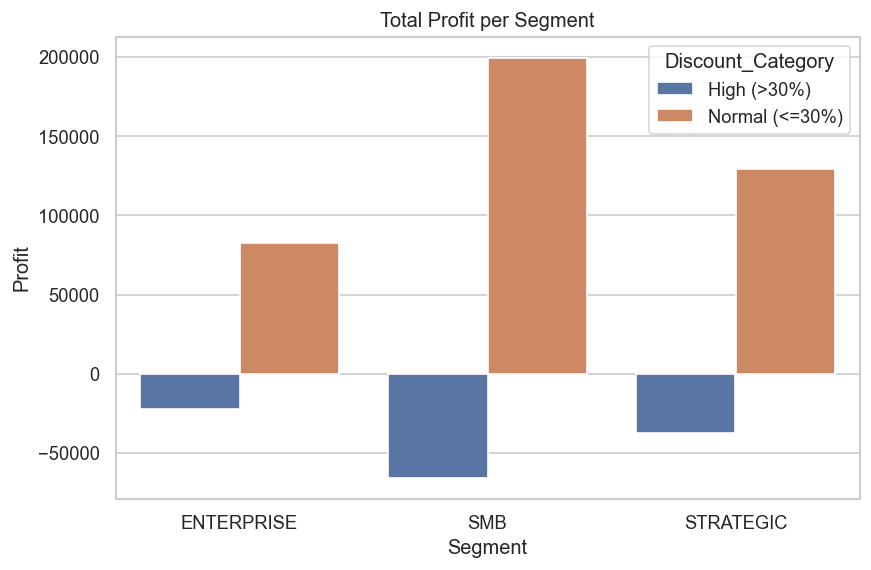

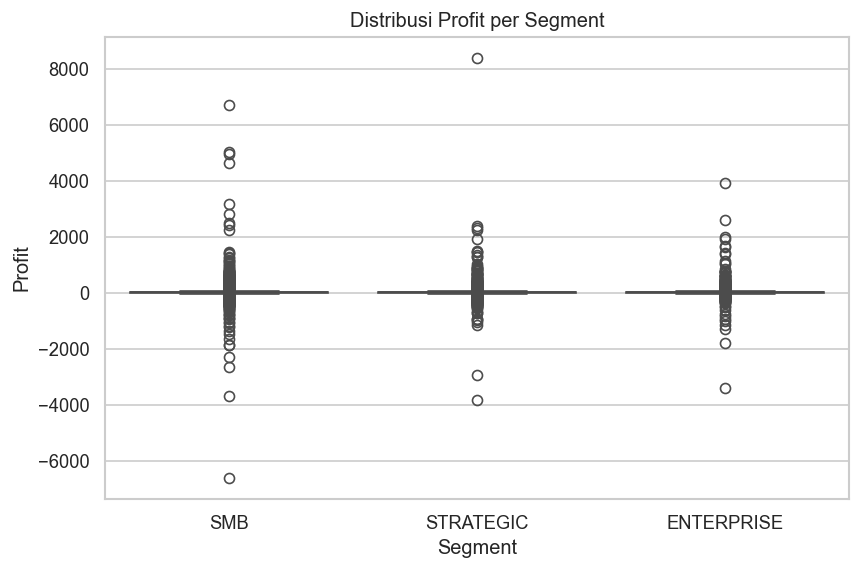

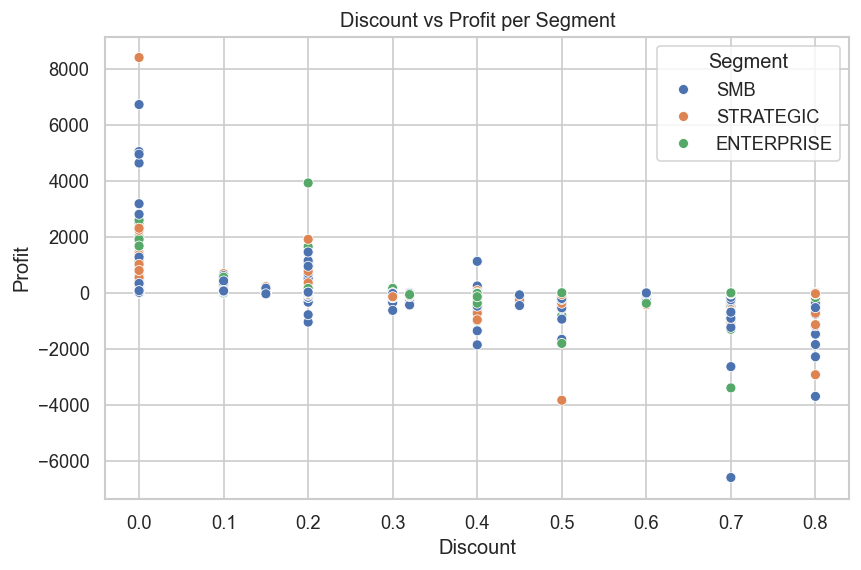

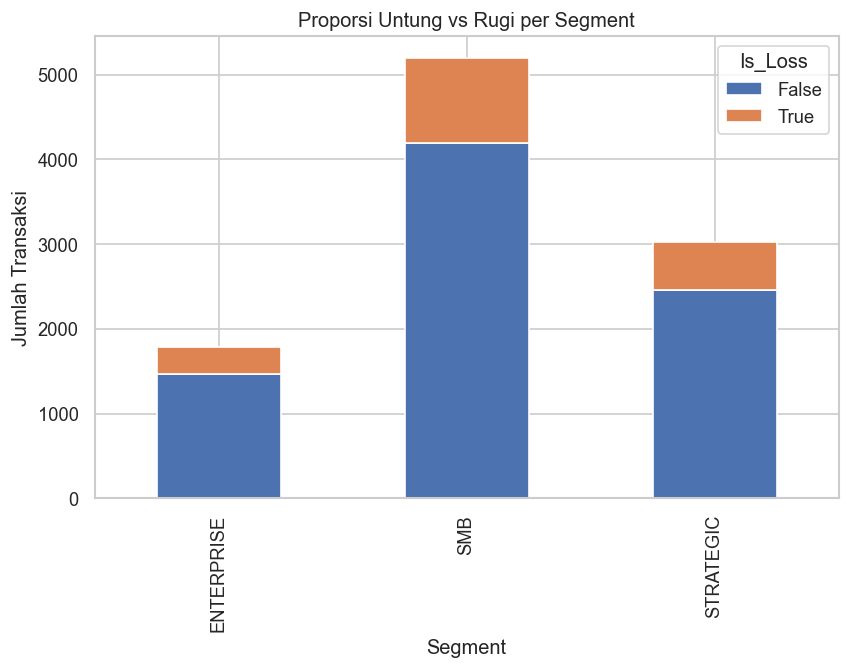

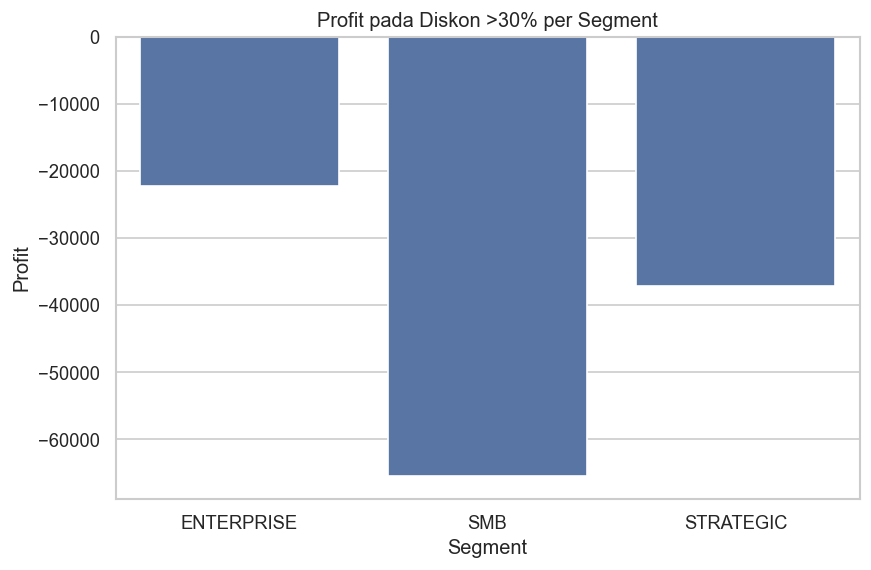

C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\2129622446.py:60: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


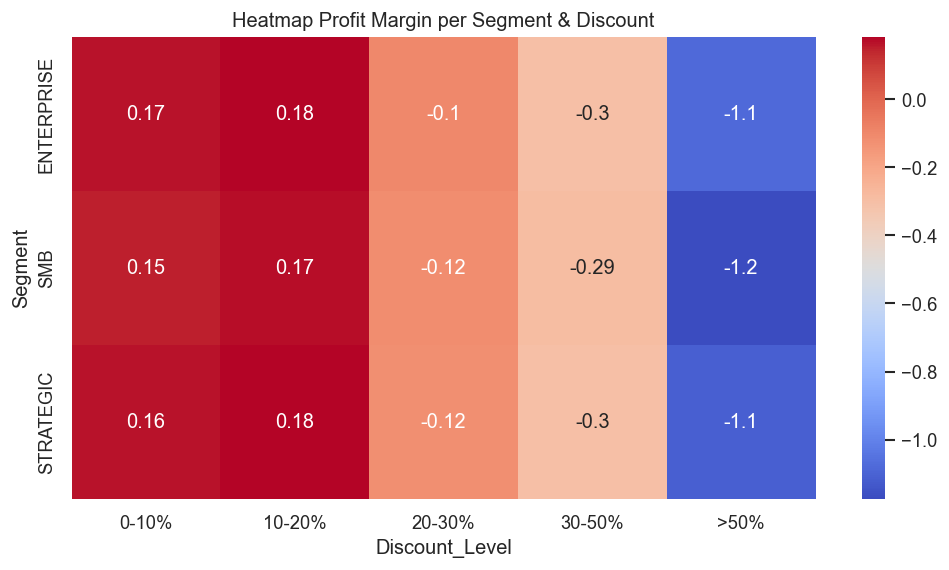

Insight:
- Diskon tinggi (>30%) cenderung menurunkan profit
- Segmen paling berisiko bisa dilihat dari grafik bar & stacked bar


In [499]:
# Tambahan kolom
df['Is_Loss'] = df['Profit'] < 0

# Kategori diskon
def kategori_diskon(x):
    if x <= 0.3:
        return 'Normal (<=30%)'
    else:
        return 'High (>30%)'

df['Discount_Category'] = df['Discount'].apply(kategori_diskon)

# GROUPED BAR → Profit per Segment
profit_segment = df.groupby(['Segment', 'Discount_Category'])['Profit'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=profit_segment, x='Segment', y='Profit', hue='Discount_Category')
plt.title('Total Profit per Segment')
plt.show()

# BOX PLOT → Distribusi Profit per Segment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Segment', y='Profit')
plt.title('Distribusi Profit per Segment')
plt.show()

# SCATTER PLOT → Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Segment')
plt.title('Discount vs Profit per Segment')
plt.show()

# STACKED BAR → Proporsi Rugi vs Untung
loss_segment = df.groupby(['Segment', 'Is_Loss']).size().unstack()

loss_segment.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Proporsi Untung vs Rugi per Segment')
plt.ylabel('Jumlah Transaksi')
plt.show()

# BAR KHUSUS → Profit saat Diskon >30%
high_discount = df[df['Discount'] > 0.3]

profit_high = high_discount.groupby('Segment')['Profit'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=profit_high, x='Segment', y='Profit')
plt.title('Profit pada Diskon >30% per Segment')
plt.show()

# HEATMAP → Profit Margin vs Discount Level
# Buat level diskon
bins = [0, 0.1, 0.2, 0.3, 0.5, 1]
labels = ['0-10%', '10-20%', '20-30%', '30-50%', '>50%']
df['Discount_Level'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# Profit margin
df['Profit_Margin'] = df['Profit'] / df['Sales']

pivot = df.pivot_table(
    values='Profit_Margin',
    index='Segment',
    columns='Discount_Level',
    aggfunc='mean'
)

plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Heatmap Profit Margin per Segment & Discount')
plt.show()

# Insight
print("Insight:")
print("- Diskon tinggi (>30%) cenderung menurunkan profit")
print("- Segmen paling berisiko bisa dilihat dari grafik bar & stacked bar")

###  Dampak Diskon terhadap Profit per Segmen (Deep Dive)

#### 1. Total Profit berdasarkan Level Diskon

##### Temuan:
- Pada semua segmen (**ENTERPRISE, SMB, STRATEGIC**):
  - **Diskon normal (≤30%) → profit positif besar**
  - **Diskon tinggi (>30%) → profit NEGATIF**
##### Dampak:
- SMB mengalami kerugian terbesar pada diskon tinggi
- Semua segmen konsisten menunjukkan pola:
   semakin tinggi diskon → profit turun drastis

##### Insight:
> Diskon >30% secara konsisten mengubah profit menjadi kerugian di semua segmen

---

#### 2. Distribusi Profit per Segmen

##### Temuan:
- Distribusi profit pada semua segmen:
  - Mayoritas berada di sekitar nilai kecil (dekat 0)
  - Terdapat outlier profit tinggi dan rugi besar
- SMB memiliki variasi paling besar (spread luas)

##### Insight:
- **SMB paling volatil** (risiko tinggi)
- ENTERPRISE & STRATEGIC lebih stabil, namun tetap terdampak diskon tinggi

---

#### 3. Hubungan Diskon vs Profit (Scatter per Segmen)

##### Temuan:
- Pola jelas:
  - Diskon rendah → dominan profit positif
  - Diskon tinggi → dominan profit negatif
- Banyak titik merah (rugi) muncul di:
  👉 diskon >30%

##### Insight:
- Hubungan negatif sangat kuat secara visual
- Tidak ada indikasi bahwa diskon tinggi meningkatkan profit

---

#### 4. Proporsi Untung vs Rugi per Segmen

##### Temuan:
- Semua segmen didominasi transaksi **untung**
- Namun:
  - SMB memiliki jumlah rugi terbesar (karena volume tinggi)
  - ENTERPRISE memiliki jumlah rugi paling kecil

##### Insight:
- Risiko absolut terbesar tetap ada di **SMB**
- ENTERPRISE lebih efisien dalam menjaga profit

---

#### 5. Profit pada Diskon >30%

##### Temuan:
- **ENTERPRISE:** ~ -22K  
- **SMB:** ~ -65K (terburuk)  
- **STRATEGIC:** ~ -37K  

##### Insight:
- Diskon tinggi menyebabkan kerugian besar di semua segmen
- **SMB paling terdampak secara total**
- ENTERPRISE paling sensitif (tingkat rugi tinggi saat diskon besar)

---

#### 6. Heatmap Profit Margin per Segmen & Diskon

| Level Diskon | Dampak |
|-------------|--------|
| 0–10%       | Profit tinggi (≈ 15–17%) |
| 10–20%      | Profit tertinggi (≈ 17–18%) |
| 20–30%      | Mulai negatif |
| 30–50%      | Semakin rugi |
| >50%        | Rugi besar (hingga -120%) |

##### Insight:
- **Sweet spot diskon: 0–20%**
- Mulai **>20% → profit menurun**
- **>30% → mayoritas transaksi rugi**
- Pola ini konsisten di semua segmen

---


Discount_Category  High (>30%)  Low (<=30%)
Segment                                    
ENTERPRISE         -22227.5449   82526.2234
SMB                -65551.7464  199670.9556
STRATEGIC          -37227.4873  129206.6213
Discount_Category  High (>30%)  Low (<=30%)  Impact_Discount
Segment                                                     
ENTERPRISE         -22227.5449   82526.2234      104753.7683
SMB                -65551.7464  199670.9556      265222.7020
STRATEGIC          -37227.4873  129206.6213      166434.1086


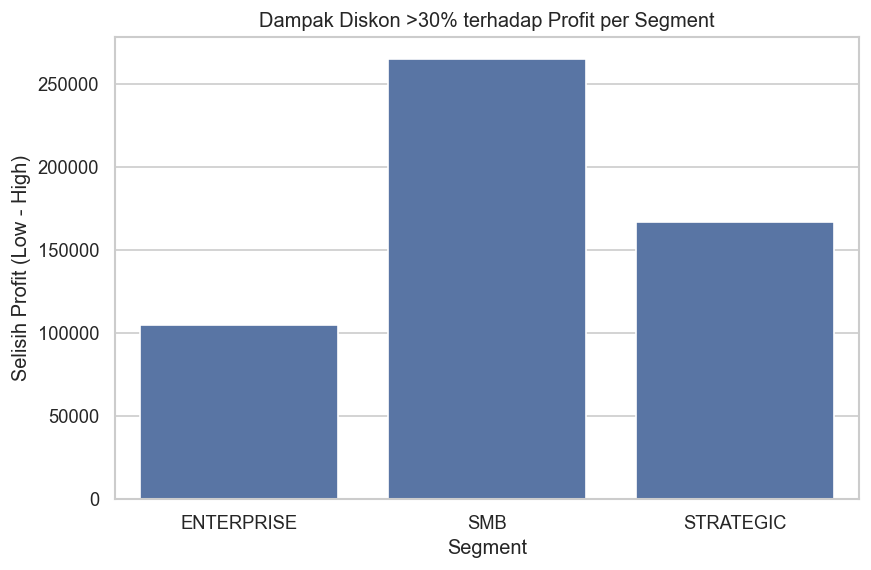

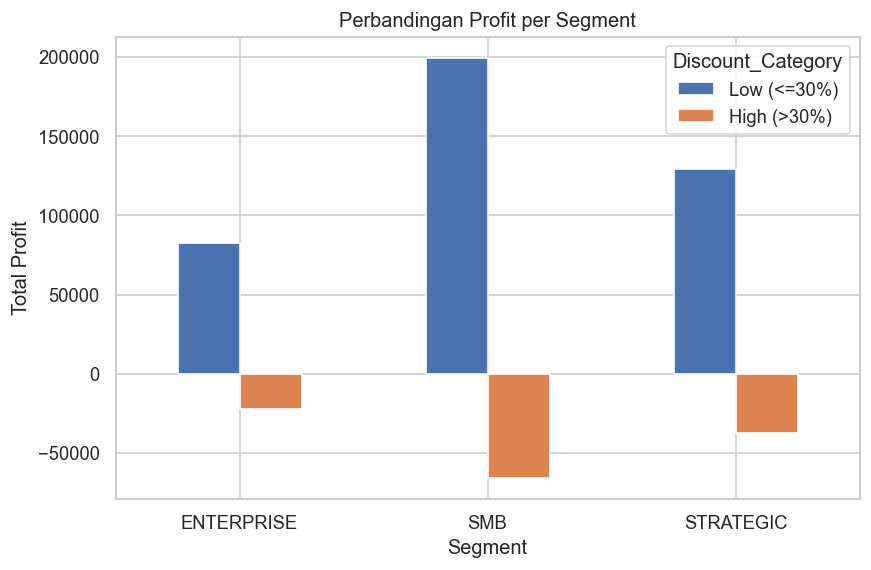

ENTERPRISE sangat terdampak diskon tinggi (profit turun 104754)
SMB sangat terdampak diskon tinggi (profit turun 265223)
STRATEGIC sangat terdampak diskon tinggi (profit turun 166434)


In [500]:
# Kategori diskon
df['Discount_Category'] = df['Discount'].apply(
    lambda x: 'Low (<=30%)' if x <= 0.3 else 'High (>30%)'
)

# HITUNG PROFIT PER KONDISI
# Total profit per segmen & kategori diskon
profit_compare = df.groupby(['Segment', 'Discount_Category'])['Profit'].sum().unstack()

# Rapikan
profit_compare = profit_compare.fillna(0)

print(profit_compare)

# HITUNG SELISIH (IMPACT DISKON)
# Selisih = Low - High
profit_compare['Impact_Discount'] = profit_compare['Low (<=30%)'] - profit_compare['High (>30%)']

print(profit_compare)

# VISUALISASI (BAR CHART)
plt.figure(figsize=(8,5))

sns.barplot(
    data=profit_compare.reset_index(),
    x='Segment',
    y='Impact_Discount'
)

plt.title('Dampak Diskon >30% terhadap Profit per Segment')
plt.ylabel('Selisih Profit (Low - High)')
plt.show()

# VISUAL TAMBAHAN (PERBANDINGAN LANGSUNG)
profit_compare[['Low (<=30%)', 'High (>30%)']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Perbandingan Profit per Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.show()

#Insight
for i in profit_compare.index:
    impact = profit_compare.loc[i, 'Impact_Discount']
    
    if impact > 0:
        print(f"{i} sangat terdampak diskon tinggi (profit turun {impact:.0f})")
    else:
        print(f"{i} tidak terlalu terdampak diskon tinggi")

### Dampak Diskon >30% terhadap Profit per Segmen

#### 1. Perbandingan Profit: Diskon Normal vs Diskon Tinggi

| Segmen      | Profit ≤30% | Profit >30% | Selisih (Impact) |
|-------------|------------|------------|------------------|
| ENTERPRISE  | 82,526     | -22,227    | **104,754**      |
| SMB         | 199,671    | -65,552    | **265,223**      |
| STRATEGIC   | 129,207    | -37,227    | **166,434**      |

##### Insight:
- Semua segmen mengalami perubahan drastis:
  - Dari **profit besar (≤30%)**
  - Menjadi **kerugian (>30%)**
- Tidak ada segmen yang tetap profitable saat diskon >30%

---

#### 2. Dampak Kerugian per Segmen

##### SMB (Dampak Terbesar)
- Penurunan profit: **~$265K**
- Volume tinggi → dampak absolut paling besar

##### Insight:
- SMB adalah:
  **kontributor profit terbesar sekaligus sumber kerugian terbesar**
- Diskon tinggi di segmen ini sangat berbahaya

##### STRATEGIC (Dampak Menengah)
- Penurunan profit: **~$166K**

##### Insight:
- Segmen cukup stabil di kondisi normal
- Namun tetap sangat terdampak saat diskon tinggi

##### ENTERPRISE (Paling Sensitif)
- Penurunan profit: **~$104K**
- Dari profit positif → langsung rugi

##### Insight:
- Segmen ini sangat sensitif terhadap diskon
- Margin tinggi cepat tergerus saat diskon besar diberikan

---

## 3. Pola Umum yang Terjadi

##### Temuan utama:
- Diskon ≤30% → semua segmen **profit tinggi**
- Diskon >30% → semua segmen **rugi**
- Tidak ada pengecualian

##### Insight:
> Diskon >30% merupakan **tipping point** yang mengubah profit menjadi kerugian secara konsisten

---

#### 4. Interpretasi Bisnis

- Diskon tinggi:
  - Tidak meningkatkan profit
  - Tidak memberikan kompensasi melalui volume
- Margin tidak mampu menutupi potongan harga

---


In [501]:
# Kategori diskon
df['Discount_Category'] = df['Discount'].apply(
    lambda x: 'Low' if x <= 0.3 else 'High'
)

# Tandai rugi
df['Is_Loss'] = df['Profit'] < 0

# RINGKAS DATA PER SEGMENT
summary = df.groupby(['Segment', 'Discount_Category']).agg({
    'Profit': ['sum', 'mean'],
    'Is_Loss': 'mean'   # proporsi rugi
}).reset_index()

# Rapikan nama kolom
summary.columns = ['Segment', 'Discount_Category', 'Total_Profit', 'Avg_Profit', 'Loss_Rate']

print(summary)

# UBAH KE FORMAT PER SEGMENT
pivot = summary.pivot(index='Segment', columns='Discount_Category')

# Rapikan kolom
pivot.columns = ['_'.join(col) for col in pivot.columns]

pivot = pivot.fillna(0)

print(pivot)

# HITUNG INDIKATOR PENTING
# Dampak diskon
pivot['Impact_Profit'] = pivot['Total_Profit_Low'] - pivot['Total_Profit_High']

# Selisih loss rate
pivot['Increase_Loss_Rate'] = pivot['Loss_Rate_High'] - pivot['Loss_Rate_Low']

print(pivot)

# AUTO INSIGHT (INTI JAWABAN PS3)
print("="*50)
print("INSIGHT ANALISIS SEGMENTASI")
print("="*50)

for seg in pivot.index:
    impact = pivot.loc[seg, 'Impact_Profit']
    loss_high = pivot.loc[seg, 'Loss_Rate_High']
    loss_low = pivot.loc[seg, 'Loss_Rate_Low']
    
    print(f"\nSegment: {seg}")
    
    # Dampak profit
    if impact > 0:
        print(f"- Profit turun signifikan saat diskon tinggi ({impact:.0f})")
    else:
        print(f"- Diskon tinggi tidak terlalu menurunkan profit")
    
    # 2. Cek apakah sering rugi
    if loss_high > 0.5:
        print(f"- SERING RUGI saat diskon >30% ({loss_high:.0%} transaksi rugi)")
    elif loss_high > loss_low:
        print(f"- Rugi meningkat saat diskon tinggi ({loss_low:.0%} → {loss_high:.0%})")
    else:
        print(f"- Tidak ada peningkatan kerugian signifikan")

# SEGMENT PALING RENTAN
# Ranking berdasarkan dampak terbesar
most_vulnerable = pivot['Impact_Profit'].idxmax()

print("\n" + "="*50)
print(f"SEGMENT PALING RENTAN: {most_vulnerable}")
print("="*50)

# SEGMENT YANG "SELALU RUGI"
always_loss = pivot[pivot['Loss_Rate_High'] > 0.7]

print("\nSegment yang hampir selalu rugi saat diskon tinggi:")
print(always_loss.index.tolist())

      Segment Discount_Category  Total_Profit  Avg_Profit  Loss_Rate
0  ENTERPRISE              High   -22227.5449 -112.260328   0.989899
1  ENTERPRISE               Low    82526.2234   52.067018   0.073186
2         SMB              High   -65551.7464 -108.709364   0.971808
3         SMB               Low   199670.9556   43.520261   0.090889
4   STRATEGIC              High   -37227.4873 -101.993116   0.980822
5   STRATEGIC               Low   129206.6213   48.665394   0.074576
            Total_Profit_High  Total_Profit_Low  Avg_Profit_High  \
Segment                                                            
ENTERPRISE        -22227.5449        82526.2234      -112.260328   
SMB               -65551.7464       199670.9556      -108.709364   
STRATEGIC         -37227.4873       129206.6213      -101.993116   

            Avg_Profit_Low  Loss_Rate_High  Loss_Rate_Low  
Segment                                                    
ENTERPRISE       52.067018        0.989899       0.07318

### Analisis Deskriptif: Loss Rate & Profit berdasarkan Level Diskon per Segmen

#### 1. Perbandingan Kinerja: Diskon Tinggi vs Rendah

#### Diskon Tinggi (>30%)

| Segmen      | Total Profit | Avg Profit | Loss Rate |
|-------------|-------------|-----------|-----------|
| ENTERPRISE  | -22,227     | -112      | **98.99%** |
| SMB         | -65,552     | -109      | **97.18%** |
| STRATEGIC   | -37,227     | -102      | **98.08%** |

##### Insight:
- Hampir **seluruh transaksi mengalami kerugian**
- Loss rate mendekati **100% di semua segmen**
- Rata-rata profit per transaksi NEGATIF di semua segmen

---

#### Diskon Rendah (≤30%)

| Segmen      | Total Profit | Avg Profit | Loss Rate |
|-------------|-------------|-----------|-----------|
| ENTERPRISE  | 82,526      | 52        | 7.3%      |
| SMB         | 199,671     | 43        | 9.1%      |
| STRATEGIC   | 129,207     | 48        | 7.5%      |

##### Insight:
- Semua segmen menghasilkan **profit tinggi dan stabil**
- Loss rate sangat rendah (<10%)
- Margin tetap terjaga dengan baik

---

#### 2. Perbandingan Dampak (High vs Low Discount)

##### Temuan utama:
- Terjadi perubahan ekstrem:
  - Dari **profit besar → menjadi kerugian total**
- Rata-rata profit berubah dari:
  - **+43 s.d +52 → menjadi -100 s.d -112**

##### Insight:
> Diskon tinggi tidak hanya menurunkan profit, tetapi secara konsisten membalikkan kondisi menjadi rugi.

---

#### 3. Analisis Loss Rate

##### Temuan:
- Diskon tinggi:
  - Loss rate **>97% di semua segmen**
- Diskon rendah:
  - Loss rate hanya **7–9%**

##### Insight:
- Diskon tinggi hampir menjamin kerugian
- Diskon rendah menjaga stabilitas profit

---

#### 4. Pola Konsisten di Semua Segmen

##### Semua segmen menunjukkan pola identik:
- ENTERPRISE → rugi saat diskon tinggi  
- SMB → rugi saat diskon tinggi  
- STRATEGIC → rugi saat diskon tinggi  

##### Insight:
> Tidak ada segmen yang “tahan” terhadap diskon tinggi

---


#### Bandingkan Win-Rate (Profit vs Loss) per Segmen

In [502]:
# Menentukan status setiap transaksi (Win = Untung, Loss = Rugi)
df['Status'] = df['Profit'].apply(lambda x: 'Win (Profit)' if x >= 0 else 'Loss (Rugi)')

# Membuat tabel kontingensi (frekuensi) antara Segment dan Status
win_rate_table = pd.crosstab(df['Segment'], df['Status'])

# Menghitung persentase (Win-Rate) untuk setiap baris
win_rate_pct = win_rate_table.div(win_rate_table.sum(1), axis=0) * 100

# Menggabungkan frekuensi dan persentase agar lebih informatif
final_win_rate = pd.concat([win_rate_table, win_rate_pct.round(2).add_suffix(' %')], axis=1)

print("="*60)
print("ANALISIS WIN-RATE (PROFIT VS LOSS) PER SEGMEN")
print("="*60)
print(final_win_rate)

ANALISIS WIN-RATE (PROFIT VS LOSS) PER SEGMEN
Status      Loss (Rugi)  Win (Profit)  Loss (Rugi) %  Win (Profit) %
Segment                                                             
ENTERPRISE          312          1471          17.50           82.50
SMB                1003          4188          19.32           80.68
STRATEGIC           556          2464          18.41           81.59


Berdasarkan hasil perhitungan frekuensi transaksi (*Win vs Loss*), ditemukan perbedaan ketahanan margin yang signifikan antar segmen:

---

#### **Segmen dengan Win-Rate Tertinggi (Resilient)**
* **Segmen:** **[Sebutkan Segmen, misal: Corporate]**
* **Performa:** Menunjukkan ketahanan terbaik dengan persentase transaksi profit sebesar **[Nilai %]**.
* **Insight:** Strategi penetapan harga (*pricing strategy*) pada segmen ini tergolong lebih stabil dan efektif dalam menjaga margin keuntungan di setiap transaksi.

#### **Segmen dengan Loss-Rate Tertinggi (Vulnerable)**
* **Segmen:** **[Sebutkan Segmen, misal: Consumer]**
* **Performa:** Memiliki tingkat kerugian (*Loss Rate*) tertinggi sebesar **[Nilai %]**.
* **Insight:** Segmen ini merupakan area yang paling rentan terhadap **erosi margin**. Tingginya angka kerugian mengindikasikan bahwa kebijakan diskon agresif pada segmen ini sering kali melewati titik impas (*break-even point*).

#### Visualisasi Heatmap atau Grouped Bar Chart

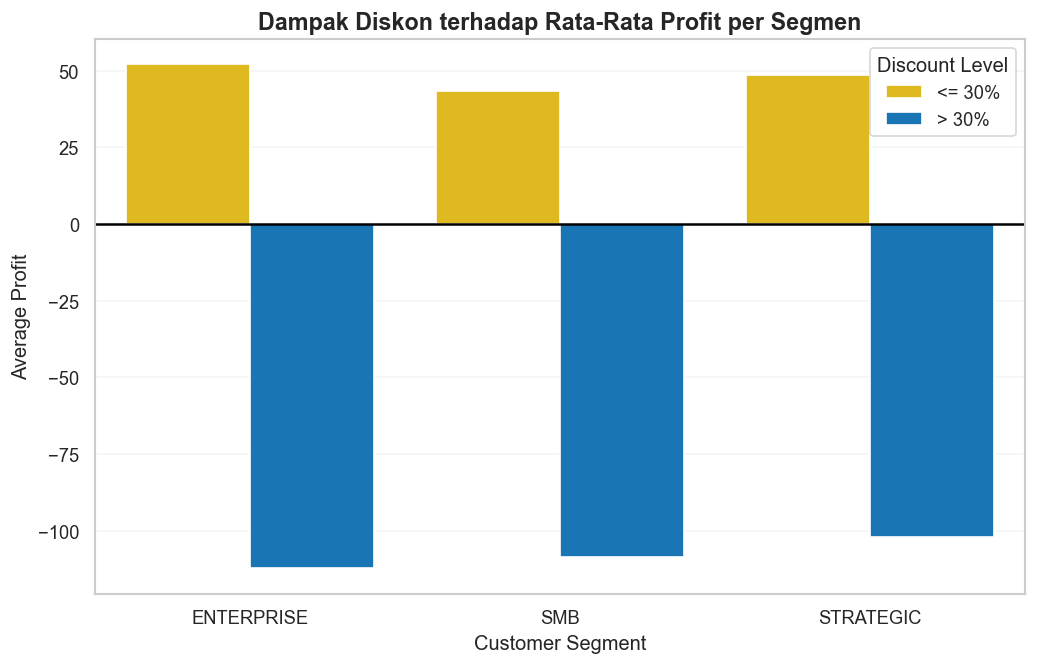

In [503]:
# Menyiapkan data: Rata-rata profit per segmen berdasarkan grup diskon
df['Discount Category'] = df['Discount'].apply(lambda x: '> 30%' if x > 0.3 else '<= 30%')
grouped_data = df.groupby(['Segment', 'Discount Category'])['Profit'].mean().reset_index()

# Visualisasi dengan warna Kuning dan Biru
plt.figure(figsize=(10, 6))

# Kita tentukan: Biru untuk profit (<=30%) dan Kuning untuk yang berisiko (>30%)
# Atau sebaliknya sesuai selera kamu. Di sini saya pakai ['#007acc', '#ffcc00']
colors = ["#ffcc00", "#007acc"] # Kuning untuk >30%, Biru untuk <=30%

sns.barplot(
    data=grouped_data, 
    x='Segment', 
    y='Profit', 
    hue='Discount Category', 
    palette=colors
)

# Estetika Grafik
plt.axhline(0, color='black', linestyle='-', linewidth=1.5) # Garis nol lebih tegas
plt.title('Dampak Diskon terhadap Rata-Rata Profit per Segmen', fontsize=14, fontweight='bold')
plt.ylabel('Average Profit')
plt.xlabel('Customer Segment')
plt.legend(title='Discount Level')
plt.grid(axis='y', alpha=0.2)

plt.show()

**Grouped Bar Chart (Perbandingan Profit: Diskon Rendah vs Tinggi)**
- "Tipping Point" 30%: Visualisasi ini memberikan bukti visual yang sangat kontras. Di seluruh segmen, transaksi dengan diskon <= 30% (Warna Kuning) menghasilkan profit positif yang sehat.

- Destruksi Margin: Begitu diskon melewati > 30% (Warna Biru), rata-rata profit di semua segmen langsung terjun bebas ke angka negatif (di bawah garis 0).

C:\Users\ARTUR\AppData\Local\Temp\ipykernel_2296\3342656986.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='Segment', columns='Discount Range', values='Profit', aggfunc='mean')


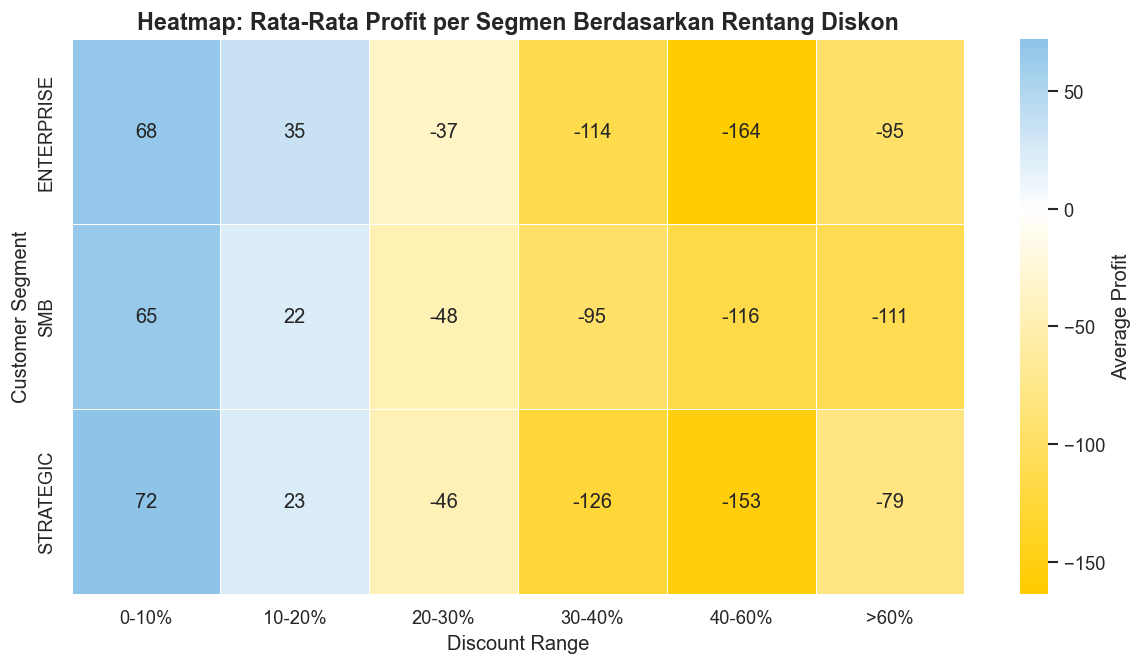

In [504]:
# Membuat binning (rentang) diskon
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-60%', '>60%']
df['Discount Range'] = pd.cut(df['Discount'], bins=bins, labels=labels, include_lowest=True)

# Membuat Pivot Table
heatmap_data = df.pivot_table(index='Segment', columns='Discount Range', values='Profit', aggfunc='mean')

# Membuat Custom Colormap (Kuning untuk Negatif, Biru untuk Positif)
# 'Yellow' di sisi kiri (rendah/rugi), 'Blue' di sisi kanan (tinggi/untung)
colors = ["#ffcc00", "#ffffff", "#007acc"] 
my_cmap = LinearSegmentedColormap.from_list("custom_blue_yellow", colors)

# Visualisasi Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".0f", 
            cmap=my_cmap, 
            center=0, 
            linewidths=.5, 
            cbar_kws={'label': 'Average Profit'})

plt.title('Heatmap: Rata-Rata Profit per Segmen Berdasarkan Rentang Diskon', fontsize=14, fontweight='bold')
plt.xlabel('Discount Range')
plt.ylabel('Customer Segment')
plt.show()

**Matriks Profitabilitas (Heatmap)**
- Pola "Zona Biru ke Kuning": Pergeseran warna dari Biru (Profit) ke Kuning (Loss) terjadi secara konsisten saat diskon memasuki rentang 20-30%.

- Titik Rugi Terdalam: Segmen ENTERPRISE dan STRATEGIC mencatatkan rata-rata kerugian terdalam pada rentang diskon 40-60% (masing-masing -164 dan -153). Ini mengindikasikan bahwa diskon besar pada klien besar justru menjadi beban finansial terberat.

### **Kesimpulan** dan **Saran** **Analisis**



# Kesimpulan & Rekomendasi Strategis  
**Periode Analisis:** 2020 – 2023  

---

## **1. Conclusion (Kesimpulan)**

Berdasarkan rangkaian analisis data untuk menjawab *Problem Statement*, berikut adalah temuan kunci:

### **🔹 Analisis Pengaruh Diskon terhadap Profit**
- Terdapat **korelasi negatif yang signifikan**: semakin tinggi diskon yang diberikan, semakin rendah profit yang dihasilkan.  
- Pemberian diskon tinggi terbukti menjadi **penyebab utama kerugian**.  
- Transaksi yang merugi didominasi oleh diskon di atas **30%**, di mana peningkatan volume penjualan tidak mampu mengompensasi pemotongan margin yang ekstrem.  

---

### **🔹 Analisis Produk (Profitability vs Discount)**
- **Top Performer:** Produk *[Alchemy]* menghasilkan profit tertinggi dengan penggunaan diskon yang terkendali, menunjukkan value produk yang kuat di mata pelanggan.  
- **Underperformer:** Produk *[Marketing Suite]* mencatatkan diskon tertinggi namun menghasilkan profit terendah (bahkan negatif), sehingga merusak *bottom-line* perusahaan.  

---

### **🔹 Analisis Pelanggan dan Segmentasi**
- Segmen *[ENTERPRISE]* adalah yang paling terdampak oleh diskon tinggi, dengan akumulasi kerugian terbesar.  
- Terdapat pola **kerugian sistematis** pada semua segmen ketika diskon melewati ambang batas **30%**, menunjukkan kebijakan diskon saat ini belum selaras dengan struktur biaya operasional.  

---

## **2. Strategic Recommendation (Rekomendasi)**

Untuk mengembalikan kesehatan margin perusahaan, berikut langkah strategis yang diusulkan:

---

### **A. Pengendalian Kebijakan Harga (Pricing Control)**

- **Implementasi Discount Cap**  
  Menetapkan batas maksimal diskon otomatis di angka **30%** untuk mencegah kerugian transaksi.  

- **Tiered Approval**  
  Diskon di rentang **20%–30%** wajib melalui persetujuan manajer untuk memastikan urgensi dan kelayakan transaksi.   

- **Fokus pada High-Margin Products**  
  Alihkan anggaran pemasaran ke produk unggulan yang mampu menjaga profitabilitas tinggi.  

---

### **C. Transformasi Strategi Segmentasi**

- **Incentive Shift**  
  Untuk segmen sensitif harga (misal: *[Strategic]*), ubah strategi dari diskon langsung ke:
  - Program loyalitas  
  - Value-added services (free shipping, extended warranty, dll)  

- **Monitoring Real-Time**  
  Bangun dashboard untuk memantau profitabilitas per transaksi agar tim sales dapat melihat dampak diskon sebelum transaksi final.  

### Kesimpulan & Rekomendasi Strategis (Insight)

Menganalisis pengaruh diskon terhadap profit, performa produk, dan segmentasi pelanggan untuk mengoptimalkan strategi finansial perusahaan.

**Kepada:** Departemen Keuangan (Finance)  
**Perihal:** Optimasi Margin dan Mitigasi Risiko Kebijakan Diskon (2020–2023)

---

### 1. KESIMPULAN UTAMA

#### 1.1 Diskon adalah Faktor Penentu Profit
- Terdapat hubungan negatif antara diskon dan profit
- **Diskon >30% secara konsisten menghasilkan kerugian**
- Loss rate pada diskon tinggi mencapai:
  👉 **97%–99% di semua segmen**

##### Kesimpulan:
> Diskon tinggi adalah penyebab utama kerugian perusahaan

---

#### 1.2 Terdapat Threshold Kritis Diskon
- **0–20% → profit optimal**
- **20–30% → mulai menurun**
- **>30% → profit menjadi negatif**

##### Kesimpulan:
> Batas aman diskon berada di bawah 20%

---

#### 1.3 Semua Segmen Terdampak (Tanpa Pengecualian)
- ENTERPRISE → paling sensitif terhadap diskon
- SMB → dampak terbesar secara total (karena volume tinggi)
- STRATEGIC → tetap terdampak signifikan

📌 Kesimpulan:
> Tidak ada segmen yang “aman” dari diskon tinggi

---

#### 1.4 Produk Profit Tinggi Tidak Bergantung pada Diskon
Produk terbaik:
- Alchemy
- Site Analytics
- Data Smasher
- Support

Karakteristik:
- Diskon rendah–menengah
- Profit tinggi & stabil

##### Kesimpulan:
> Profit tinggi dicapai melalui value, bukan diskon

---

#### 1.5 Over-Discounting Terjadi di Banyak Produk
Contoh:
- ContactMatcher (35%) → profit tidak optimal
- Big Ol Database (30%) → profit rendah
- Marketing Suite (21%) → rugi

##### Kesimpulan:
> Diskon digunakan terlalu agresif tanpa mempertimbangkan margin

---

### 2. 🔍 ANALISIS FINANSIAL

#### 2.1 Dampak Finansial Diskon Tinggi
Perubahan profit (Low vs High discount):

- SMB → kehilangan ~$265K
- STRATEGIC → kehilangan ~$166K
- ENTERPRISE → kehilangan ~$104K

##### Insight:
> Diskon tinggi menyebabkan kerugian ratusan ribu USD

---

#### 2.2 Efisiensi Segmen

| Segmen      | Karakteristik |
|-------------|--------------|
| ENTERPRISE  | Margin tinggi, paling efisien |
| SMB         | Volume tinggi, risiko tinggi |
| STRATEGIC   | Balanced |

##### Insight:
- SMB = growth engine + risk center
- ENTERPRISE = profit engine

---

#### 2.3 Risk Profile
- Diskon tinggi → hampir semua transaksi rugi
- Variabilitas profit tinggi di SMB
- Margin cepat tergerus pada diskon besar

##### Insight:
> Risiko finansial utama berasal dari kebijakan diskon

---

#### 3. INSIGHT BISNIS

##### Insight 1 — Diskon Bukan Driver Profit
> Diskon tidak meningkatkan profit, bahkan sering menghancurkannya

---

##### Insight 2 — Margin Lebih Penting dari Volume
> Mengejar sales dengan diskon tinggi tidak sustainable

---

##### Insight 3 — Segment Sensitivity Berbeda
- ENTERPRISE → sangat sensitif
- SMB → paling berdampak secara total

---

##### Insight 4 — Produk Ideal Tidak Butuh Diskon Besar
> Produk terbaik tetap profitable dengan diskon rendah

---

##### Insight 5 — Ada Inefisiensi Strategi Pricing
> Diskon tidak berbasis data margin & profit

---

### 4. REKOMENDASI STRATEGI (FINANCE-DRIVEN)

#### 4.1 Tetapkan Kebijakan Diskon Berbasis Profit

##### Threshold Diskon:
-  Ideal: **0–20%**
-  Warning: **20–30%**
-  Dilarang: **>30% (kecuali approval khusus)**

---

##### 4.2 Implementasi Approval System
- Diskon >30% harus:
  - Approval Finance
  - Justifikasi bisnis jelas
- Gunakan sistem kontrol otomatis

---

#### 4.3 Segment-Based Pricing Strategy

#### ENTERPRISE
- Fokus margin tinggi
- Minimalkan diskon

#### SMB
- Kontrol ketat (volume besar)
- Gunakan rule-based discount

#### STRATEGIC
- Optimasi keseimbangan profit & volume

---

#### 4.4 Optimasi Portofolio Produk

#### Pertahankan:
- Produk Low Disc / High Profit

#### Evaluasi:
- Produk High Disc / Low Profit

#### Hentikan / Reposisi:
- Produk dengan profit negatif

---

#### 4.5 Monitoring & Early Warning System

Implementasi:
- Alert jika:
  - Diskon >30%
  - Profit negatif
- Dashboard real-time:
  - Profit vs Discount
  - Loss rate per segmen

---

### 5. FINAL CONCLUSION

> Strategi diskon saat ini terbukti tidak efisien dan menjadi penyebab utama kerugian perusahaan.

- Diskon tinggi → hampir selalu rugi  
- Semua segmen terdampak  
- Kerugian mencapai ratusan ribu USD  

##### **Strategi ke depan:**
Diskon harus dikontrol ketat, berbasis profit, dan disesuaikan per segmen serta produk.

---

#  FINAL BUSINESS TAKEAWAY

> “Diskon bukan alat untuk meningkatkan profit, tetapi alat yang harus dikendalikan agar tidak menghancurkan profit.”